<a href="https://colab.research.google.com/github/BuruhArloji/home_credit_prediction/blob/main/Home_Credit_Loan_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem**

Lembaga keuangan pemberi pinjaman menghadapi risiko finansial yang signifikan ketika memberikan kredit kepada individu yang memiliki potensi tinggi untuk gagal bayar (default). Proses peninjauan manual untuk menentukan kelayakan kredit sering kali memakan waktu, subjektif, dan tidak efisien dalam memproses ribuan aplikasi secara cepat.

Ketidakmampuan dalam membedakan antara peminjam yang dapat dipercaya dan peminjam berisiko tinggi dapat menyebabkan dua kerugian:

* Kerugian Finansial: Memberikan pinjaman kepada orang yang akhirnya gagal bayar.

* Kehilangan Kesempatan: Menolak peminjam yang sebenarnya mampu membayar, sehingga perusahaan kehilangan potensi keuntungan.

# **Objective**

Mengembangkan model Machine Learning klasifikasi biner yang dapat memprediksi probabilitas seorang pemohon pinjaman akan mengalami kesulitan pembayaran di masa depan.

Secara spesifik, tujuan proyek ini adalah:
* Membangun Model Prediktif: Menggunakan algoritma klasifikasi untuk membedakan antara kelas Target 0 dan Target 1.

* Identifikasi Indikator Kunci: Menentukan fitur-fitur apa saja (misal: AMT_INCOME_TOTAL, DAYS_BIRTH, EXT_SOURCE) yang paling berpengaruh terhadap kemungkinan gagal bayar.

* Optimasi Keputusan Bisnis: Menyediakan alat bantu bagi tim analis kredit untuk menyaring aplikasi secara otomatis dengan tingkat akurasi dan recall yang tinggi, guna meminimalkan risiko kerugian kredit.

# **1.&nbsp;Setup and Initialization**

## 1.1. Loading Datasets

In [ ]:
from google.colab import drive

# Menghubungkan Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



### 1.1.1 Application

In [ ]:
path_train = '/content/drive/MyDrive/Home Credit Risk/application_train.csv'
df_application = pd.read_csv(path_train)
df_application.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


### 1.1.2 Bureau

In [ ]:
path_bureau = '/content/drive/MyDrive/Home Credit Risk/bureau.csv'
df_bureau = pd.read_csv(path_bureau)
df_bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


### 1.1.3 Previous Application

In [ ]:
path_previousapp = '/content/drive/MyDrive/Home Credit Risk/previous_application.csv'
df_previousapp = pd.read_csv(path_previousapp)
df_previousapp.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


### 1.1.4 Bureau Balance

In [ ]:
path_bureaubalance = '/content/drive/MyDrive/Home Credit Risk/bureau_balance.csv'
df_bureaubalance = pd.read_csv(path_bureaubalance)
df_bureaubalance.head()

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


### 1.1.5 POS Cash Balance

In [ ]:
path_poscashbalance = '/content/drive/MyDrive/Home Credit Risk/POS_CASH_balance.csv'
df_poscashbalance = pd.read_csv(path_poscashbalance)
df_poscashbalance.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


### 1.1.6 Installments Payment

In [ ]:
path_installments = '/content/drive/MyDrive/Home Credit Risk/installments_payments.csv'
df_installments = pd.read_csv(path_installments)
df_installments.head()

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


### 1.1.7 Credit Card Balance

In [ ]:
path_credit_card_balance = '/content/drive/MyDrive/Home Credit Risk/credit_card_balance.csv'
df_credit_card_balance = pd.read_csv(path_credit_card_balance)
df_credit_card_balance.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


## 1.2. Data Description

### 1.2.1 Application



| **Variable** | **Description** |
| :--- | :--- |
| **SK_ID_CURR** | Identifier unik yang diberikan kepada setiap aplikasi pinjaman, digunakan untuk membedakan masing-masing pemohon. |
| **TARGET** | Variabel target biner yang menunjukkan apakah pemohon mengalami kesulitan pembayaran (1 = ya, 0 = tidak). |
| **NAME_CONTRACT_TYPE** | Jenis kontrak pinjaman yang diajukan, misalnya pinjaman tunai (*Cash loans*) atau pinjaman bergulir (*Revolving loans*). |
| **CODE_GENDER** | Jenis kelamin pemohon, direpresentasikan sebagai kode kategori (misalnya M untuk pria, F untuk wanita). |
| **FLAG_OWN_CAR** | Indikator biner yang menunjukkan apakah pemohon memiliki kendaraan (Y = ya, N = tidak). |
| **FLAG_OWN_REALTY** | Indikator biner yang menunjukkan apakah pemohon memiliki properti atau real estat (Y = ya, N = tidak). |
| **CNT_CHILDREN** | Jumlah anak yang dimiliki oleh pemohon. |
| **AMT_INCOME_TOTAL** | Total pendapatan tahunan pemohon dalam satuan mata uang. |
| **AMT_CREDIT** | Jumlah total kredit yang diajukan oleh pemohon. |
| **AMT_ANNUITY** | Nilai anuitas pinjaman, yaitu jumlah cicilan yang harus dibayar secara berkala. |
| **AMT_GOODS_PRICE** | Harga barang atau properti yang menjadi tujuan pembiayaan dari kredit yang diajukan. |
| **NAME_TYPE_SUITE** | Keterangan mengenai siapa yang menemani pemohon saat mengajukan kredit (misalnya tidak ada pendamping, pasangan, anak, dll.). |
| **NAME_INCOME_TYPE** | Jenis sumber pendapatan pemohon, misalnya karyawan (*Working*), pensiunan (*Pensioner*), wiraswasta (*Self-employed*), dll. |
| **NAME_EDUCATION_TYPE** | Tingkat pendidikan tertinggi yang ditempuh oleh pemohon. |
| **NAME_FAMILY_STATUS** | Status pernikahan atau keluarga pemohon, misalnya menikah, lajang, cerai, dll. |
| **NAME_HOUSING_TYPE** | Jenis tempat tinggal pemohon, misalnya rumah/apartemen milik sendiri, sewa, tinggal bersama orang tua, dll. |
| **REGION_POPULATION_RELATIVE** | Kepadatan populasi relatif di wilayah tempat tinggal pemohon, dinormalisasi terhadap seluruh wilayah. |
| **DAYS_BIRTH** | Usia pemohon dalam satuan hari (nilai negatif, dihitung mundur dari tanggal pengajuan). |
| **DAYS_EMPLOYED** | Jumlah hari pemohon telah bekerja di pekerjaan saat ini (nilai negatif menunjukkan masa lalu; nilai positif besar seperti 365243 menandakan pengangguran atau tidak bekerja). |
| **DAYS_REGISTRATION** | Jumlah hari sejak pemohon terakhir melakukan registrasi dokumen identitas (nilai negatif). |
| **DAYS_ID_PUBLISH** | Jumlah hari sejak pemohon terakhir memperbarui dokumen identitasnya (nilai negatif). |
| **OWN_CAR_AGE** | Usia kendaraan yang dimiliki pemohon, dalam satuan tahun. Hanya terisi jika pemohon memiliki kendaraan. |
| **FLAG_MOBIL** | Indikator biner apakah pemohon menyediakan nomor telepon seluler (1 = ya, 0 = tidak). |
| **FLAG_EMP_PHONE** | Indikator biner apakah pemohon menyediakan nomor telepon kantor/tempat kerja (1 = ya, 0 = tidak). |
| **FLAG_WORK_PHONE** | Indikator biner apakah pemohon menyediakan nomor telepon kerja alternatif (1 = ya, 0 = tidak). |
| **FLAG_CONT_MOBILE** | Indikator biner apakah nomor telepon seluler pemohon dapat dihubungi (1 = ya, 0 = tidak). |
| **FLAG_PHONE** | Indikator biner apakah pemohon menyediakan nomor telepon rumah (1 = ya, 0 = tidak). |
| **FLAG_EMAIL** | Indikator biner apakah pemohon menyediakan alamat email (1 = ya, 0 = tidak). |
| **OCCUPATION_TYPE** | Jenis pekerjaan atau profesi yang dijalankan oleh pemohon. |
| **CNT_FAM_MEMBERS** | Jumlah total anggota keluarga yang dimiliki oleh pemohon. |
| **REGION_RATING_CLIENT** | Penilaian atau rating wilayah tempat tinggal pemohon yang diberikan oleh perusahaan (skala 1–3). |
| **REGION_RATING_CLIENT_W_CITY** | Penilaian wilayah tempat tinggal pemohon dengan mempertimbangkan kota, yang diberikan oleh perusahaan (skala 1–3). |
| **WEEKDAY_APPR_PROCESS_START** | Hari dalam seminggu ketika proses pengajuan kredit dimulai (misalnya Monday, Tuesday, dll.). |
| **HOUR_APPR_PROCESS_START** | Jam saat proses pengajuan kredit dimulai, dalam format 24 jam. |
| **REG_REGION_NOT_LIVE_REGION** | Indikator biner apakah wilayah registrasi pemohon berbeda dengan wilayah tempat tinggalnya (1 = berbeda, 0 = sama). |
| **REG_REGION_NOT_WORK_REGION** | Indikator biner apakah wilayah registrasi pemohon berbeda dengan wilayah tempat bekerjanya (1 = berbeda, 0 = sama). |
| **LIVE_REGION_NOT_WORK_REGION** | Indikator biner apakah wilayah tempat tinggal pemohon berbeda dengan wilayah tempat bekerjanya (1 = berbeda, 0 = sama). |
| **REG_CITY_NOT_LIVE_CITY** | Indikator biner apakah kota registrasi pemohon berbeda dengan kota tempat tinggalnya (1 = berbeda, 0 = sama). |
| **REG_CITY_NOT_WORK_CITY** | Indikator biner apakah kota registrasi pemohon berbeda dengan kota tempat bekerjanya (1 = berbeda, 0 = sama). |
| **LIVE_CITY_NOT_WORK_CITY** | Indikator biner apakah kota tempat tinggal pemohon berbeda dengan kota tempat bekerjanya (1 = berbeda, 0 = sama). |
| **ORGANIZATION_TYPE** | Jenis organisasi atau industri tempat pemohon bekerja. |
| **EXT_SOURCE_1** | Skor atau nilai terstandarisasi dari sumber data eksternal pertama, digunakan sebagai indikator kelayakan kredit. |
| **EXT_SOURCE_2** | Skor atau nilai terstandarisasi dari sumber data eksternal kedua, digunakan sebagai indikator kelayakan kredit. |
| **EXT_SOURCE_3** | Skor atau nilai terstandarisasi dari sumber data eksternal ketiga, digunakan sebagai indikator kelayakan kredit. |
| **APARTMENTS_AVG** | Nilai rata-rata (*average*) dari karakteristik apartemen di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **BASEMENTAREA_AVG** | Nilai rata-rata luas area basement di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **YEARS_BEGINEXPLUATATION_AVG** | Rata-rata tahun mulai beroperasinya bangunan di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **YEARS_BUILD_AVG** | Rata-rata tahun pembangunan gedung di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **COMMONAREA_AVG** | Nilai rata-rata luas area umum bersama di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **ELEVATORS_AVG** | Nilai rata-rata jumlah lift di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **ENTRANCES_AVG** | Nilai rata-rata jumlah pintu masuk di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **FLOORSMAX_AVG** | Nilai rata-rata jumlah lantai tertinggi di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **FLOORSMIN_AVG** | Nilai rata-rata jumlah lantai terendah di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **LANDAREA_AVG** | Nilai rata-rata luas lahan di sekitar tempat tinggal pemohon, dinormalisasi. |
| **LIVINGAPARTMENTS_AVG** | Nilai rata-rata jumlah unit hunian di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **LIVINGAREA_AVG** | Nilai rata-rata luas area hunian di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **NONLIVINGAPARTMENTS_AVG** | Nilai rata-rata jumlah unit non-hunian di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **NONLIVINGAREA_AVG** | Nilai rata-rata luas area non-hunian di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **APARTMENTS_MODE** | Nilai modus (*mode*) dari karakteristik apartemen di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **BASEMENTAREA_MODE** | Nilai modus luas area basement di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **YEARS_BEGINEXPLUATATION_MODE** | Nilai modus tahun mulai beroperasinya bangunan di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **YEARS_BUILD_MODE** | Nilai modus tahun pembangunan gedung di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **COMMONAREA_MODE** | Nilai modus luas area umum bersama di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **ELEVATORS_MODE** | Nilai modus jumlah lift di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **ENTRANCES_MODE** | Nilai modus jumlah pintu masuk di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **FLOORSMAX_MODE** | Nilai modus jumlah lantai tertinggi di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **FLOORSMIN_MODE** | Nilai modus jumlah lantai terendah di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **LANDAREA_MODE** | Nilai modus luas lahan di sekitar tempat tinggal pemohon, dinormalisasi. |
| **LIVINGAPARTMENTS_MODE** | Nilai modus jumlah unit hunian di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **LIVINGAREA_MODE** | Nilai modus luas area hunian di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **NONLIVINGAPARTMENTS_MODE** | Nilai modus jumlah unit non-hunian di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **NONLIVINGAREA_MODE** | Nilai modus luas area non-hunian di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **APARTMENTS_MEDI** | Nilai median (*median*) dari karakteristik apartemen di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **BASEMENTAREA_MEDI** | Nilai median luas area basement di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **YEARS_BEGINEXPLUATATION_MEDI** | Nilai median tahun mulai beroperasinya bangunan di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **YEARS_BUILD_MEDI** | Nilai median tahun pembangunan gedung di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **COMMONAREA_MEDI** | Nilai median luas area umum bersama di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **ELEVATORS_MEDI** | Nilai median jumlah lift di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **ENTRANCES_MEDI** | Nilai median jumlah pintu masuk di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **FLOORSMAX_MEDI** | Nilai median jumlah lantai tertinggi di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **FLOORSMIN_MEDI** | Nilai median jumlah lantai terendah di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **LANDAREA_MEDI** | Nilai median luas lahan di sekitar tempat tinggal pemohon, dinormalisasi. |
| **LIVINGAPARTMENTS_MEDI** | Nilai median jumlah unit hunian di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **LIVINGAREA_MEDI** | Nilai median luas area hunian di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **NONLIVINGAPARTMENTS_MEDI** | Nilai median jumlah unit non-hunian di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **NONLIVINGAREA_MEDI** | Nilai median luas area non-hunian di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **FONDKAPREMONT_MODE** | Modus jenis sumber dana perbaikan bangunan di lingkungan tempat tinggal pemohon (kategorikal). |
| **HOUSETYPE_MODE** | Modus jenis bangunan tempat tinggal pemohon (kategorikal), misalnya blok, rumah terpisah, dll. |
| **TOTALAREA_MODE** | Nilai modus total luas keseluruhan bangunan di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **WALLSMATERIAL_MODE** | Modus jenis material dinding bangunan di lingkungan tempat tinggal pemohon (kategorikal). |
| **EMERGENCYSTATE_MODE** | Modus status kondisi darurat bangunan di lingkungan tempat tinggal pemohon (kategorikal, misalnya Yes/No). |
| **OBS_30_CNT_SOCIAL_CIRCLE** | Jumlah orang dalam lingkaran sosial pemohon yang pernah mengalami keterlambatan pembayaran lebih dari 30 hari. |
| **DEF_30_CNT_SOCIAL_CIRCLE** | Jumlah orang dalam lingkaran sosial pemohon yang mengalami gagal bayar (*default*) lebih dari 30 hari. |
| **OBS_60_CNT_SOCIAL_CIRCLE** | Jumlah orang dalam lingkaran sosial pemohon yang pernah mengalami keterlambatan pembayaran lebih dari 60 hari. |
| **DEF_60_CNT_SOCIAL_CIRCLE** | Jumlah orang dalam lingkaran sosial pemohon yang mengalami gagal bayar (*default*) lebih dari 60 hari. |
| **DAYS_LAST_PHONE_CHANGE** | Jumlah hari sejak pemohon terakhir mengganti nomor teleponnya (nilai negatif). |
| **FLAG_DOCUMENT_2** s/d **FLAG_DOCUMENT_21** | Serangkaian indikator biner yang menunjukkan apakah pemohon menyerahkan dokumen tertentu bernomor 2 hingga 21 saat pengajuan (1 = diserahkan, 0 = tidak diserahkan). |
| **AMT_REQ_CREDIT_BUREAU_HOUR** | Jumlah permintaan informasi kredit (*credit bureau enquiry*) terhadap pemohon dalam satu jam terakhir sebelum pengajuan. |
| **AMT_REQ_CREDIT_BUREAU_DAY** | Jumlah permintaan informasi kredit terhadap pemohon dalam satu hari terakhir sebelum pengajuan. |
| **AMT_REQ_CREDIT_BUREAU_WEEK** | Jumlah permintaan informasi kredit terhadap pemohon dalam satu minggu terakhir sebelum pengajuan. |
| **AMT_REQ_CREDIT_BUREAU_MON** | Jumlah permintaan informasi kredit terhadap pemohon dalam satu bulan terakhir sebelum pengajuan. |
| **AMT_REQ_CREDIT_BUREAU_QRT** | Jumlah permintaan informasi kredit terhadap pemohon dalam satu kuartal (tiga bulan) terakhir sebelum pengajuan. |
| **AMT_REQ_CREDIT_BUREAU_YEAR** | Jumlah permintaan informasi kredit terhadap pemohon dalam satu tahun terakhir sebelum pengajuan. |
c

### 1.2.2 Buerau

| **Variable**               | **Description**                                                                                                                               |
| :------------------------- | :-------------------------------------------------------------------------------------------------------------------------------------------- |
| **SK_ID_CURR**             | Identifier unik untuk setiap nasabah (client) yang mengajukan kredit. Digunakan sebagai key untuk menghubungkan ke tabel utama (application). |
| **SK_ID_BUREAU**           | Identifier unik untuk setiap catatan kredit nasabah di lembaga kredit eksternal (bureau). Satu nasabah bisa memiliki banyak ID ini.           |
| **CREDIT_ACTIVE**          | Status kredit di bureau, misalnya *Active* (masih berjalan), *Closed* (sudah lunas), dll.                                                     |
| **CREDIT_CURRENCY**        | Jenis mata uang dari kredit yang tercatat (misalnya currency 1, currency 2, dll).                                                             |
| **DAYS_CREDIT**            | Jumlah hari sejak kredit tersebut diberikan (nilai negatif berarti terjadi di masa lalu sebelum aplikasi saat ini).                           |
| **CREDIT_DAY_OVERDUE**     | Jumlah hari keterlambatan pembayaran kredit (overdue). Nilai 0 berarti tidak ada keterlambatan.                                               |
| **DAYS_CREDIT_ENDDATE**    | Jumlah hari hingga tanggal akhir kontrak kredit yang direncanakan (nilai negatif berarti sudah lewat dari tanggal akhir).                     |
| **DAYS_ENDDATE_FACT**      | Jumlah hari hingga tanggal sebenarnya kredit berakhir (jika sudah selesai).                                                                   |
| **AMT_CREDIT_MAX_OVERDUE** | Jumlah maksimum keterlambatan pembayaran yang pernah terjadi pada kredit tersebut.                                                            |
| **CNT_CREDIT_PROLONG**     | Jumlah perpanjangan kredit yang pernah dilakukan oleh nasabah untuk kredit ini.                                                               |
| **AMT_CREDIT_SUM**         | Total jumlah kredit yang diberikan pada kontrak tersebut.                                                                                     |
| **AMT_CREDIT_SUM_DEBT**    | Jumlah sisa utang yang masih harus dibayar oleh nasabah untuk kredit ini.                                                                     |
| **AMT_CREDIT_SUM_LIMIT**   | Batas maksimum kredit yang tersedia (biasanya untuk kredit jenis revolving seperti kartu kredit).                                             |
| **AMT_CREDIT_SUM_OVERDUE** | Jumlah utang yang sudah jatuh tempo dan belum dibayar (overdue amount).                                                                       |
| **CREDIT_TYPE**            | Jenis kredit, misalnya *Consumer credit*, *Credit card*, dll.                                                                                 |
| **DAYS_CREDIT_UPDATE**     | Jumlah hari sejak terakhir kali data kredit ini diperbarui oleh bureau (nilai negatif berarti di masa lalu).                                  |
| **AMT_ANNUITY**            | Nilai cicilan (anuitas) yang harus dibayar secara berkala untuk kredit ini.                                                                   |


### 1.2.3 Previous Application

| **Variable**                    | **Description**                                                                                                                                               |
| :------------------------------ | :------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **SK_ID_PREV**                  | Identifier unik untuk setiap aplikasi kredit sebelumnya yang pernah diajukan oleh nasabah.                                                                    |
| **SK_ID_CURR**                  | Identifier unik nasabah, digunakan untuk menghubungkan data ini dengan tabel utama aplikasi.                                                                  |
| **NAME_CONTRACT_TYPE**          | Jenis kontrak kredit pada aplikasi sebelumnya, misalnya *Cash loans*, *Consumer loans*, atau *Revolving loans*.                                               |
| **AMT_ANNUITY**                 | Jumlah cicilan atau anuitas yang harus dibayar secara berkala untuk aplikasi kredit sebelumnya.                                                               |
| **AMT_APPLICATION**             | Jumlah kredit yang diajukan oleh nasabah pada aplikasi sebelumnya.                                                                                            |
| **AMT_CREDIT**                  | Jumlah kredit yang disetujui oleh pemberi pinjaman pada aplikasi sebelumnya.                                                                                  |
| **AMT_DOWN_PAYMENT**            | Jumlah uang muka yang dibayarkan oleh nasabah saat pengajuan kredit.                                                                                          |
| **AMT_GOODS_PRICE**             | Harga barang atau aset yang dibiayai oleh kredit tersebut.                                                                                                    |
| **WEEKDAY_APPR_PROCESS_START**  | Hari dalam seminggu saat proses aplikasi kredit dimulai.                                                                                                      |
| **HOUR_APPR_PROCESS_START**     | Jam saat proses aplikasi kredit dimulai, dalam format 24 jam.                                                                                                 |
| **FLAG_LAST_APPL_PER_CONTRACT** | Penanda apakah aplikasi tersebut merupakan aplikasi terakhir untuk kontrak kredit terkait.                                                                    |
| **NFLAG_LAST_APPL_IN_DAY**      | Indikator apakah aplikasi tersebut merupakan aplikasi terakhir yang diajukan nasabah pada hari yang sama.                                                     |
| **RATE_DOWN_PAYMENT**           | Rasio uang muka terhadap nilai aplikasi atau harga barang yang dibiayai.                                                                                      |
| **RATE_INTEREST_PRIMARY**       | Tingkat bunga utama atau bunga standar yang berlaku pada kredit sebelumnya.                                                                                   |
| **RATE_INTEREST_PRIVILEGED**    | Tingkat bunga khusus atau preferensial yang diberikan kepada nasabah tertentu.                                                                                |
| **NAME_CASH_LOAN_PURPOSE**      | Tujuan pengajuan pinjaman tunai, misalnya pendidikan, renovasi, pembelian barang, atau keperluan lainnya.                                                     |
| **NAME_CONTRACT_STATUS**        | Status akhir aplikasi kredit sebelumnya, misalnya *Approved*, *Rejected*, *Canceled*, atau *Unused offer*.                                                    |
| **DAYS_DECISION**               | Jumlah hari relatif terhadap tanggal aplikasi saat ini ketika keputusan kredit sebelumnya dibuat. Nilai negatif berarti keputusan terjadi di masa lalu.       |
| **NAME_PAYMENT_TYPE**           | Jenis metode pembayaran yang digunakan untuk aplikasi kredit sebelumnya.                                                                                      |
| **CODE_REJECT_REASON**          | Kode alasan penolakan jika aplikasi kredit sebelumnya ditolak.                                                                                                |
| **NAME_TYPE_SUITE**             | Informasi siapa yang menemani nasabah saat mengajukan aplikasi kredit, misalnya keluarga, pasangan, atau tidak ditemani.                                      |
| **NAME_CLIENT_TYPE**            | Jenis nasabah berdasarkan riwayat hubungannya dengan lembaga pemberi kredit, misalnya nasabah baru atau lama.                                                 |
| **NAME_GOODS_CATEGORY**         | Kategori barang yang dibiayai oleh kredit, misalnya elektronik, kendaraan, furnitur, atau kategori lainnya.                                                   |
| **NAME_PORTFOLIO**              | Jenis portofolio produk kredit, misalnya *POS*, *Cash*, *Cards*, atau lainnya.                                                                                |
| **NAME_PRODUCT_TYPE**           | Jenis produk kredit berdasarkan skema penawarannya, misalnya *walk-in*, *x-sell*, atau produk lainnya.                                                        |
| **CHANNEL_TYPE**                | Kanal atau saluran tempat aplikasi kredit diajukan, misalnya melalui cabang, dealer, agen, atau kanal lain.                                                   |
| **SELLERPLACE_AREA**            | Luas area atau ukuran lokasi penjual/merchant tempat kredit digunakan.                                                                                        |
| **NAME_SELLER_INDUSTRY**        | Jenis industri penjual atau merchant tempat kredit digunakan, misalnya elektronik, connectivity, furniture, dan lainnya.                                      |
| **CNT_PAYMENT**                 | Jumlah total cicilan yang direncanakan untuk kredit tersebut.                                                                                                 |
| **NAME_YIELD_GROUP**            | Kelompok yield atau tingkat profitabilitas kredit, misalnya *low*, *middle*, atau *high*.                                                                     |
| **PRODUCT_COMBINATION**         | Kombinasi produk kredit yang digunakan, misalnya POS, cash loan, card, atau kombinasi produk lainnya.                                                         |
| **DAYS_FIRST_DRAWING**          | Jumlah hari relatif terhadap aplikasi saat ini ketika pencairan dana pertama dilakukan. Nilai khusus seperti 365243 biasanya menunjukkan data tidak tersedia. |
| **DAYS_FIRST_DUE**              | Jumlah hari relatif terhadap aplikasi saat ini ketika pembayaran pertama jatuh tempo. Nilai negatif berarti terjadi di masa lalu.                             |
| **DAYS_LAST_DUE_1ST_VERSION**   | Jumlah hari relatif terhadap aplikasi saat ini untuk tanggal jatuh tempo terakhir berdasarkan jadwal kontrak awal.                                            |
| **DAYS_LAST_DUE**               | Jumlah hari relatif terhadap aplikasi saat ini untuk tanggal jatuh tempo terakhir yang sebenarnya terjadi.                                                    |
| **DAYS_TERMINATION**            | Jumlah hari relatif terhadap aplikasi saat ini ketika kontrak kredit sebelumnya benar-benar berakhir atau dihentikan.                                         |
| **NFLAG_INSURED_ON_APPROVAL**   | Indikator apakah kredit diasuransikan saat disetujui, dengan nilai 1 = ya dan 0 = tidak.                                                                      |


### 1.2.4 Bureau Balance

| **Variable**       | **Description**                                                                                                                     |
| :----------------- | :---------------------------------------------------------------------------------------------------------------------------------- |
| **SK_ID_BUREAU**   | Identifier unik untuk setiap kredit di bureau. Digunakan untuk menghubungkan ke tabel `bureau`.                                     |
| **MONTHS_BALANCE** | Jarak waktu dalam bulan relatif terhadap waktu aplikasi saat ini. Nilai 0 = bulan terakhir, nilai negatif = bulan-bulan sebelumnya. |
| **STATUS**         | Status kredit pada bulan tersebut. Kode ini menunjukkan kondisi pembayaran atau status kredit.                                      |


| **Status** | **Makna**                                         |
| ---------- | ------------------------------------------------- |
| **C**      | Closed (kredit sudah ditutup/lunas)               |
| **0**      | Tidak ada keterlambatan pembayaran                |
| **1**      | Terlambat 1–30 hari                               |
| **2**      | Terlambat 31–60 hari                              |
| **3**      | Terlambat 61–90 hari                              |
| **4**      | Terlambat 91–120 hari                             |
| **5**      | Terlambat lebih dari 120 hari                     |
| **X**      | Tidak ada data untuk bulan tersebut / tidak aktif |


### 1.2.5 POSH Cash Balance

| **Variable**              | **Description**                                                                                                              |
| :------------------------ | :--------------------------------------------------------------------------------------------------------------------------- |
| **SK_ID_PREV**            | Identifier unik untuk setiap aplikasi kredit sebelumnya (menghubungkan ke `previous_application`).                           |
| **SK_ID_CURR**            | Identifier unik nasabah (client), digunakan untuk menghubungkan ke tabel utama (`application`).                              |
| **MONTHS_BALANCE**        | Jarak waktu dalam bulan relatif terhadap waktu aplikasi saat ini. Nilai 0 = bulan terbaru, nilai negatif = bulan sebelumnya. |
| **CNT_INSTALMENT**        | Jumlah total cicilan yang direncanakan dalam kontrak kredit.                                                                 |
| **CNT_INSTALMENT_FUTURE** | Jumlah cicilan yang masih tersisa (belum dibayar) pada bulan tersebut.                                                       |
| **NAME_CONTRACT_STATUS**  | Status kontrak kredit pada bulan tersebut (misalnya *Active*, *Completed*, dll).                                             |
| **SK_DPD**                | Days Past Due: jumlah hari keterlambatan pembayaran (termasuk semua keterlambatan).                                          |
| **SK_DPD_DEF**            | Days Past Due dengan threshold default: jumlah hari keterlambatan yang dianggap sebagai default (biasanya lebih serius).     |


### 1.2.6 Installments Payment

| **Variable**               | **Description**                                                                                                           |
| :------------------------- | :------------------------------------------------------------------------------------------------------------------------ |
| **SK_ID_PREV**             | Identifier unik untuk setiap aplikasi kredit sebelumnya (menghubungkan ke `previous_application`).                        |
| **SK_ID_CURR**             | Identifier unik nasabah (client), digunakan untuk menghubungkan ke tabel utama (`application`).                           |
| **NUM_INSTALMENT_VERSION** | Versi jadwal cicilan. Nilai >1 biasanya menunjukkan adanya perubahan jadwal pembayaran (misalnya restrukturisasi kredit). |
| **NUM_INSTALMENT_NUMBER**  | Nomor urutan cicilan dalam kontrak (misalnya cicilan ke-1, ke-2, dst).                                                    |
| **DAYS_INSTALMENT**        | Hari jatuh tempo cicilan (dalam format hari relatif, nilai negatif berarti di masa lalu sebelum aplikasi saat ini).       |
| **DAYS_ENTRY_PAYMENT**     | Hari aktual pembayaran dilakukan.                                                                                         |
| **AMT_INSTALMENT**         | Jumlah cicilan yang seharusnya dibayar.                                                                                   |
| **AMT_PAYMENT**            | Jumlah pembayaran yang benar-benar dilakukan oleh nasabah.                                                                |


### 1.2.7 Credit Card Balance

| **Variable**                   | **Description**                                                                                                   |
| :----------------------------- | :---------------------------------------------------------------------------------------------------------------- |
| **SK_ID_PREV**                 | Identifier unik untuk setiap akun kartu kredit (menghubungkan ke `previous_application`).                         |
| **SK_ID_CURR**                 | Identifier unik nasabah (client), digunakan untuk menghubungkan ke tabel utama (`application`).                   |
| **MONTHS_BALANCE**             | Jarak waktu dalam bulan relatif terhadap waktu aplikasi saat ini (0 = bulan terbaru, negatif = bulan sebelumnya). |
| **AMT_BALANCE**                | Total saldo kartu kredit pada bulan tersebut (jumlah yang terutang).                                              |
| **AMT_CREDIT_LIMIT_ACTUAL**    | Batas maksimum kredit kartu (credit limit).                                                                       |
| **AMT_DRAWINGS_ATM_CURRENT**   | Jumlah penarikan tunai melalui ATM pada bulan tersebut.                                                           |
| **AMT_DRAWINGS_CURRENT**       | Total penarikan dana (semua jenis transaksi) pada bulan tersebut.                                                 |
| **AMT_DRAWINGS_OTHER_CURRENT** | Jumlah penarikan selain ATM dan POS (misalnya transfer atau lainnya).                                             |
| **AMT_DRAWINGS_POS_CURRENT**   | Jumlah transaksi pembelian melalui POS (Point of Sale).                                                           |
| **AMT_INST_MIN_REGULARITY**    | Jumlah minimum pembayaran yang harus dibayar pada bulan tersebut.                                                 |
| **AMT_RECIVABLE**              | Jumlah piutang yang dapat ditagih pada bulan tersebut.                                                            |
| **AMT_TOTAL_RECEIVABLE**       | Total seluruh piutang nasabah terhadap kartu kredit.                                                              |
| **CNT_DRAWINGS_ATM_CURRENT**   | Jumlah transaksi penarikan ATM pada bulan tersebut.                                                               |
| **CNT_DRAWINGS_CURRENT**       | Total jumlah transaksi penarikan (semua jenis).                                                                   |
| **CNT_DRAWINGS_OTHER_CURRENT** | Jumlah transaksi penarikan lainnya.                                                                               |
| **CNT_DRAWINGS_POS_CURRENT**   | Jumlah transaksi pembelian melalui POS.                                                                           |
| **CNT_INSTALMENT_MATURE_CUM**  | Jumlah total cicilan akumulatif yang sudah jatuh tempo hingga saat itu.                                                      |
| **NAME_CONTRACT_STATUS**       | Status akun kartu kredit (misalnya *Active*, *Completed*, dll).                                                   |
| **SK_DPD**                     | Days Past Due: jumlah hari keterlambatan pembayaran.                                                              |
| **SK_DPD_DEF**                 | Days Past Due untuk default (keterlambatan serius).                                                               |


# **2.&nbsp;Data Preparation**

## 2.1 Application Train

In [ ]:
df_application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [ ]:
df_application.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


### 2.1.1 Reduce RAM Usage


In [ ]:
def reduce_mem_usage_safe(df_application, use_float16=False):
    """Mengurangi penggunaan memori dengan risiko presisi lebih rendah."""
    df_application = df_application.copy()

    start_mem = df_application.memory_usage(deep=True).sum() / 1024**2
    print(f"➜ Memory usage awal: {start_mem:.4f} MB")

    for col in df_application.columns:
        col_type = df_application[col].dtype

        if pd.api.types.is_bool_dtype(col_type):
            continue

        if pd.api.types.is_datetime64_any_dtype(col_type):
            continue

        if pd.api.types.is_integer_dtype(col_type):
            df_application[col] = pd.to_numeric(df_application[col], downcast="integer")

        elif pd.api.types.is_float_dtype(col_type):
            if use_float16:
                df_application[col] = pd.to_numeric(df_application[col], downcast="float")
            else:
                if (
                    df_application[col].min() >= np.finfo(np.float32).min
                    and df_application[col].max() <= np.finfo(np.float32).max
                ):
                    df_application[col] = df_application[col].astype(np.float32)

        elif pd.api.types.is_object_dtype(col_type):
            num_unique = df_application[col].nunique(dropna=False)
            num_total = len(df_application[col])

            if num_total > 0 and num_unique / num_total < 0.5:
                df_application[col] = df_application[col].astype("category")

    end_mem = df_application.memory_usage(deep=True).sum() / 1024**2
    print(f"➜ Memory usage setelah optimasi: {end_mem:.4f} MB")

    if start_mem > 0:
        print(f"➜ Berhasil menghemat memori sebesar: {100 * (start_mem - end_mem) / start_mem:.1f}%\n")

    return df_application

In [ ]:
print("--- TAHAP 1: OPTIMASI MEMORI ---")
df_application = reduce_mem_usage_safe(df_application)

--- TAHAP 1: OPTIMASI MEMORI ---


➜ Memory usage awal: 504.9853 MB


➜ Memory usage setelah optimasi: 95.3244 MB
➜ Berhasil menghemat memori sebesar: 81.1%



### 2.1.2 Drop Column: Missing values >=60%

In [ ]:
def drop_high_missing_cols(df_application, threshold=0.60):
    """ Menghapus kolom yang memiliki missing value di atas threshold (default 60%) """
    missing_pct = df_application.isnull().mean()
    cols_to_drop = missing_pct[missing_pct > threshold].index

    print(f"➜ Menghapus {len(cols_to_drop)} kolom dengan missing value > {threshold*100}%")

    # --- BAGIAN BARU: Menampilkan nama kolom yang dihapus ---
    if len(cols_to_drop) > 0:
        print(f"➜ Daftar kolom yang dihapus:\n{list(cols_to_drop)}\n")
    # --------------------------------------------------------

    df_application.drop(columns=cols_to_drop, inplace=True)
    return df_application

print("--- TAHAP 2: CLEANING MISSING VALUES ---")
df_application = drop_high_missing_cols(df_application, threshold=0.60)

print(f"Dimensi data saat ini: {df_application.shape}")

--- TAHAP 2: CLEANING MISSING VALUES ---
➜ Menghapus 17 kolom dengan missing value > 60.0%
➜ Daftar kolom yang dihapus:
['OWN_CAR_AGE', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'FLOORSMIN_AVG', 'LIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_AVG', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'FLOORSMIN_MODE', 'LIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_MODE', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'FLOORSMIN_MEDI', 'LIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'FONDKAPREMONT_MODE']

Dimensi data saat ini: (307511, 105)


### 2.1.3 Drop Column: Column with Constant Value & Ovelap Corellation

In [ ]:
import gc
import numpy as np
import pandas as pd

def drop_constant_features(df_application):
    """Menghapus kolom yang nilainya konstan / sama semua."""
    df_application = df_application.copy()

    constant_cols = [
        col for col in df_application.columns
        if df_application[col].nunique(dropna=False) <= 1
    ]

    print(f"➜ Menghapus {len(constant_cols)} kolom konstan")

    if len(constant_cols) > 0:
        print(f"   Daftar kolom konstan: {constant_cols}\n")

    df_application = df_application.drop(columns=constant_cols)

    return df_application, constant_cols


def drop_highly_correlated_features(df_application, threshold=0.95):
    """Menghapus fitur numerik yang memiliki korelasi sangat tinggi."""
    df_application = df_application.copy()

    numeric_df = df_application.select_dtypes(include=[np.number])
    corr_matrix = numeric_df.corr().abs()

    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    to_drop = []
    correlated_pairs = []

    for column in upper.columns:
        high_corr_rows = upper.index[upper[column] > threshold].tolist()

        if high_corr_rows:
            to_drop.append(column)

            for row in high_corr_rows:
                corr_value = upper.loc[row, column]
                correlated_pairs.append(
                    f"Kolom [{column}] dihapus karena mirip {corr_value*100:.1f}% dengan kolom [{row}]"
                )

    to_drop = list(set(to_drop))

    print(
        f"➜ Menghapus {len(to_drop)} kolom karena korelasi saling tumpang tindih (> {threshold*100:.0f}%)"
    )

    if len(correlated_pairs) > 0:
        print("   Alasan penghapusan:")
        for pair in correlated_pairs:
            print(f"   - {pair}")
        print()

    df_application = df_application.drop(columns=to_drop)

    del numeric_df, corr_matrix, upper
    gc.collect()

    return df_application, to_drop, correlated_pairs

Buat Feature sebelum drop


In [ ]:
# sebelum drop correlated
df_application["CREDIT_GOODS_RATIO"] = df_application["AMT_CREDIT"] / df_application["AMT_GOODS_PRICE"]
df_application["CREDIT_INCOME_RATIO"] = df_application["AMT_CREDIT"] / df_application["AMT_INCOME_TOTAL"]
df_application["ANNUITY_INCOME_RATIO"] = df_application["AMT_ANNUITY"] / df_application["AMT_INCOME_TOTAL"]
df_application["DAYS_EMPLOYED_ANOM"] = df_application["DAYS_EMPLOYED"] == 365243
df_application["DAYS_EMPLOYED"] = df_application["DAYS_EMPLOYED"].replace(365243, np.nan)

In [ ]:
print("--- TAHAP 3: FEATURE SELECTION ---")

df_application, constant_cols = drop_constant_features(df_application)

df_application, high_corr_cols, correlated_pairs = drop_highly_correlated_features(
    df_application,
    threshold=0.95
)

print(f"Dimensi data saat ini: {df_application.shape}")

--- TAHAP 3: FEATURE SELECTION ---


➜ Menghapus 0 kolom konstan


➜ Menghapus 21 kolom karena korelasi saling tumpang tindih (> 95%)
   Alasan penghapusan:
   - Kolom [AMT_GOODS_PRICE] dihapus karena mirip 98.7% dengan kolom [AMT_CREDIT]
   - Kolom [REGION_RATING_CLIENT_W_CITY] dihapus karena mirip 95.1% dengan kolom [REGION_RATING_CLIENT]
   - Kolom [APARTMENTS_MODE] dihapus karena mirip 97.3% dengan kolom [APARTMENTS_AVG]
   - Kolom [BASEMENTAREA_MODE] dihapus karena mirip 97.3% dengan kolom [BASEMENTAREA_AVG]
   - Kolom [YEARS_BEGINEXPLUATATION_MODE] dihapus karena mirip 97.2% dengan kolom [YEARS_BEGINEXPLUATATION_AVG]
   - Kolom [ELEVATORS_MODE] dihapus karena mirip 97.9% dengan kolom [ELEVATORS_AVG]
   - Kolom [ENTRANCES_MODE] dihapus karena mirip 97.8% dengan kolom [ENTRANCES_AVG]
   - Kolom [FLOORSMAX_MODE] dihapus karena mirip 98.6% dengan kolom [FLOORSMAX_AVG]
   - Kolom [LANDAREA_MODE] dihapus karena mirip 97.4% dengan kolom [LANDAREA_AVG]
   - Kolom [LIVINGAREA_MODE] dihapus karena mirip 97.2% dengan kolom [LIVINGAREA_AVG]
   - Kolom [NONL

### 2.1.4 Agregate Column = FLAG DOCUMENT

In [ ]:
def aggregate_document_flags(df_application):
    """Menggabungkan kolom FLAG_DOCUMENT_* menjadi TOTAL_DOCUMENT_FLAGS."""
    df_application = df_application.copy()

    doc_flag_cols = [
        col for col in df_application.columns
        if col.startswith("FLAG_DOCUMENT_")
    ]

    if len(doc_flag_cols) > 0:
        for col in doc_flag_cols:
            df_application[col] = pd.to_numeric(
                df_application[col],
                errors="coerce"
            ).fillna(0)

        print(f"➜ Membuat fitur 'TOTAL_DOCUMENT_FLAGS' dari {len(doc_flag_cols)} kolom FLAG_DOCUMENT_")

        df_application["TOTAL_DOCUMENT_FLAGS"] = df_application[doc_flag_cols].sum(axis=1)

        df_application = df_application.drop(columns=doc_flag_cols)

        print(f"➜ Menghapus {len(doc_flag_cols)} kolom FLAG_DOCUMENT_ asli")
    else:
        print("➜ Tidak ada kolom FLAG_DOCUMENT_ yang ditemukan")

    return df_application

In [ ]:
print("--- TAHAP 4: AGREGASI FLAG DOCUMENT ---")

df_application = aggregate_document_flags(df_application)

print(f"Dimensi data saat ini: {df_application.shape}")

--- TAHAP 4: AGREGASI FLAG DOCUMENT ---
➜ Membuat fitur 'TOTAL_DOCUMENT_FLAGS' dari 20 kolom FLAG_DOCUMENT_


➜ Menghapus 20 kolom FLAG_DOCUMENT_ asli
Dimensi data saat ini: (307511, 69)


In [ ]:
df_application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 69 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   SK_ID_CURR                   307511 non-null  int32   
 1   TARGET                       307511 non-null  int8    
 2   NAME_CONTRACT_TYPE           307511 non-null  category
 3   CODE_GENDER                  307511 non-null  category
 4   FLAG_OWN_CAR                 307511 non-null  category
 5   FLAG_OWN_REALTY              307511 non-null  category
 6   CNT_CHILDREN                 307511 non-null  int8    
 7   AMT_INCOME_TOTAL             307511 non-null  float32 
 8   AMT_CREDIT                   307511 non-null  float32 
 9   AMT_ANNUITY                  307499 non-null  float32 
 10  NAME_TYPE_SUITE              306219 non-null  category
 11  NAME_INCOME_TYPE             307511 non-null  category
 12  NAME_EDUCATION_TYPE          307511 non-null

### 2.1.5 Drop Row: Small Missing Cols

In [ ]:
missing = df_application.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

LANDAREA_AVG                   182590
BASEMENTAREA_AVG               179943
EXT_SOURCE_1                   173378
NONLIVINGAREA_AVG              169682
ELEVATORS_AVG                  163891
WALLSMATERIAL_MODE             156341
APARTMENTS_AVG                 156061
ENTRANCES_AVG                  154828
LIVINGAREA_AVG                 154350
HOUSETYPE_MODE                 154297
FLOORSMAX_AVG                  153020
YEARS_BEGINEXPLUATATION_AVG    150007
TOTALAREA_MODE                 148431
EMERGENCYSTATE_MODE            145755
OCCUPATION_TYPE                 96391
EXT_SOURCE_3                    60965
DAYS_EMPLOYED                   55374
AMT_REQ_CREDIT_BUREAU_MON       41519
AMT_REQ_CREDIT_BUREAU_QRT       41519
AMT_REQ_CREDIT_BUREAU_DAY       41519
AMT_REQ_CREDIT_BUREAU_YEAR      41519
AMT_REQ_CREDIT_BUREAU_HOUR      41519
AMT_REQ_CREDIT_BUREAU_WEEK      41519
NAME_TYPE_SUITE                  1292
DEF_60_CNT_SOCIAL_CIRCLE         1021
DEF_30_CNT_SOCIAL_CIRCLE         1021
OBS_30_CNT_S

In [ ]:
small_missing_cols = [
    "AMT_ANNUITY",
    "ANNUITY_INCOME_RATIO",
    "CNT_FAM_MEMBERS",
    "DAYS_LAST_PHONE_CHANGE"
]

df_application = df_application.dropna(subset=small_missing_cols)

print(df_application.shape)

(307496, 69)


In [ ]:
missing = df_application.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

LANDAREA_AVG                   182579
BASEMENTAREA_AVG               179933
EXT_SOURCE_1                   173372
NONLIVINGAREA_AVG              169674
ELEVATORS_AVG                  163884
WALLSMATERIAL_MODE             156334
APARTMENTS_AVG                 156054
ENTRANCES_AVG                  154821
LIVINGAREA_AVG                 154343
HOUSETYPE_MODE                 154290
FLOORSMAX_AVG                  153013
YEARS_BEGINEXPLUATATION_AVG    150000
TOTALAREA_MODE                 148424
EMERGENCYSTATE_MODE            145748
OCCUPATION_TYPE                 96390
EXT_SOURCE_3                    60962
DAYS_EMPLOYED                   55374
AMT_REQ_CREDIT_BUREAU_YEAR      41516
AMT_REQ_CREDIT_BUREAU_QRT       41516
AMT_REQ_CREDIT_BUREAU_DAY       41516
AMT_REQ_CREDIT_BUREAU_HOUR      41516
AMT_REQ_CREDIT_BUREAU_WEEK      41516
AMT_REQ_CREDIT_BUREAU_MON       41516
NAME_TYPE_SUITE                  1290
DEF_30_CNT_SOCIAL_CIRCLE         1021
DEF_60_CNT_SOCIAL_CIRCLE         1021
OBS_30_CNT_S

### 2.1.6 Fill Na: SOCIAL_CIRCLE

In [ ]:
social_cols = [col for col in df_application.columns if "SOCIAL_CIRCLE" in col]

df_application[social_cols].isna().sum()

,0
OBS_30_CNT_SOCIAL_CIRCLE,1021
DEF_30_CNT_SOCIAL_CIRCLE,1021
DEF_60_CNT_SOCIAL_CIRCLE,1021


In [ ]:
print("Missing semua social_cols:", df_application[social_cols].isna().all(axis=1).sum())
print("Missing salah satu social_cols:", df_application[social_cols].isna().any(axis=1).sum())

Missing semua social_cols: 1021
Missing salah satu social_cols: 1021


In [ ]:
print("--- TAHAP 5: HANDLE SOCIAL_CIRCLE MISSING ---")

social_cols = [
    col for col in df_application.columns
    if "SOCIAL_CIRCLE" in col
]

if len(social_cols) > 0:
    print("Kolom social circle:", social_cols)

    print("Missing semua social_cols:", df_application[social_cols].isna().all(axis=1).sum())
    print("Missing salah satu social_cols:", df_application[social_cols].isna().any(axis=1).sum())

    df_application["SOCIAL_CIRCLE_MISSING"] = (
        df_application[social_cols].isna().all(axis=1).astype(int)
    )

    df_application[social_cols] = df_application[social_cols].fillna(0)

    print("Setelah imputasi social circle:")
    print(df_application[social_cols + ["SOCIAL_CIRCLE_MISSING"]].isna().sum())
else:
    print("Tidak ada kolom SOCIAL_CIRCLE ditemukan")

print("Dimensi data:", df_application.shape)

--- TAHAP 5: HANDLE SOCIAL_CIRCLE MISSING ---
Kolom social circle: ['OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE']
Missing semua social_cols: 1021
Missing salah satu social_cols: 1021
Setelah imputasi social circle:
OBS_30_CNT_SOCIAL_CIRCLE    0
DEF_30_CNT_SOCIAL_CIRCLE    0
DEF_60_CNT_SOCIAL_CIRCLE    0
SOCIAL_CIRCLE_MISSING       0
dtype: int64
Dimensi data: (307496, 70)


### 2.1.7 Fill NA: AMT_CREDIT_BUREAU

In [ ]:
bureau_cols = [
    col for col in df_application.columns
    if "AMT_REQ_CREDIT_BUREAU" in col
]

if len(bureau_cols) > 0:
    print("Kolom bureau:", bureau_cols)

    print("Missing semua bureau_cols:", df_application[bureau_cols].isna().all(axis=1).sum())
    print("Missing salah satu bureau_cols:", df_application[bureau_cols].isna().any(axis=1).sum())

    df_application["BUREAU_INFO_MISSING"] = (
        df_application[bureau_cols].isna().all(axis=1).astype(int)
    )

    df_application[bureau_cols] = df_application[bureau_cols].fillna(0)

    print("Setelah imputasi bureau:")
    print(df_application[bureau_cols + ["BUREAU_INFO_MISSING"]].isna().sum())
else:
    print("Tidak ada kolom AMT_REQ_CREDIT_BUREAU ditemukan")

print("Dimensi data:", df_application.shape)

Kolom bureau: ['AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR']


Missing semua bureau_cols: 41516
Missing salah satu bureau_cols: 41516


Setelah imputasi bureau:
AMT_REQ_CREDIT_BUREAU_HOUR    0
AMT_REQ_CREDIT_BUREAU_DAY     0
AMT_REQ_CREDIT_BUREAU_WEEK    0
AMT_REQ_CREDIT_BUREAU_MON     0
AMT_REQ_CREDIT_BUREAU_QRT     0
AMT_REQ_CREDIT_BUREAU_YEAR    0
BUREAU_INFO_MISSING           0
dtype: int64
Dimensi data: (307496, 71)


### 2.1.8 Imputation: Category column with "Unknown"

In [ ]:
print("IMPUTASI KATEGORIKAL DENGAN UNKNOWN ---")

cat_cols = df_application.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Jumlah kolom kategorikal: {len(cat_cols)}")

for col in cat_cols:
    if str(df_application[col].dtype) == "category":
        if "Unknown" not in df_application[col].cat.categories:
            df_application[col] = df_application[col].cat.add_categories("Unknown")

    df_application[col] = df_application[col].fillna("Unknown")

print("Total missing kategorikal setelah imputasi:", df_application[cat_cols].isna().sum().sum())
print("Dimensi data:", df_application.shape)

IMPUTASI KATEGORIKAL DENGAN UNKNOWN ---
Jumlah kolom kategorikal: 15


Total missing kategorikal setelah imputasi: 0
Dimensi data: (307496, 71)


### 2.1.9 Imputation: Numeric Column with Median

In [ ]:
print("--- IMPUTASI NUMERIK DENGAN MEDIAN ---")

num_cols = df_application.select_dtypes(include=[np.number]).columns.tolist()

print(f"Jumlah kolom numerik: {len(num_cols)}")

for col in num_cols:
    if df_application[col].isna().sum() > 0:
        median_value = df_application[col].median()
        df_application[col] = df_application[col].fillna(median_value)

print("Total missing numerik setelah imputasi:", df_application[num_cols].isna().sum().sum())
print("Dimensi data:", df_application.shape)

--- IMPUTASI NUMERIK DENGAN MEDIAN ---


Jumlah kolom numerik: 55


Total missing numerik setelah imputasi: 0
Dimensi data: (307496, 71)


In [ ]:
print("--- FINAL CHECK ---")

total_missing = df_application.isna().sum().sum()
print("Total missing value tersisa:", total_missing)

missing_summary = (
    pd.DataFrame({
        "missing_count": df_application.isna().sum(),
        "missing_pct": df_application.isna().mean() * 100
    })
    .sort_values("missing_count", ascending=False)
)

print("\nKolom yang masih memiliki missing:")
print(missing_summary[missing_summary["missing_count"] > 0].to_string())

print("\nDimensi akhir:", df_application.shape)
print("=== CLEANING SELESAI ===")

--- FINAL CHECK ---


Total missing value tersisa: 0

Kolom yang masih memiliki missing:
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

Dimensi akhir: (307496, 71)
=== CLEANING SELESAI ===


In [ ]:
df_application.info()

<class 'pandas.core.frame.DataFrame'>
Index: 307496 entries, 0 to 307510
Data columns (total 71 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   SK_ID_CURR                   307496 non-null  int32   
 1   TARGET                       307496 non-null  int8    
 2   NAME_CONTRACT_TYPE           307496 non-null  category
 3   CODE_GENDER                  307496 non-null  category
 4   FLAG_OWN_CAR                 307496 non-null  category
 5   FLAG_OWN_REALTY              307496 non-null  category
 6   CNT_CHILDREN                 307496 non-null  int8    
 7   AMT_INCOME_TOTAL             307496 non-null  float32 
 8   AMT_CREDIT                   307496 non-null  float32 
 9   AMT_ANNUITY                  307496 non-null  float32 
 10  NAME_TYPE_SUITE              307496 non-null  category
 11  NAME_INCOME_TYPE             307496 non-null  category
 12  NAME_EDUCATION_TYPE          307496 non-null  cat

In [ ]:
df_application["TOTAL_DOCUMENT_FLAGS"] = df_application["TOTAL_DOCUMENT_FLAGS"].astype("int8")
df_application["SOCIAL_CIRCLE_MISSING"] = df_application["SOCIAL_CIRCLE_MISSING"].astype("int8")
df_application["BUREAU_INFO_MISSING"] = df_application["BUREAU_INFO_MISSING"].astype("int8")
df_application["DAYS_EMPLOYED_ANOM"] = df_application["DAYS_EMPLOYED_ANOM"].astype("int8")

### 2.1.10 Detect Duplicate Row

In [ ]:
print("Duplicate rows:", df_application.duplicated().sum())
print("Duplicate SK_ID_CURR:", df_application['SK_ID_CURR'].duplicated().sum())
df_application = df_application.drop_duplicates()

Duplicate rows: 0
Duplicate SK_ID_CURR: 0


In [ ]:
df_application[df_application["DAYS_EMPLOYED_ANOM"] == 1]["NAME_INCOME_TYPE"].value_counts(dropna=False)

,count
NAME_INCOME_TYPE,
Pensioner,55352
Unemployed,22
Businessman,0
Maternity leave,0
Commercial associate,0
State servant,0
Student,0
Working,0
Unknown,0


Hari kerja kosong berarti Pensiunan dan Pengangguran

### 2.1.11 Capping: Income, Circle, Credit, Anak, dan Jumlah Anggota Keluarga

**Before**

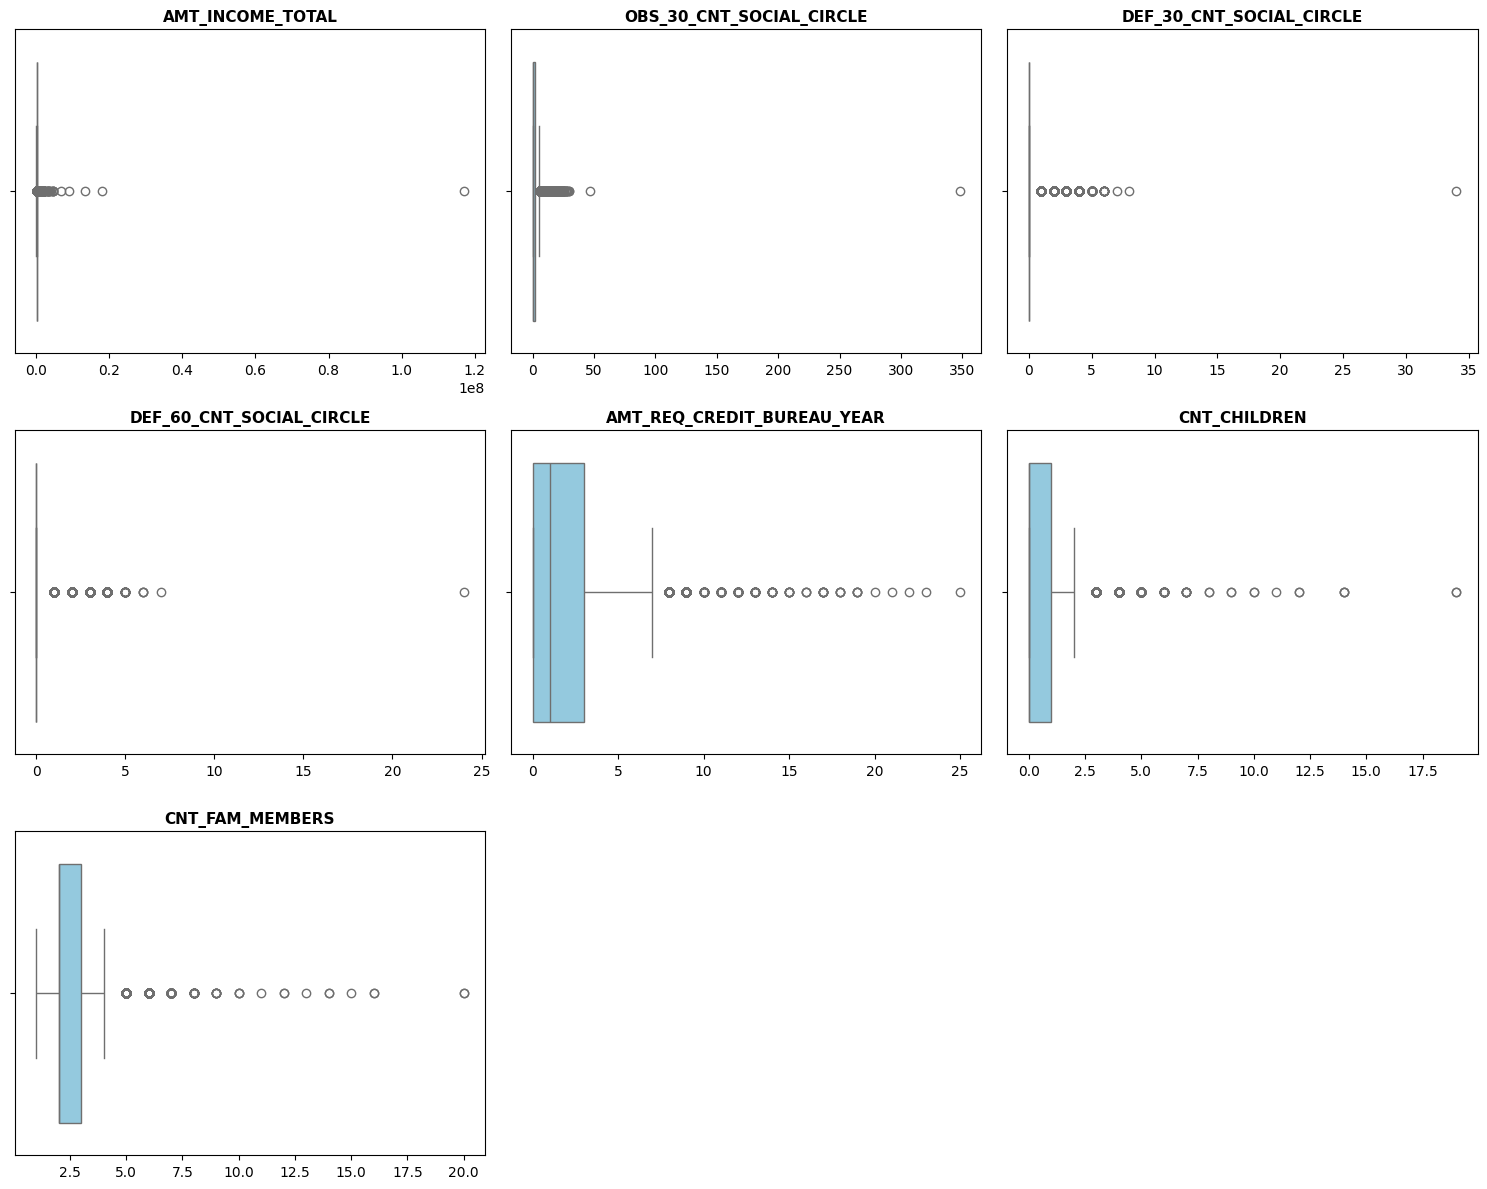

In [ ]:
capped_cols = [
    'AMT_INCOME_TOTAL', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
    'DEF_60_CNT_SOCIAL_CIRCLE', 'AMT_REQ_CREDIT_BUREAU_YEAR',
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS'
]


cols_to_plot = [col for col in capped_cols if col in df_application.columns]

n_cols = 3
n_rows = (len(cols_to_plot) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.boxplot(x=df_application[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
cap_config = {
    "AMT_INCOME_TOTAL": 0.99,
    "OBS_30_CNT_SOCIAL_CIRCLE": 0.98,
    "DEF_30_CNT_SOCIAL_CIRCLE": 0.98,
    "DEF_60_CNT_SOCIAL_CIRCLE": 0.98,
    "AMT_REQ_CREDIT_BUREAU_YEAR": 0.99,
    "CNT_CHILDREN": 0.995,
    "CNT_FAM_MEMBERS": 0.995
}

for col, q in cap_config.items():
    if col in df_application.columns:
        cap_val = df_application[col].quantile(q)

        df_application[f"{col}_OUTLIER"] = (
            df_application[col] > cap_val
        ).astype("int8")

        df_application[col] = df_application[col].clip(upper=cap_val)

        print(f"{col}: capped at {q*100:.1f} percentile → {cap_val:.2f}")

AMT_INCOME_TOTAL: capped at 99.0 percentile → 472500.00
OBS_30_CNT_SOCIAL_CIRCLE: capped at 98.0 percentile → 9.00
DEF_30_CNT_SOCIAL_CIRCLE: capped at 98.0 percentile → 2.00
DEF_60_CNT_SOCIAL_CIRCLE: capped at 98.0 percentile → 1.00
AMT_REQ_CREDIT_BUREAU_YEAR: capped at 99.0 percentile → 8.00
CNT_CHILDREN: capped at 99.5 percentile → 3.00
CNT_FAM_MEMBERS: capped at 99.5 percentile → 5.00


In [ ]:
[col for col in df_application.columns if col.endswith("_OUTLIER")]

['AMT_INCOME_TOTAL_OUTLIER',
 'OBS_30_CNT_SOCIAL_CIRCLE_OUTLIER',
 'DEF_30_CNT_SOCIAL_CIRCLE_OUTLIER',
 'DEF_60_CNT_SOCIAL_CIRCLE_OUTLIER',
 'AMT_REQ_CREDIT_BUREAU_YEAR_OUTLIER',
 'CNT_CHILDREN_OUTLIER',
 'CNT_FAM_MEMBERS_OUTLIER']

**After**

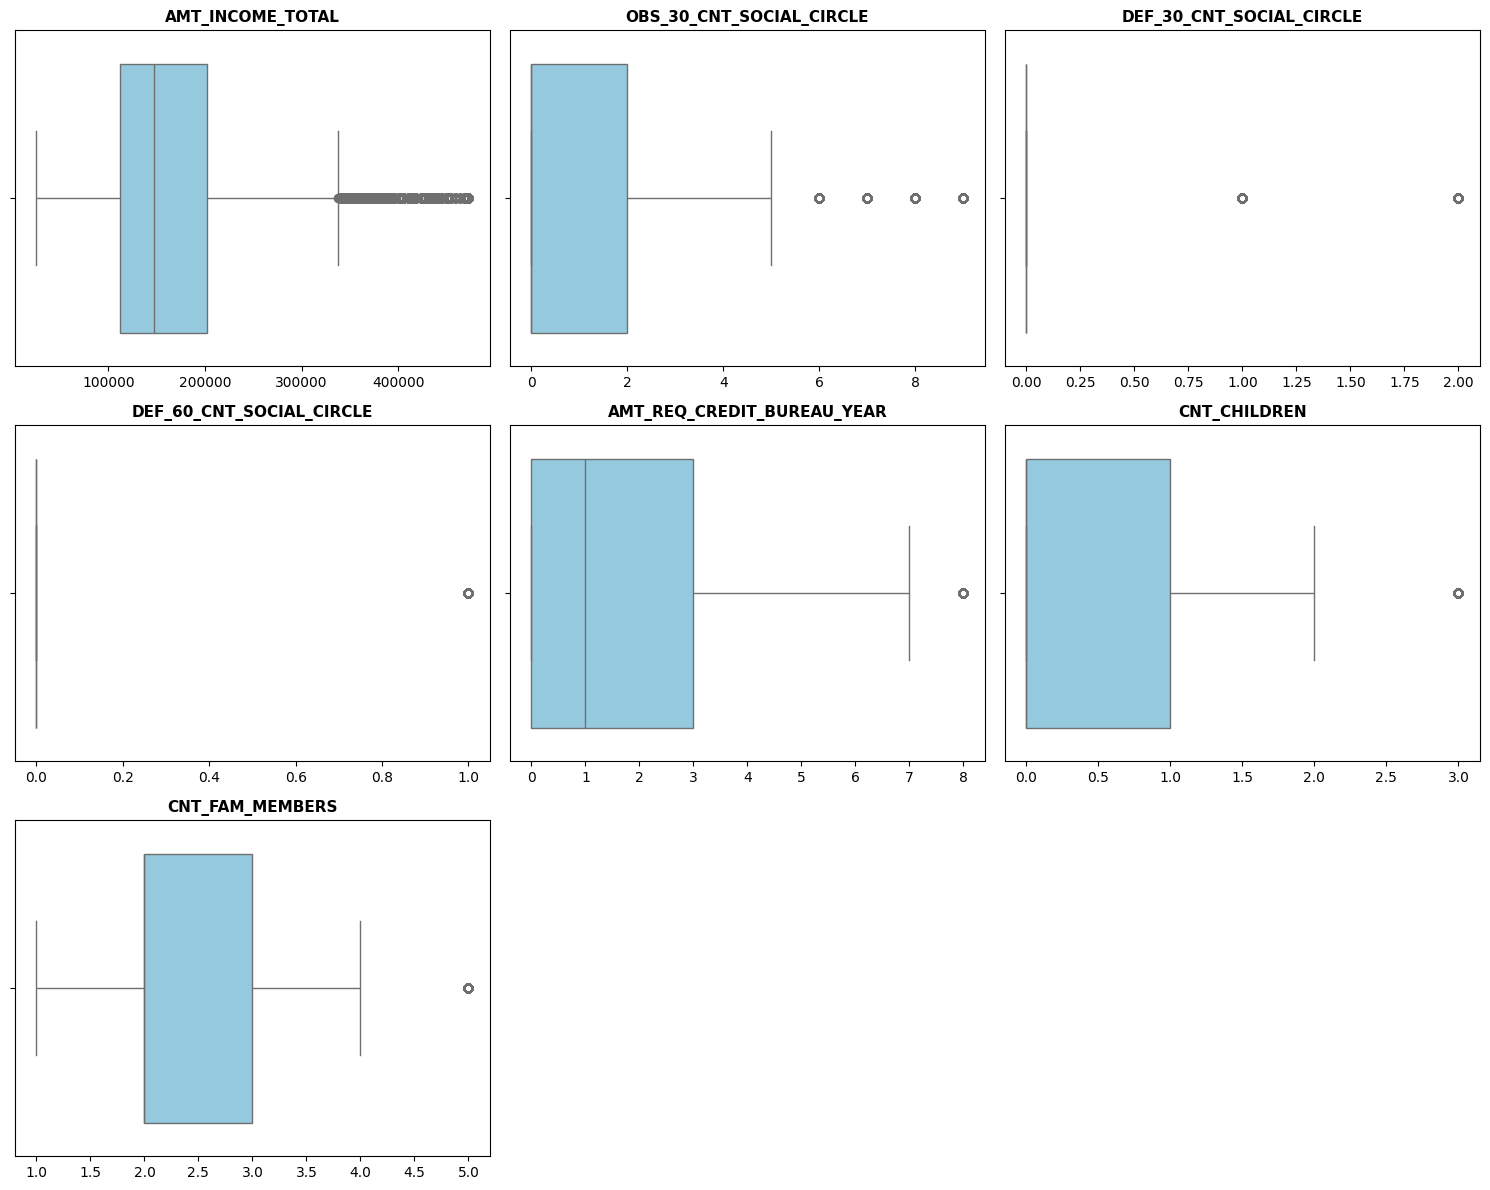

In [ ]:
cols_to_plot = [col for col in capped_cols if col in df_application.columns]

n_cols = 3
n_rows = (len(cols_to_plot) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.boxplot(x=df_application[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
df_application.info()

<class 'pandas.core.frame.DataFrame'>
Index: 307496 entries, 0 to 307510
Data columns (total 78 columns):
 #   Column                              Non-Null Count   Dtype   
---  ------                              --------------   -----   
 0   SK_ID_CURR                          307496 non-null  int32   
 1   TARGET                              307496 non-null  int8    
 2   NAME_CONTRACT_TYPE                  307496 non-null  category
 3   CODE_GENDER                         307496 non-null  category
 4   FLAG_OWN_CAR                        307496 non-null  category
 5   FLAG_OWN_REALTY                     307496 non-null  category
 6   CNT_CHILDREN                        307496 non-null  int8    
 7   AMT_INCOME_TOTAL                    307496 non-null  float32 
 8   AMT_CREDIT                          307496 non-null  float32 
 9   AMT_ANNUITY                         307496 non-null  float32 
 10  NAME_TYPE_SUITE                     307496 non-null  category
 11  NAME_INCOME_TYPE  

## 2.2 Bureau

In [ ]:
print("--- CEK AWAL: BUREAU ---")
print("Dimensi awal:", df_bureau.shape)
print("\nInfo:")
df_bureau.info()

print("\nJumlah missing value:")
print(df_bureau.isna().sum().sort_values(ascending=False).to_string())

print("\nDuplicate rows:", df_bureau.duplicated().sum())

if "SK_ID_BUREAU" in df_bureau.columns:
    print("Duplicate SK_ID_BUREAU:", df_bureau["SK_ID_BUREAU"].duplicated().sum())

if "SK_ID_CURR" in df_bureau.columns:
    print("Jumlah unique SK_ID_CURR:", df_bureau["SK_ID_CURR"].nunique())

--- CEK AWAL: BUREAU ---
Dimensi awal: (1716428, 17)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           object 
 3   CREDIT_CURRENCY         object 
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             object 
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), object(3)
memory usage: 222.6+ MB

Jumlah missing value:


AMT_ANNUITY               1226791
AMT_CREDIT_MAX_OVERDUE    1124488
DAYS_ENDDATE_FACT          633653
AMT_CREDIT_SUM_LIMIT       591780
AMT_CREDIT_SUM_DEBT        257669
DAYS_CREDIT_ENDDATE        105553
AMT_CREDIT_SUM                 13
SK_ID_CURR                      0
SK_ID_BUREAU                    0
CREDIT_DAY_OVERDUE              0
CREDIT_ACTIVE                   0
CREDIT_CURRENCY                 0
DAYS_CREDIT                     0
CNT_CREDIT_PROLONG              0
AMT_CREDIT_SUM_OVERDUE          0
CREDIT_TYPE                     0
DAYS_CREDIT_UPDATE              0



Duplicate rows: 0
Duplicate SK_ID_BUREAU: 0
Jumlah unique SK_ID_CURR: 305811


### 2.2.1 Reduce RAM Usage

In [ ]:
def reduce_mem_usage_safe(df_bureau, use_float16=False):
    """Mengurangi penggunaan memori dataframe secara aman."""
    df_bureau = df_bureau.copy()

    start_mem = df_bureau.memory_usage(deep=True).sum() / 1024**2
    print(f"➜ Memory usage awal: {start_mem:.4f} MB")

    for col in df_bureau.columns:
        col_type = df_bureau[col].dtype

        if pd.api.types.is_bool_dtype(col_type):
            continue

        if pd.api.types.is_datetime64_any_dtype(col_type):
            continue

        if pd.api.types.is_integer_dtype(col_type):
            df_bureau[col] = pd.to_numeric(df_bureau[col], downcast="integer")

        elif pd.api.types.is_float_dtype(col_type):
            if use_float16:
                df_bureau[col] = pd.to_numeric(df_bureau[col], downcast="float")
            else:
                if (
                    df_bureau[col].min() >= np.finfo(np.float32).min
                    and df_bureau[col].max() <= np.finfo(np.float32).max
                ):
                    df_bureau[col] = df_bureau[col].astype(np.float32)

        elif pd.api.types.is_object_dtype(col_type):
            num_unique = df_bureau[col].nunique(dropna=False)
            num_total = len(df_bureau[col])

            if num_total > 0 and num_unique / num_total < 0.5:
                df_bureau[col] = df_bureau[col].astype("category")

    end_mem = df_bureau.memory_usage(deep=True).sum() / 1024**2
    print(f"➜ Memory usage setelah optimasi: {end_mem:.4f} MB")

    if start_mem > 0:
        print(f"➜ Hemat memori: {100 * (start_mem - end_mem) / start_mem:.1f}%\n")

    return df_bureau

In [ ]:
print("--- OPTIMASI MEMORI BUREAU ---")
df_bureau = reduce_mem_usage_safe(df_bureau)

--- OPTIMASI MEMORI BUREAU ---


➜ Memory usage awal: 472.8248 MB


➜ Memory usage setelah optimasi: 85.1219 MB
➜ Hemat memori: 82.0%



In [ ]:
df_bureau.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype   
---  ------                  -----   
 0   SK_ID_CURR              int32   
 1   SK_ID_BUREAU            int32   
 2   CREDIT_ACTIVE           category
 3   CREDIT_CURRENCY         category
 4   DAYS_CREDIT             int16   
 5   CREDIT_DAY_OVERDUE      int16   
 6   DAYS_CREDIT_ENDDATE     float32 
 7   DAYS_ENDDATE_FACT       float32 
 8   AMT_CREDIT_MAX_OVERDUE  float32 
 9   CNT_CREDIT_PROLONG      int8    
 10  AMT_CREDIT_SUM          float32 
 11  AMT_CREDIT_SUM_DEBT     float32 
 12  AMT_CREDIT_SUM_LIMIT    float32 
 13  AMT_CREDIT_SUM_OVERDUE  float32 
 14  CREDIT_TYPE             category
 15  DAYS_CREDIT_UPDATE      int32   
 16  AMT_ANNUITY             float32 
dtypes: category(3), float32(8), int16(2), int32(3), int8(1)
memory usage: 85.1 MB


### 2.2.2 Duplicate Value

In [ ]:
print("Duplicate rows:", df_bureau.duplicated().sum())

if "SK_ID_BUREAU" in df_bureau.columns:
    print("Duplicate SK_ID_BUREAU:", df_bureau["SK_ID_BUREAU"].duplicated().sum())

if "SK_ID_CURR" in df_bureau.columns:
    print("Unique SK_ID_CURR:", df_bureau["SK_ID_CURR"].nunique())

Duplicate rows: 0
Duplicate SK_ID_BUREAU: 0
Unique SK_ID_CURR: 305811


### 2.2.3 Missing Value

In [ ]:
missing_bureau = (
    pd.DataFrame({
        "missing_count": df_bureau.isna().sum(),
        "missing_pct": df_bureau.isna().mean() * 100
    })
    .sort_values("missing_count", ascending=False)
)

print(missing_bureau.to_string())

                        missing_count  missing_pct
AMT_ANNUITY                   1226791    71.473490
AMT_CREDIT_MAX_OVERDUE        1124488    65.513264
DAYS_ENDDATE_FACT              633653    36.916958
AMT_CREDIT_SUM_LIMIT           591780    34.477415
AMT_CREDIT_SUM_DEBT            257669    15.011932
DAYS_CREDIT_ENDDATE            105553     6.149573
AMT_CREDIT_SUM                     13     0.000757
SK_ID_CURR                          0     0.000000
SK_ID_BUREAU                        0     0.000000
CREDIT_DAY_OVERDUE                  0     0.000000
CREDIT_ACTIVE                       0     0.000000
CREDIT_CURRENCY                     0     0.000000
DAYS_CREDIT                         0     0.000000
CNT_CREDIT_PROLONG                  0     0.000000
AMT_CREDIT_SUM_OVERDUE              0     0.000000
CREDIT_TYPE                         0     0.000000
DAYS_CREDIT_UPDATE                  0     0.000000


In [ ]:
print("--- BUAT MISSING FLAGS ---")

missing_flag_cols = [
    "AMT_ANNUITY",
    "AMT_CREDIT_MAX_OVERDUE",
    "DAYS_ENDDATE_FACT",
    "AMT_CREDIT_SUM_LIMIT",
    "AMT_CREDIT_SUM_DEBT",
    "DAYS_CREDIT_ENDDATE",
    "AMT_CREDIT_SUM"
]

for col in missing_flag_cols:
    if col in df_bureau.columns:
        flag_col = f"{col}_MISSING"
        df_bureau[flag_col] = df_bureau[col].isna().astype("int8")
        print(f"{flag_col}: dibuat | jumlah missing awal = {df_bureau[flag_col].sum()}")

print("Dimensi setelah missing flags:", df_bureau.shape)

--- BUAT MISSING FLAGS ---
AMT_ANNUITY_MISSING: dibuat | jumlah missing awal = 1226791
AMT_CREDIT_MAX_OVERDUE_MISSING: dibuat | jumlah missing awal = 1124488
DAYS_ENDDATE_FACT_MISSING: dibuat | jumlah missing awal = 633653
AMT_CREDIT_SUM_LIMIT_MISSING: dibuat | jumlah missing awal = 591780
AMT_CREDIT_SUM_DEBT_MISSING: dibuat | jumlah missing awal = 257669
DAYS_CREDIT_ENDDATE_MISSING: dibuat | jumlah missing awal = 105553
AMT_CREDIT_SUM_MISSING: dibuat | jumlah missing awal = 13
Dimensi setelah missing flags: (1716428, 24)


In [ ]:
[col for col in df_bureau.columns if col.endswith("_MISSING")]

['AMT_ANNUITY_MISSING',
 'AMT_CREDIT_MAX_OVERDUE_MISSING',
 'DAYS_ENDDATE_FACT_MISSING',
 'AMT_CREDIT_SUM_LIMIT_MISSING',
 'AMT_CREDIT_SUM_DEBT_MISSING',
 'DAYS_CREDIT_ENDDATE_MISSING',
 'AMT_CREDIT_SUM_MISSING']

Isi dengan 0

In [ ]:
print("--- IMPUTASI AMOUNT DENGAN 0 ---")

zero_fill_cols = [
    "AMT_CREDIT_MAX_OVERDUE",
    "AMT_CREDIT_SUM_DEBT",
    "AMT_CREDIT_SUM_LIMIT",
    "AMT_CREDIT_SUM_OVERDUE",
    "AMT_ANNUITY"
]

for col in zero_fill_cols:
    if col in df_bureau.columns:
        missing_before = df_bureau[col].isna().sum()
        df_bureau[col] = df_bureau[col].fillna(0)
        missing_after = df_bureau[col].isna().sum()

        print(f"{col}: missing sebelum={missing_before}, sesudah={missing_after}")

--- IMPUTASI AMOUNT DENGAN 0 ---
AMT_CREDIT_MAX_OVERDUE: missing sebelum=1124488, sesudah=0
AMT_CREDIT_SUM_DEBT: missing sebelum=257669, sesudah=0
AMT_CREDIT_SUM_LIMIT: missing sebelum=591780, sesudah=0
AMT_CREDIT_SUM_OVERDUE: missing sebelum=0, sesudah=0
AMT_ANNUITY: missing sebelum=1226791, sesudah=0


Isi dengan Median

In [ ]:
print("--- IMPUTASI AMT_CREDIT_SUM ---")

if "AMT_CREDIT_SUM" in df_bureau.columns:
    missing_before = df_bureau["AMT_CREDIT_SUM"].isna().sum()
    median_credit_sum = df_bureau["AMT_CREDIT_SUM"].median()

    df_bureau["AMT_CREDIT_SUM"] = df_bureau["AMT_CREDIT_SUM"].fillna(median_credit_sum)

    print("Missing sebelum:", missing_before)
    print("Median AMT_CREDIT_SUM:", median_credit_sum)
    print("Missing sesudah:", df_bureau["AMT_CREDIT_SUM"].isna().sum())

--- IMPUTASI AMT_CREDIT_SUM ---
Missing sebelum: 13
Median AMT_CREDIT_SUM: 125518.5
Missing sesudah: 0


In [ ]:
print("--- IMPUTASI KOLOM DAYS KHUSUS ---")

special_days_cols = [
    "DAYS_ENDDATE_FACT",
    "DAYS_CREDIT_ENDDATE"
]

for col in special_days_cols:
    if col in df_bureau.columns:
        missing_before = df_bureau[col].isna().sum()
        median_val = df_bureau[col].median()

        df_bureau[col] = df_bureau[col].fillna(median_val)

        print(f"{col}:")
        print(f"  missing sebelum = {missing_before}")
        print(f"  median          = {median_val}")
        print(f"  missing sesudah = {df_bureau[col].isna().sum()}")

--- IMPUTASI KOLOM DAYS KHUSUS ---


DAYS_ENDDATE_FACT:
  missing sebelum = 633653
  median          = -897.0
  missing sesudah = 0


DAYS_CREDIT_ENDDATE:
  missing sebelum = 105553
  median          = -330.0
  missing sesudah = 0


### 2.2.4 Anomali Days Value

In [ ]:
print("--- CEK ANOMALI 365243 PADA DAYS_* ---")

days_cols = [col for col in df_bureau.columns if col.startswith("DAYS_")]

for col in days_cols:
    anom_count = (df_bureau[col] == 365243).sum()
    print(f"{col}: {anom_count}")

--- CEK ANOMALI 365243 PADA DAYS_* ---
DAYS_CREDIT: 0
DAYS_CREDIT_ENDDATE: 0
DAYS_ENDDATE_FACT: 0
DAYS_CREDIT_UPDATE: 0
DAYS_ENDDATE_FACT_MISSING: 0
DAYS_CREDIT_ENDDATE_MISSING: 0


### 2.2.5 Category type Handle

In [ ]:
print("--- HANDLE KATEGORIKAL ---")

cat_cols = df_bureau.select_dtypes(include=["object", "category"]).columns.tolist()

print("Kolom kategorikal:", cat_cols)

for col in cat_cols:
    if str(df_bureau[col].dtype) == "category":
        if "Unknown" not in df_bureau[col].cat.categories:
            df_bureau[col] = df_bureau[col].cat.add_categories("Unknown")

    df_bureau[col] = df_bureau[col].fillna("Unknown")

print("Missing kategorikal setelah imputasi:")
print(df_bureau[cat_cols].isna().sum())

--- HANDLE KATEGORIKAL ---
Kolom kategorikal: ['CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'CREDIT_TYPE']
Missing kategorikal setelah imputasi:
CREDIT_ACTIVE      0
CREDIT_CURRENCY    0
CREDIT_TYPE        0
dtype: int64


In [ ]:
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df_bureau[col].value_counts(dropna=False))


--- CREDIT_ACTIVE ---


CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21
Unknown           0
Name: count, dtype: int64

--- CREDIT_CURRENCY ---
CREDIT_CURRENCY
currency 1    1715020
currency 2       1224
currency 3        174
currency 4         10
Unknown             0
Name: count, dtype: int64

--- CREDIT_TYPE ---
CREDIT_TYPE
Consumer credit                                 1251615
Credit card                                      402195
Car loan                                          27690
Mortgage                                          18391
Microloan                                         12413
Loan for business development                      1975
Another type of loan                               1017
Unknown type of loan                                555
Loan for working capital replenishment              469
Cash loan (non-earmarked)                            56
Real estate loan                                     27
Loan for the purchase of equipment

### 2.2.6 Simple Feature Engineering

In [ ]:
df_bureau.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 24 columns):
 #   Column                          Dtype   
---  ------                          -----   
 0   SK_ID_CURR                      int32   
 1   SK_ID_BUREAU                    int32   
 2   CREDIT_ACTIVE                   category
 3   CREDIT_CURRENCY                 category
 4   DAYS_CREDIT                     int16   
 5   CREDIT_DAY_OVERDUE              int16   
 6   DAYS_CREDIT_ENDDATE             float32 
 7   DAYS_ENDDATE_FACT               float32 
 8   AMT_CREDIT_MAX_OVERDUE          float32 
 9   CNT_CREDIT_PROLONG              int8    
 10  AMT_CREDIT_SUM                  float32 
 11  AMT_CREDIT_SUM_DEBT             float32 
 12  AMT_CREDIT_SUM_LIMIT            float32 
 13  AMT_CREDIT_SUM_OVERDUE          float32 
 14  CREDIT_TYPE                     category
 15  DAYS_CREDIT_UPDATE              int32   
 16  AMT_ANNUITY                     float32 
 17  AMT_ANNU

In [ ]:
print("--- FEATURE SEDERHANA BUREAU RECORD ---")

if {"AMT_CREDIT_SUM_DEBT", "AMT_CREDIT_SUM"}.issubset(df_bureau.columns):
    df_bureau["BUREAU_DEBT_CREDIT_RATIO"] = (
        df_bureau["AMT_CREDIT_SUM_DEBT"] /
        (df_bureau["AMT_CREDIT_SUM"] + 1)
    )
    print("BUREAU_DEBT_CREDIT_RATIO dibuat")

if {"AMT_CREDIT_SUM_OVERDUE", "AMT_CREDIT_SUM"}.issubset(df_bureau.columns):
    df_bureau["BUREAU_OVERDUE_CREDIT_RATIO"] = (
        df_bureau["AMT_CREDIT_SUM_OVERDUE"] /
        (df_bureau["AMT_CREDIT_SUM"] + 1)
    )
    print("BUREAU_OVERDUE_CREDIT_RATIO dibuat")

if {"AMT_CREDIT_SUM_LIMIT", "AMT_CREDIT_SUM"}.issubset(df_bureau.columns):
    df_bureau["BUREAU_LIMIT_CREDIT_RATIO"] = (
        df_bureau["AMT_CREDIT_SUM_LIMIT"] /
        (df_bureau["AMT_CREDIT_SUM"] + 1)
    )
    print("BUREAU_LIMIT_CREDIT_RATIO dibuat")

if {"AMT_CREDIT_SUM_OVERDUE", "AMT_CREDIT_SUM_DEBT"}.issubset(df_bureau.columns):
    df_bureau["BUREAU_OVERDUE_DEBT_RATIO"] = (
        df_bureau["AMT_CREDIT_SUM_OVERDUE"] /
        (df_bureau["AMT_CREDIT_SUM_DEBT"] + 1)
    )
    print("BUREAU_OVERDUE_DEBT_RATIO dibuat")

if {"DAYS_CREDIT_ENDDATE", "DAYS_CREDIT"}.issubset(df_bureau.columns):
    df_bureau["BUREAU_CREDIT_DURATION"] = (
        df_bureau["DAYS_CREDIT_ENDDATE"] -
        df_bureau["DAYS_CREDIT"]
    )
    print("BUREAU_CREDIT_DURATION dibuat")

if {"DAYS_CREDIT_UPDATE", "DAYS_CREDIT"}.issubset(df_bureau.columns):
    df_bureau["BUREAU_UPDATE_RECENCY"] = (
        df_bureau["DAYS_CREDIT_UPDATE"] -
        df_bureau["DAYS_CREDIT"]
    )
    print("BUREAU_UPDATE_RECENCY dibuat")

print("Dimensi setelah fitur bureau:", df_bureau.shape)

--- FEATURE SEDERHANA BUREAU RECORD ---
BUREAU_DEBT_CREDIT_RATIO dibuat
BUREAU_OVERDUE_CREDIT_RATIO dibuat


BUREAU_LIMIT_CREDIT_RATIO dibuat
BUREAU_OVERDUE_DEBT_RATIO dibuat
BUREAU_CREDIT_DURATION dibuat
BUREAU_UPDATE_RECENCY dibuat
Dimensi setelah fitur bureau: (1716428, 30)


### 2.2.7 Deep Cleaning Remaining Value

In [ ]:
print("--- : CLEAN INF DAN MISSING TERSISA ---")

df_bureau = df_bureau.replace([np.inf, -np.inf], 0)

num_cols = df_bureau.select_dtypes(include=[np.number]).columns.tolist()

for col in num_cols:
    missing_before = df_bureau[col].isna().sum()

    if missing_before > 0:
        median_val = df_bureau[col].median()
        df_bureau[col] = df_bureau[col].fillna(median_val)
        print(f"{col}: missing {missing_before} diisi median {median_val}")

print("Total missing:", df_bureau.isna().sum().sum())

--- : CLEAN INF DAN MISSING TERSISA ---


Total missing: 0


In [ ]:
print("--- FINAL CHECK BUREAU CLEAN ---")

print("Dimensi akhir:", df_bureau.shape)
print("Total missing:", df_bureau.isna().sum().sum())
print("Duplicate rows:", df_bureau.duplicated().sum())

if "SK_ID_BUREAU" in df_bureau.columns:
    print("Duplicate SK_ID_BUREAU:", df_bureau["SK_ID_BUREAU"].duplicated().sum())

print("\nMissing summary:")
print(df_bureau.isna().sum().sort_values(ascending=False).to_string())

print("\nDtypes:")
print(df_bureau.dtypes)

--- FINAL CHECK BUREAU CLEAN ---
Dimensi akhir: (1716428, 30)
Total missing: 0


Duplicate rows: 0
Duplicate SK_ID_BUREAU: 0

Missing summary:
SK_ID_CURR                        0
SK_ID_BUREAU                      0
CREDIT_ACTIVE                     0
CREDIT_CURRENCY                   0
DAYS_CREDIT                       0
CREDIT_DAY_OVERDUE                0
DAYS_CREDIT_ENDDATE               0
DAYS_ENDDATE_FACT                 0
AMT_CREDIT_MAX_OVERDUE            0
CNT_CREDIT_PROLONG                0
AMT_CREDIT_SUM                    0
AMT_CREDIT_SUM_DEBT               0
AMT_CREDIT_SUM_LIMIT              0
AMT_CREDIT_SUM_OVERDUE            0
CREDIT_TYPE                       0
DAYS_CREDIT_UPDATE                0
AMT_ANNUITY                       0
AMT_ANNUITY_MISSING               0
AMT_CREDIT_MAX_OVERDUE_MISSING    0
DAYS_ENDDATE_FACT_MISSING         0
AMT_CREDIT_SUM_LIMIT_MISSING      0
AMT_CREDIT_SUM_DEBT_MISSING       0
DAYS_CREDIT_ENDDATE_MISSING       0
AMT_CREDIT_SUM_MISSING            0
BUREAU_DEBT_CREDIT_RATIO          0
BUREAU_OVERDUE_CREDIT_RATIO       0
BU

### 2.2.8 Aggregation

#### 2.2.8.1 Basic Count

In [ ]:
print("--- CEK AWAL SEBELUM AGREGASI BUREAU ---")

print("Dimensi df_bureau_clean:", df_bureau.shape)
print("Jumlah unique SK_ID_CURR:", df_bureau["SK_ID_CURR"].nunique())
print("Jumlah unique SK_ID_BUREAU:", df_bureau["SK_ID_BUREAU"].nunique())

--- CEK AWAL SEBELUM AGREGASI BUREAU ---
Dimensi df_bureau_clean: (1716428, 30)
Jumlah unique SK_ID_CURR: 305811
Jumlah unique SK_ID_BUREAU: 1716428


In [ ]:
print("--- TAHAP 1: BASIC BUREAU COUNT ---")

bureau_base_agg = df_bureau.groupby("SK_ID_CURR").agg(
    BUREAU_RECORD_COUNT=("SK_ID_BUREAU", "count"),
    BUREAU_UNIQUE_CREDIT_TYPE_COUNT=("CREDIT_TYPE", "nunique"),
    BUREAU_UNIQUE_CREDIT_ACTIVE_COUNT=("CREDIT_ACTIVE", "nunique"),
    BUREAU_UNIQUE_CURRENCY_COUNT=("CREDIT_CURRENCY", "nunique")
).reset_index()

print("Dimensi bureau_base_agg:", bureau_base_agg.shape)
bureau_base_agg.head()

--- TAHAP 1: BASIC BUREAU COUNT ---


Dimensi bureau_base_agg: (305811, 5)


,SK_ID_CURR,BUREAU_RECORD_COUNT,BUREAU_UNIQUE_CREDIT_TYPE_COUNT,BUREAU_UNIQUE_CREDIT_ACTIVE_COUNT,BUREAU_UNIQUE_CURRENCY_COUNT
0,100001,7,1,2,1
1,100002,8,2,2,1
2,100003,4,2,2,1
3,100004,2,1,1,1
4,100005,3,2,2,1


#### 2.2.8.2 Numeric Aggregation

In [ ]:
print("--- TAHAP 2: NUMERIC AGGREGATION ---")

num_agg_cols = [
    "DAYS_CREDIT",
    "CREDIT_DAY_OVERDUE",
    "DAYS_CREDIT_ENDDATE",
    "DAYS_ENDDATE_FACT",
    "AMT_CREDIT_MAX_OVERDUE",
    "CNT_CREDIT_PROLONG",
    "AMT_CREDIT_SUM",
    "AMT_CREDIT_SUM_DEBT",
    "AMT_CREDIT_SUM_LIMIT",
    "AMT_CREDIT_SUM_OVERDUE",
    "DAYS_CREDIT_UPDATE",
    "AMT_ANNUITY",
    "BUREAU_DEBT_CREDIT_RATIO",
    "BUREAU_OVERDUE_CREDIT_RATIO",
    "BUREAU_LIMIT_CREDIT_RATIO",
    "BUREAU_OVERDUE_DEBT_RATIO",
    "BUREAU_CREDIT_DURATION",
    "BUREAU_UPDATE_RECENCY"
]

num_agg_cols = [col for col in num_agg_cols if col in df_bureau.columns]

bureau_num_agg = df_bureau.groupby("SK_ID_CURR")[num_agg_cols].agg(
    ["mean", "max", "min", "sum"]
)

bureau_num_agg.columns = [
    "BUREAU_" + col.upper() + "_" + stat.upper()
    for col, stat in bureau_num_agg.columns
]

bureau_num_agg = bureau_num_agg.reset_index()

print("Dimensi bureau_num_agg:", bureau_num_agg.shape)
bureau_num_agg.head()

--- TAHAP 2: NUMERIC AGGREGATION ---


Dimensi bureau_num_agg: (305811, 73)


,SK_ID_CURR,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_MAX,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_SUM,BUREAU_CREDIT_DAY_OVERDUE_MEAN,BUREAU_CREDIT_DAY_OVERDUE_MAX,BUREAU_CREDIT_DAY_OVERDUE_MIN,BUREAU_CREDIT_DAY_OVERDUE_SUM,BUREAU_DAYS_CREDIT_ENDDATE_MEAN,...,BUREAU_BUREAU_OVERDUE_DEBT_RATIO_MIN,BUREAU_BUREAU_OVERDUE_DEBT_RATIO_SUM,BUREAU_BUREAU_CREDIT_DURATION_MEAN,BUREAU_BUREAU_CREDIT_DURATION_MAX,BUREAU_BUREAU_CREDIT_DURATION_MIN,BUREAU_BUREAU_CREDIT_DURATION_SUM,BUREAU_BUREAU_UPDATE_RECENCY_MEAN,BUREAU_BUREAU_UPDATE_RECENCY_MAX,BUREAU_BUREAU_UPDATE_RECENCY_MIN,BUREAU_BUREAU_UPDATE_RECENCY_SUM
0,100001,-735.000000,-49,-1572,-5145,0.0,0,0,0,82.428574,...,0.0,0.0,817.428589,1827.0,243.0,5722.0,641.857143,1417,33,4493
1,100002,-874.000000,-103,-1437,-6992,0.0,0,0,0,-344.250000,...,0.0,0.0,529.750000,1822.0,-227.0,4238.0,374.125000,1035,79,2993
2,100003,-1400.750000,-606,-2586,-5603,0.0,0,0,0,-544.500000,...,0.0,0.0,856.250000,1822.0,152.0,3425.0,584.750000,1096,225,2339
3,100004,-867.000000,-408,-1326,-1734,0.0,0,0,0,-488.500000,...,0.0,0.0,378.500000,731.0,26.0,757.0,335.000000,644,26,670
4,100005,-190.666667,-62,-373,-572,0.0,0,0,0,439.333344,...,0.0,0.0,630.000000,1461.0,184.0,1890.0,136.333333,252,31,409


#### 2.2.8.3 Missing Flag Aggregation

In [ ]:
print("--- MISSING FLAG AGGREGATION ---")

missing_flag_cols = [
    col for col in df_bureau.columns
    if col.endswith("_MISSING")
]

bureau_missing_agg = df_bureau.groupby("SK_ID_CURR")[missing_flag_cols].agg(
    ["sum", "mean"]
)

bureau_missing_agg.columns = [
    "BUREAU_" + col.upper() + "_" + stat.upper()
    for col, stat in bureau_missing_agg.columns
]

bureau_missing_agg = bureau_missing_agg.reset_index()

print("Missing flag cols:", missing_flag_cols)
print("Dimensi bureau_missing_agg:", bureau_missing_agg.shape)
bureau_missing_agg.head()

--- MISSING FLAG AGGREGATION ---


Missing flag cols: ['AMT_ANNUITY_MISSING', 'AMT_CREDIT_MAX_OVERDUE_MISSING', 'DAYS_ENDDATE_FACT_MISSING', 'AMT_CREDIT_SUM_LIMIT_MISSING', 'AMT_CREDIT_SUM_DEBT_MISSING', 'DAYS_CREDIT_ENDDATE_MISSING', 'AMT_CREDIT_SUM_MISSING']
Dimensi bureau_missing_agg: (305811, 15)


,SK_ID_CURR,BUREAU_AMT_ANNUITY_MISSING_SUM,BUREAU_AMT_ANNUITY_MISSING_MEAN,BUREAU_AMT_CREDIT_MAX_OVERDUE_MISSING_SUM,BUREAU_AMT_CREDIT_MAX_OVERDUE_MISSING_MEAN,BUREAU_DAYS_ENDDATE_FACT_MISSING_SUM,BUREAU_DAYS_ENDDATE_FACT_MISSING_MEAN,BUREAU_AMT_CREDIT_SUM_LIMIT_MISSING_SUM,BUREAU_AMT_CREDIT_SUM_LIMIT_MISSING_MEAN,BUREAU_AMT_CREDIT_SUM_DEBT_MISSING_SUM,BUREAU_AMT_CREDIT_SUM_DEBT_MISSING_MEAN,BUREAU_DAYS_CREDIT_ENDDATE_MISSING_SUM,BUREAU_DAYS_CREDIT_ENDDATE_MISSING_MEAN,BUREAU_AMT_CREDIT_SUM_MISSING_SUM,BUREAU_AMT_CREDIT_SUM_MISSING_MEAN
0,100001,0,0.000,7,1.000000,3,0.428571,1,0.142857,0,0.000,0,0.00,0,0.0
1,100002,1,0.125,3,0.375000,2,0.250000,4,0.500000,3,0.375,2,0.25,0,0.0
2,100003,4,1.000,0,0.000000,1,0.250000,0,0.000000,0,0.000,0,0.00,0,0.0
3,100004,2,1.000,1,0.500000,0,0.000000,0,0.000000,0,0.000,0,0.00,0,0.0
4,100005,0,0.000,2,0.666667,2,0.666667,0,0.000000,0,0.000,0,0.00,0,0.0


#### 2.2.8.4 Active Credit Aggregation

In [ ]:
print("--- CREDIT_ACTIVE AGGREGATION ---")

bureau_active_dummies = pd.get_dummies(
    df_bureau[["SK_ID_CURR", "CREDIT_ACTIVE"]],
    columns=["CREDIT_ACTIVE"],
    prefix="BUREAU_CREDIT_ACTIVE"
)

bureau_active_agg = bureau_active_dummies.groupby("SK_ID_CURR").sum().reset_index()

print("Dimensi bureau_active_agg:", bureau_active_agg.shape)
bureau_active_agg.head()

--- CREDIT_ACTIVE AGGREGATION ---


Dimensi bureau_active_agg: (305811, 6)


,SK_ID_CURR,BUREAU_CREDIT_ACTIVE_Active,BUREAU_CREDIT_ACTIVE_Bad debt,BUREAU_CREDIT_ACTIVE_Closed,BUREAU_CREDIT_ACTIVE_Sold,BUREAU_CREDIT_ACTIVE_Unknown
0,100001,3,0,4,0,0
1,100002,2,0,6,0,0
2,100003,1,0,3,0,0
3,100004,0,0,2,0,0
4,100005,2,0,1,0,0


#### 2.2.8.5 Credit Type Aggregation

In [ ]:
print("--- CREDIT_TYPE AGGREGATION ---")

bureau_type_dummies = pd.get_dummies(
    df_bureau[["SK_ID_CURR", "CREDIT_TYPE"]],
    columns=["CREDIT_TYPE"],
    prefix="BUREAU_CREDIT_TYPE"
)

bureau_type_agg = bureau_type_dummies.groupby("SK_ID_CURR").sum().reset_index()

print("Dimensi bureau_type_agg:", bureau_type_agg.shape)
bureau_type_agg.head()

--- CREDIT_TYPE AGGREGATION ---


Dimensi bureau_type_agg: (305811, 17)


,SK_ID_CURR,BUREAU_CREDIT_TYPE_Another type of loan,BUREAU_CREDIT_TYPE_Car loan,BUREAU_CREDIT_TYPE_Cash loan (non-earmarked),BUREAU_CREDIT_TYPE_Consumer credit,BUREAU_CREDIT_TYPE_Credit card,BUREAU_CREDIT_TYPE_Interbank credit,BUREAU_CREDIT_TYPE_Loan for business development,BUREAU_CREDIT_TYPE_Loan for purchase of shares (margin lending),BUREAU_CREDIT_TYPE_Loan for the purchase of equipment,BUREAU_CREDIT_TYPE_Loan for working capital replenishment,BUREAU_CREDIT_TYPE_Microloan,BUREAU_CREDIT_TYPE_Mobile operator loan,BUREAU_CREDIT_TYPE_Mortgage,BUREAU_CREDIT_TYPE_Real estate loan,BUREAU_CREDIT_TYPE_Unknown type of loan,BUREAU_CREDIT_TYPE_Unknown
0,100001,0,0,0,7,0,0,0,0,0,0,0,0,0,0,0,0
1,100002,0,0,0,4,4,0,0,0,0,0,0,0,0,0,0,0
2,100003,0,0,0,2,2,0,0,0,0,0,0,0,0,0,0,0
3,100004,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0
4,100005,0,0,0,2,1,0,0,0,0,0,0,0,0,0,0,0


#### 2.2.8.6 Credit Currency Aggregation

In [ ]:
print("--- CREDIT_CURRENCY AGGREGATION ---")

bureau_currency_dummies = pd.get_dummies(
    df_bureau[["SK_ID_CURR", "CREDIT_CURRENCY"]],
    columns=["CREDIT_CURRENCY"],
    prefix="BUREAU_CREDIT_CURRENCY"
)

bureau_currency_agg = bureau_currency_dummies.groupby("SK_ID_CURR").sum().reset_index()

print("Dimensi bureau_currency_agg:", bureau_currency_agg.shape)
bureau_currency_agg.head()

--- CREDIT_CURRENCY AGGREGATION ---


Dimensi bureau_currency_agg: (305811, 6)


,SK_ID_CURR,BUREAU_CREDIT_CURRENCY_currency 1,BUREAU_CREDIT_CURRENCY_currency 2,BUREAU_CREDIT_CURRENCY_currency 3,BUREAU_CREDIT_CURRENCY_currency 4,BUREAU_CREDIT_CURRENCY_Unknown
0,100001,7,0,0,0,0
1,100002,8,0,0,0,0
2,100003,4,0,0,0,0
3,100004,2,0,0,0,0
4,100005,3,0,0,0,0


#### 2.2.8.7 Active Credit Aggregation

In [ ]:
print("--- ACTIVE CREDIT AGGREGATION ---")

bureau_active_only = df_bureau[
    df_bureau["CREDIT_ACTIVE"] == "Active"
].copy()

print("Jumlah record Active:", bureau_active_only.shape[0])

active_num_cols = [
    "AMT_CREDIT_SUM",
    "AMT_CREDIT_SUM_DEBT",
    "AMT_CREDIT_SUM_LIMIT",
    "AMT_CREDIT_SUM_OVERDUE",
    "AMT_ANNUITY",
    "CREDIT_DAY_OVERDUE",
    "DAYS_CREDIT",
    "DAYS_CREDIT_ENDDATE",
    "BUREAU_DEBT_CREDIT_RATIO",
    "BUREAU_OVERDUE_CREDIT_RATIO"
]

active_num_cols = [
    col for col in active_num_cols
    if col in bureau_active_only.columns
]

bureau_active_num_agg = bureau_active_only.groupby("SK_ID_CURR")[active_num_cols].agg(
    ["mean", "max", "sum"]
)

bureau_active_num_agg.columns = [
    "BUREAU_ACTIVE_" + col.upper() + "_" + stat.upper()
    for col, stat in bureau_active_num_agg.columns
]

bureau_active_num_agg = bureau_active_num_agg.reset_index()

print("Dimensi bureau_active_num_agg:", bureau_active_num_agg.shape)
bureau_active_num_agg.head()

--- ACTIVE CREDIT AGGREGATION ---
Jumlah record Active: 630607


Dimensi bureau_active_num_agg: (251815, 31)


,SK_ID_CURR,BUREAU_ACTIVE_AMT_CREDIT_SUM_MEAN,BUREAU_ACTIVE_AMT_CREDIT_SUM_MAX,BUREAU_ACTIVE_AMT_CREDIT_SUM_SUM,BUREAU_ACTIVE_AMT_CREDIT_SUM_DEBT_MEAN,BUREAU_ACTIVE_AMT_CREDIT_SUM_DEBT_MAX,BUREAU_ACTIVE_AMT_CREDIT_SUM_DEBT_SUM,BUREAU_ACTIVE_AMT_CREDIT_SUM_LIMIT_MEAN,BUREAU_ACTIVE_AMT_CREDIT_SUM_LIMIT_MAX,BUREAU_ACTIVE_AMT_CREDIT_SUM_LIMIT_SUM,...,BUREAU_ACTIVE_DAYS_CREDIT_SUM,BUREAU_ACTIVE_DAYS_CREDIT_ENDDATE_MEAN,BUREAU_ACTIVE_DAYS_CREDIT_ENDDATE_MAX,BUREAU_ACTIVE_DAYS_CREDIT_ENDDATE_SUM,BUREAU_ACTIVE_BUREAU_DEBT_CREDIT_RATIO_MEAN,BUREAU_ACTIVE_BUREAU_DEBT_CREDIT_RATIO_MAX,BUREAU_ACTIVE_BUREAU_DEBT_CREDIT_RATIO_SUM,BUREAU_ACTIVE_BUREAU_OVERDUE_CREDIT_RATIO_MEAN,BUREAU_ACTIVE_BUREAU_OVERDUE_CREDIT_RATIO_MAX,BUREAU_ACTIVE_BUREAU_OVERDUE_CREDIT_RATIO_SUM
0,100001,294675.00000,378000.0,884025.0000,198895.50,373239.0,596686.5,0.000000,0.000000,0.000000,...,-928,1030.333374,1778.0,3091.0,0.659206,0.987402,1.977617,0.0,0.0,0.0
1,100002,240994.28125,450000.0,481988.5625,122890.50,245781.0,245781.0,15994.282227,31988.564453,31988.564453,...,-1145,225.000000,780.0,450.0,0.273089,0.546179,0.546179,0.0,0.0,0.0
2,100003,810000.00000,810000.0,810000.0000,0.00,0.0,0.0,810000.000000,810000.000000,810000.000000,...,-606,1216.000000,1216.0,1216.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
3,100005,299313.00000,568800.0,598626.0000,284204.25,543087.0,568408.5,0.000000,0.000000,0.000000,...,-199,723.000000,1324.0,1446.0,0.901869,0.954793,1.803738,0.0,0.0,0.0
4,100008,267606.00000,267606.0,267606.0000,240057.00,240057.0,240057.0,0.000000,0.000000,0.000000,...,-78,471.000000,471.0,471.0,0.897050,0.897050,0.897050,0.0,0.0,0.0


#### 2.2.8.8 Closed Credit Aggregation

In [ ]:
print("--- CLOSED CREDIT AGGREGATION ---")

bureau_closed_only = df_bureau[
    df_bureau["CREDIT_ACTIVE"] == "Closed"
].copy()

print("Jumlah record Closed:", bureau_closed_only.shape[0])

closed_num_cols = [
    "AMT_CREDIT_SUM",
    "AMT_CREDIT_SUM_DEBT",
    "AMT_CREDIT_SUM_OVERDUE",
    "AMT_CREDIT_MAX_OVERDUE",
    "DAYS_CREDIT",
    "DAYS_ENDDATE_FACT",
    "BUREAU_CREDIT_DURATION"
]

closed_num_cols = [
    col for col in closed_num_cols
    if col in bureau_closed_only.columns
]

bureau_closed_num_agg = bureau_closed_only.groupby("SK_ID_CURR")[closed_num_cols].agg(
    ["mean", "max", "sum"]
)

bureau_closed_num_agg.columns = [
    "BUREAU_CLOSED_" + col.upper() + "_" + stat.upper()
    for col, stat in bureau_closed_num_agg.columns
]

bureau_closed_num_agg = bureau_closed_num_agg.reset_index()

print("Dimensi bureau_closed_num_agg:", bureau_closed_num_agg.shape)
bureau_closed_num_agg.head()

--- CLOSED CREDIT AGGREGATION ---
Jumlah record Closed: 1079273


Dimensi bureau_closed_num_agg: (267925, 22)


,SK_ID_CURR,BUREAU_CLOSED_AMT_CREDIT_SUM_MEAN,BUREAU_CLOSED_AMT_CREDIT_SUM_MAX,BUREAU_CLOSED_AMT_CREDIT_SUM_SUM,BUREAU_CLOSED_AMT_CREDIT_SUM_DEBT_MEAN,BUREAU_CLOSED_AMT_CREDIT_SUM_DEBT_MAX,BUREAU_CLOSED_AMT_CREDIT_SUM_DEBT_SUM,BUREAU_CLOSED_AMT_CREDIT_SUM_OVERDUE_MEAN,BUREAU_CLOSED_AMT_CREDIT_SUM_OVERDUE_MAX,BUREAU_CLOSED_AMT_CREDIT_SUM_OVERDUE_SUM,...,BUREAU_CLOSED_AMT_CREDIT_MAX_OVERDUE_SUM,BUREAU_CLOSED_DAYS_CREDIT_MEAN,BUREAU_CLOSED_DAYS_CREDIT_MAX,BUREAU_CLOSED_DAYS_CREDIT_SUM,BUREAU_CLOSED_DAYS_ENDDATE_FACT_MEAN,BUREAU_CLOSED_DAYS_ENDDATE_FACT_MAX,BUREAU_CLOSED_DAYS_ENDDATE_FACT_SUM,BUREAU_CLOSED_BUREAU_CREDIT_DURATION_MEAN,BUREAU_CLOSED_BUREAU_CREDIT_DURATION_MAX,BUREAU_CLOSED_BUREAU_CREDIT_DURATION_SUM
0,100001,142335.000000,279720.000000,569340.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,-1054.250000,-857,-4217,-825.500000,-544.0,-3302.0,425.750000,730.0,1703.0
1,100002,63844.500000,135000.000000,383067.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,8364.644531,-974.500000,-476,-5847,-697.500000,-36.0,-4185.0,440.500000,1105.0,2643.0
2,100003,69133.500000,112500.000000,207400.500000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,-1665.666667,-775,-4997,-1097.333374,-540.0,-3292.0,534.333313,1096.0,1603.0
3,100004,94518.898438,94537.796875,189037.796875,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,-867.000000,-408,-1734,-532.500000,-382.0,-1065.0,378.500000,731.0,757.0
4,100005,58500.000000,58500.000000,58500.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,-373.000000,-373,-373,-123.000000,-123.0,-123.0,245.000000,245.0,245.0


#### 2.2.8.9 Merge Result

In [ ]:
print("--- MERGE SEMUA AGGREGATION BUREAU ---")

bureau_aggs = [
    bureau_base_agg,
    bureau_num_agg,
    bureau_missing_agg,
    bureau_active_agg,
    bureau_type_agg,
    bureau_currency_agg,
    bureau_active_num_agg,
    bureau_closed_num_agg
]

df_bureau_agg = bureau_aggs[0]

for agg_df in bureau_aggs[1:]:
    df_bureau_agg = df_bureau_agg.merge(
        agg_df,
        on="SK_ID_CURR",
        how="left"
    )

df_bureau_agg = df_bureau_agg.fillna(0)

print("Dimensi df_bureau_agg:", df_bureau_agg.shape)
print("Unique SK_ID_CURR:", df_bureau_agg["SK_ID_CURR"].nunique())
print("Duplicate SK_ID_CURR:", df_bureau_agg["SK_ID_CURR"].duplicated().sum())
print("Total missing:", df_bureau_agg.isna().sum().sum())

df_bureau_agg.head()

--- MERGE SEMUA AGGREGATION BUREAU ---


Dimensi df_bureau_agg: (305811, 168)
Unique SK_ID_CURR: 305811
Duplicate SK_ID_CURR: 0
Total missing: 0


,SK_ID_CURR,BUREAU_RECORD_COUNT,BUREAU_UNIQUE_CREDIT_TYPE_COUNT,BUREAU_UNIQUE_CREDIT_ACTIVE_COUNT,BUREAU_UNIQUE_CURRENCY_COUNT,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_MAX,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_SUM,BUREAU_CREDIT_DAY_OVERDUE_MEAN,...,BUREAU_CLOSED_AMT_CREDIT_MAX_OVERDUE_SUM,BUREAU_CLOSED_DAYS_CREDIT_MEAN,BUREAU_CLOSED_DAYS_CREDIT_MAX,BUREAU_CLOSED_DAYS_CREDIT_SUM,BUREAU_CLOSED_DAYS_ENDDATE_FACT_MEAN,BUREAU_CLOSED_DAYS_ENDDATE_FACT_MAX,BUREAU_CLOSED_DAYS_ENDDATE_FACT_SUM,BUREAU_CLOSED_BUREAU_CREDIT_DURATION_MEAN,BUREAU_CLOSED_BUREAU_CREDIT_DURATION_MAX,BUREAU_CLOSED_BUREAU_CREDIT_DURATION_SUM
0,100001,7,1,2,1,-735.000000,-49,-1572,-5145,0.0,...,0.000000,-1054.250000,-857.0,-4217.0,-825.500000,-544.0,-3302.0,425.750000,730.0,1703.0
1,100002,8,2,2,1,-874.000000,-103,-1437,-6992,0.0,...,8364.644531,-974.500000,-476.0,-5847.0,-697.500000,-36.0,-4185.0,440.500000,1105.0,2643.0
2,100003,4,2,2,1,-1400.750000,-606,-2586,-5603,0.0,...,0.000000,-1665.666667,-775.0,-4997.0,-1097.333374,-540.0,-3292.0,534.333313,1096.0,1603.0
3,100004,2,1,1,1,-867.000000,-408,-1326,-1734,0.0,...,0.000000,-867.000000,-408.0,-1734.0,-532.500000,-382.0,-1065.0,378.500000,731.0,757.0
4,100005,3,2,2,1,-190.666667,-62,-373,-572,0.0,...,0.000000,-373.000000,-373.0,-373.0,-123.000000,-123.0,-123.0,245.000000,245.0,245.0


### 2.2.9 Post Aggregation: Feature Engineering

In [ ]:
print("--- POST-AGGREGATION FEATURES ---")

if {
    "BUREAU_AMT_CREDIT_SUM_DEBT_SUM",
    "BUREAU_AMT_CREDIT_SUM_SUM"
}.issubset(df_bureau_agg.columns):
    df_bureau_agg["BUREAU_TOTAL_DEBT_CREDIT_RATIO"] = (
        df_bureau_agg["BUREAU_AMT_CREDIT_SUM_DEBT_SUM"] /
        (df_bureau_agg["BUREAU_AMT_CREDIT_SUM_SUM"] + 1)
    )

if {
    "BUREAU_AMT_CREDIT_SUM_OVERDUE_SUM",
    "BUREAU_AMT_CREDIT_SUM_SUM"
}.issubset(df_bureau_agg.columns):
    df_bureau_agg["BUREAU_TOTAL_OVERDUE_CREDIT_RATIO"] = (
        df_bureau_agg["BUREAU_AMT_CREDIT_SUM_OVERDUE_SUM"] /
        (df_bureau_agg["BUREAU_AMT_CREDIT_SUM_SUM"] + 1)
    )

if {
    "BUREAU_CREDIT_ACTIVE_Active",
    "BUREAU_RECORD_COUNT"
}.issubset(df_bureau_agg.columns):
    df_bureau_agg["BUREAU_ACTIVE_CREDIT_RATIO"] = (
        df_bureau_agg["BUREAU_CREDIT_ACTIVE_Active"] /
        (df_bureau_agg["BUREAU_RECORD_COUNT"] + 1)
    )

if {
    "BUREAU_CREDIT_ACTIVE_Closed",
    "BUREAU_RECORD_COUNT"
}.issubset(df_bureau_agg.columns):
    df_bureau_agg["BUREAU_CLOSED_CREDIT_RATIO"] = (
        df_bureau_agg["BUREAU_CREDIT_ACTIVE_Closed"] /
        (df_bureau_agg["BUREAU_RECORD_COUNT"] + 1)
    )

if {
    "BUREAU_CREDIT_ACTIVE_Bad debt",
    "BUREAU_RECORD_COUNT"
}.issubset(df_bureau_agg.columns):
    df_bureau_agg["BUREAU_BAD_DEBT_RATIO"] = (
        df_bureau_agg["BUREAU_CREDIT_ACTIVE_Bad debt"] /
        (df_bureau_agg["BUREAU_RECORD_COUNT"] + 1)
    )

df_bureau_agg = df_bureau_agg.replace([np.inf, -np.inf], 0).fillna(0)

print("Dimensi setelah post-agg features:", df_bureau_agg.shape)
print("Total missing:", df_bureau_agg.isna().sum().sum())

df_bureau_agg.head()

--- POST-AGGREGATION FEATURES ---


Dimensi setelah post-agg features: (305811, 173)
Total missing: 0


,SK_ID_CURR,BUREAU_RECORD_COUNT,BUREAU_UNIQUE_CREDIT_TYPE_COUNT,BUREAU_UNIQUE_CREDIT_ACTIVE_COUNT,BUREAU_UNIQUE_CURRENCY_COUNT,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_MAX,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_SUM,BUREAU_CREDIT_DAY_OVERDUE_MEAN,...,BUREAU_CLOSED_DAYS_ENDDATE_FACT_MAX,BUREAU_CLOSED_DAYS_ENDDATE_FACT_SUM,BUREAU_CLOSED_BUREAU_CREDIT_DURATION_MEAN,BUREAU_CLOSED_BUREAU_CREDIT_DURATION_MAX,BUREAU_CLOSED_BUREAU_CREDIT_DURATION_SUM,BUREAU_TOTAL_DEBT_CREDIT_RATIO,BUREAU_TOTAL_OVERDUE_CREDIT_RATIO,BUREAU_ACTIVE_CREDIT_RATIO,BUREAU_CLOSED_CREDIT_RATIO,BUREAU_BAD_DEBT_RATIO
0,100001,7,1,2,1,-735.000000,-49,-1572,-5145,0.0,...,-544.0,-3302.0,425.750000,730.0,1703.0,0.410555,0.0,0.375000,0.500000,0.0
1,100002,8,2,2,1,-874.000000,-103,-1437,-6992,0.0,...,-36.0,-4185.0,440.500000,1105.0,2643.0,0.284121,0.0,0.222222,0.666667,0.0
2,100003,4,2,2,1,-1400.750000,-606,-2586,-5603,0.0,...,-540.0,-3292.0,534.333313,1096.0,1603.0,0.000000,0.0,0.200000,0.600000,0.0
3,100004,2,1,1,1,-867.000000,-408,-1326,-1734,0.0,...,-382.0,-1065.0,378.500000,731.0,757.0,0.000000,0.0,0.000000,0.666667,0.0
4,100005,3,2,2,1,-190.666667,-62,-373,-572,0.0,...,-123.0,-123.0,245.000000,245.0,245.0,0.864990,0.0,0.500000,0.250000,0.0


### 2.2.10 Reduce Memory Part II

In [ ]:
print("--- TAHAP 11: OPTIMASI MEMORI BUREAU AGG ---")

df_bureau_agg = reduce_mem_usage_safe(df_bureau_agg)

df_bureau_agg.info()

--- TAHAP 11: OPTIMASI MEMORI BUREAU AGG ---
➜ Memory usage awal: 254.3138 MB


➜ Memory usage setelah optimasi: 163.9041 MB
➜ Hemat memori: 35.6%

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305811 entries, 0 to 305810
Columns: 173 entries, SK_ID_CURR to BUREAU_BAD_DEBT_RATIO
dtypes: float32(120), int16(5), int32(8), int8(40)
memory usage: 163.9 MB


In [ ]:
print("--- FINAL CHECK BUREAU AGG ---")

print("Dimensi df_bureau_agg:", df_bureau_agg.shape)
print("Unique SK_ID_CURR:", df_bureau_agg["SK_ID_CURR"].nunique())
print("Duplicate SK_ID_CURR:", df_bureau_agg["SK_ID_CURR"].duplicated().sum())
print("Total missing:", df_bureau_agg.isna().sum().sum())

print("\nContoh 5 baris:")
display(df_bureau_agg.head())

print("\nKolom hasil agregasi:")
print(df_bureau_agg.columns.tolist())

--- FINAL CHECK BUREAU AGG ---
Dimensi df_bureau_agg: (305811, 173)
Unique SK_ID_CURR: 305811
Duplicate SK_ID_CURR: 0
Total missing: 0

Contoh 5 baris:


,SK_ID_CURR,BUREAU_RECORD_COUNT,BUREAU_UNIQUE_CREDIT_TYPE_COUNT,BUREAU_UNIQUE_CREDIT_ACTIVE_COUNT,BUREAU_UNIQUE_CURRENCY_COUNT,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_MAX,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_SUM,BUREAU_CREDIT_DAY_OVERDUE_MEAN,...,BUREAU_CLOSED_DAYS_ENDDATE_FACT_MAX,BUREAU_CLOSED_DAYS_ENDDATE_FACT_SUM,BUREAU_CLOSED_BUREAU_CREDIT_DURATION_MEAN,BUREAU_CLOSED_BUREAU_CREDIT_DURATION_MAX,BUREAU_CLOSED_BUREAU_CREDIT_DURATION_SUM,BUREAU_TOTAL_DEBT_CREDIT_RATIO,BUREAU_TOTAL_OVERDUE_CREDIT_RATIO,BUREAU_ACTIVE_CREDIT_RATIO,BUREAU_CLOSED_CREDIT_RATIO,BUREAU_BAD_DEBT_RATIO
0,100001,7,1,2,1,-735.000000,-49,-1572,-5145,0.0,...,-544.0,-3302.0,425.750000,730.0,1703.0,0.410555,0.0,0.375000,0.500000,0.0
1,100002,8,2,2,1,-874.000000,-103,-1437,-6992,0.0,...,-36.0,-4185.0,440.500000,1105.0,2643.0,0.284121,0.0,0.222222,0.666667,0.0
2,100003,4,2,2,1,-1400.750000,-606,-2586,-5603,0.0,...,-540.0,-3292.0,534.333313,1096.0,1603.0,0.000000,0.0,0.200000,0.600000,0.0
3,100004,2,1,1,1,-867.000000,-408,-1326,-1734,0.0,...,-382.0,-1065.0,378.500000,731.0,757.0,0.000000,0.0,0.000000,0.666667,0.0
4,100005,3,2,2,1,-190.666672,-62,-373,-572,0.0,...,-123.0,-123.0,245.000000,245.0,245.0,0.864990,0.0,0.500000,0.250000,0.0



Kolom hasil agregasi:
['SK_ID_CURR', 'BUREAU_RECORD_COUNT', 'BUREAU_UNIQUE_CREDIT_TYPE_COUNT', 'BUREAU_UNIQUE_CREDIT_ACTIVE_COUNT', 'BUREAU_UNIQUE_CURRENCY_COUNT', 'BUREAU_DAYS_CREDIT_MEAN', 'BUREAU_DAYS_CREDIT_MAX', 'BUREAU_DAYS_CREDIT_MIN', 'BUREAU_DAYS_CREDIT_SUM', 'BUREAU_CREDIT_DAY_OVERDUE_MEAN', 'BUREAU_CREDIT_DAY_OVERDUE_MAX', 'BUREAU_CREDIT_DAY_OVERDUE_MIN', 'BUREAU_CREDIT_DAY_OVERDUE_SUM', 'BUREAU_DAYS_CREDIT_ENDDATE_MEAN', 'BUREAU_DAYS_CREDIT_ENDDATE_MAX', 'BUREAU_DAYS_CREDIT_ENDDATE_MIN', 'BUREAU_DAYS_CREDIT_ENDDATE_SUM', 'BUREAU_DAYS_ENDDATE_FACT_MEAN', 'BUREAU_DAYS_ENDDATE_FACT_MAX', 'BUREAU_DAYS_ENDDATE_FACT_MIN', 'BUREAU_DAYS_ENDDATE_FACT_SUM', 'BUREAU_AMT_CREDIT_MAX_OVERDUE_MEAN', 'BUREAU_AMT_CREDIT_MAX_OVERDUE_MAX', 'BUREAU_AMT_CREDIT_MAX_OVERDUE_MIN', 'BUREAU_AMT_CREDIT_MAX_OVERDUE_SUM', 'BUREAU_CNT_CREDIT_PROLONG_MEAN', 'BUREAU_CNT_CREDIT_PROLONG_MAX', 'BUREAU_CNT_CREDIT_PROLONG_MIN', 'BUREAU_CNT_CREDIT_PROLONG_SUM', 'BUREAU_AMT_CREDIT_SUM_MEAN', 'BUREAU_AMT_CREDIT_

### 2.2.11 Merge to Application Data

In [ ]:
print("--- MERGE BUREAU AGG KE APPLICATION ---")

print("Dimensi df_application sebelum merge:", df_application.shape)
print("Dimensi df_bureau_agg:", df_bureau_agg.shape)

df_application_full = df_application.merge(
    df_bureau_agg,
    on="SK_ID_CURR",
    how="left"
)

bureau_agg_cols = [
    col for col in df_bureau_agg.columns
    if col != "SK_ID_CURR"
]

df_application_full[bureau_agg_cols] = df_application_full[bureau_agg_cols].fillna(0)

print("Dimensi df_application setelah merge:", df_application_full.shape)
print("Total missing setelah merge:", df_application_full.isna().sum().sum())
print("Duplicate SK_ID_CURR setelah merge:", df_application_full["SK_ID_CURR"].duplicated().sum())

--- MERGE BUREAU AGG KE APPLICATION ---
Dimensi df_application sebelum merge: (307496, 78)
Dimensi df_bureau_agg: (305811, 173)


Dimensi df_application setelah merge: (307496, 250)
Total missing setelah merge: 0
Duplicate SK_ID_CURR setelah merge: 0


In [ ]:
print("Shape:", df_application_full.shape)
print("Missing:", df_application_full.isna().sum().sum())
print("Duplicate SK_ID_CURR:", df_application_full["SK_ID_CURR"].duplicated().sum())

Shape: (307496, 250)


Missing: 0
Duplicate SK_ID_CURR: 0


## 2.3 Previous Application

In [ ]:
print("--- CEK AWAL: PREVIOUS APPLICATION ---")

print("Dimensi awal:", df_previousapp.shape)

print("\nInfo:")
df_previousapp.info()

print("\nMissing value:")
missing_previous = (
    pd.DataFrame({
        "missing_count": df_previousapp.isna().sum(),
        "missing_pct": df_previousapp.isna().mean() * 100
    })
    .sort_values("missing_count", ascending=False)
)

print(missing_previous.to_string())

print("\nDuplicate rows:", df_previousapp.duplicated().sum())

if "SK_ID_PREV" in df_previousapp.columns:
    print("Duplicate SK_ID_PREV:", df_previousapp["SK_ID_PREV"].duplicated().sum())

if "SK_ID_CURR" in df_previousapp.columns:
    print("Unique SK_ID_CURR:", df_previousapp["SK_ID_CURR"].nunique())

--- CEK AWAL: PREVIOUS APPLICATION ---
Dimensi awal: (1670214, 37)

Info:


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774370 non-nu

                             missing_count  missing_pct
RATE_INTEREST_PRIVILEGED           1664263    99.643698
RATE_INTEREST_PRIMARY              1664263    99.643698
AMT_DOWN_PAYMENT                    895844    53.636480
RATE_DOWN_PAYMENT                   895844    53.636480
NAME_TYPE_SUITE                     820405    49.119754
DAYS_TERMINATION                    673065    40.298129
DAYS_FIRST_DRAWING                  673065    40.298129
DAYS_FIRST_DUE                      673065    40.298129
DAYS_LAST_DUE_1ST_VERSION           673065    40.298129
DAYS_LAST_DUE                       673065    40.298129
NFLAG_INSURED_ON_APPROVAL           673065    40.298129
AMT_GOODS_PRICE                     385515    23.081773
AMT_ANNUITY                         372235    22.286665
CNT_PAYMENT                         372230    22.286366
PRODUCT_COMBINATION                    346     0.020716
AMT_CREDIT                               1     0.000060
SK_ID_PREV                               0     0


Duplicate rows: 0
Duplicate SK_ID_PREV: 0
Unique SK_ID_CURR: 338857


#### 2.3.1 Drop Column Almost 100% Missing

In [ ]:
print("--- DROP KOLOM MISSING TERLALU TINGGI ---")

cols_to_drop_prev = [
    "RATE_INTEREST_PRIMARY",
    "RATE_INTEREST_PRIVILEGED"
]

cols_to_drop_prev = [
    col for col in cols_to_drop_prev
    if col in df_previousapp.columns
]

print("Kolom yang akan dihapus:", cols_to_drop_prev)

df_previousapp = df_previousapp.drop(columns=cols_to_drop_prev)

print("Dimensi setelah drop:", df_previousapp.shape)

--- DROP KOLOM MISSING TERLALU TINGGI ---
Kolom yang akan dihapus: ['RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED']


Dimensi setelah drop: (1670214, 35)


### 2.3.2 Anomaly Check & Handle

In [ ]:
print("--- CEK ANOMALI 365243 PADA DAYS_* ---")

days_cols = [
    col for col in df_previousapp.columns
    if col.startswith("DAYS_")
]

for col in days_cols:
    anom_count = (df_previousapp[col] == 365243).sum()
    print(f"{col}: {anom_count}")

--- CEK ANOMALI 365243 PADA DAYS_* ---
DAYS_DECISION: 0
DAYS_FIRST_DRAWING: 934444
DAYS_FIRST_DUE: 40645
DAYS_LAST_DUE_1ST_VERSION: 93864
DAYS_LAST_DUE: 211221
DAYS_TERMINATION: 225913


In [ ]:
print("--- HANDLE ANOMALI 365243 ---")

days_cols = [
    col for col in df_previousapp.columns
    if col.startswith("DAYS_")
]

for col in days_cols:
    anom_count = (df_previousapp[col] == 365243).sum()

    if anom_count > 0:
        anom_col = f"{col}_ANOM"

        df_previousapp[anom_col] = (
            df_previousapp[col] == 365243
        ).astype("int8")

        df_previousapp[col] = df_previousapp[col].replace(365243, np.nan)

        print(f"{col}: {anom_count} nilai 365243 diganti NaN, flag {anom_col} dibuat")

print("Dimensi setelah handle anomali:", df_previousapp.shape)

--- HANDLE ANOMALI 365243 ---
DAYS_FIRST_DRAWING: 934444 nilai 365243 diganti NaN, flag DAYS_FIRST_DRAWING_ANOM dibuat
DAYS_FIRST_DUE: 40645 nilai 365243 diganti NaN, flag DAYS_FIRST_DUE_ANOM dibuat
DAYS_LAST_DUE_1ST_VERSION: 93864 nilai 365243 diganti NaN, flag DAYS_LAST_DUE_1ST_VERSION_ANOM dibuat
DAYS_LAST_DUE: 211221 nilai 365243 diganti NaN, flag DAYS_LAST_DUE_ANOM dibuat
DAYS_TERMINATION: 225913 nilai 365243 diganti NaN, flag DAYS_TERMINATION_ANOM dibuat
Dimensi setelah handle anomali: (1670214, 40)


### 2.3.3 Missing Flag

In [ ]:
print("--- UAT MISSING FLAGS ---")

important_missing_cols = [
    "AMT_ANNUITY",
    "AMT_CREDIT",
    "AMT_GOODS_PRICE",
    "AMT_DOWN_PAYMENT",
    "RATE_DOWN_PAYMENT",
    "NAME_TYPE_SUITE",
    "DAYS_FIRST_DRAWING",
    "DAYS_FIRST_DUE",
    "DAYS_LAST_DUE_1ST_VERSION",
    "DAYS_LAST_DUE",
    "DAYS_TERMINATION",
    "NFLAG_INSURED_ON_APPROVAL",
    "CNT_PAYMENT",
    "PRODUCT_COMBINATION"
]

important_missing_cols = [
    col for col in important_missing_cols
    if col in df_previousapp.columns
]

for col in important_missing_cols:
    flag_col = f"{col}_MISSING"
    df_previousapp[flag_col] = df_previousapp[col].isna().astype("int8")
    print(f"{flag_col}: dibuat | jumlah missing awal = {df_previousapp[flag_col].sum()}")

print("Dimensi setelah missing flags:", df_previousapp.shape)

--- UAT MISSING FLAGS ---
AMT_ANNUITY_MISSING: dibuat | jumlah missing awal = 372235
AMT_CREDIT_MISSING: dibuat | jumlah missing awal = 1
AMT_GOODS_PRICE_MISSING: dibuat | jumlah missing awal = 385515
AMT_DOWN_PAYMENT_MISSING: dibuat | jumlah missing awal = 895844
RATE_DOWN_PAYMENT_MISSING: dibuat | jumlah missing awal = 895844


NAME_TYPE_SUITE_MISSING: dibuat | jumlah missing awal = 820405
DAYS_FIRST_DRAWING_MISSING: dibuat | jumlah missing awal = 1607509
DAYS_FIRST_DUE_MISSING: dibuat | jumlah missing awal = 713710
DAYS_LAST_DUE_1ST_VERSION_MISSING: dibuat | jumlah missing awal = 766929
DAYS_LAST_DUE_MISSING: dibuat | jumlah missing awal = 884286
DAYS_TERMINATION_MISSING: dibuat | jumlah missing awal = 898978
NFLAG_INSURED_ON_APPROVAL_MISSING: dibuat | jumlah missing awal = 673065
CNT_PAYMENT_MISSING: dibuat | jumlah missing awal = 372230


PRODUCT_COMBINATION_MISSING: dibuat | jumlah missing awal = 346
Dimensi setelah missing flags: (1670214, 54)


### 2.3.4 Imputasi Amount

Strategi:

AMT_CREDIT, AMT_ANNUITY, AMT_GOODS_PRICE: Median.

AMT_DOWN_PAYMENT, RATE_DOWN_PAYMENT: 0, karena missing besar dan sering berarti tidak ada down payment / tidak tercatat.

In [ ]:
print("--- IMPUTASI AMOUNT ---")

median_fill_cols = [
    "AMT_ANNUITY",
    "AMT_APPLICATION",
    "AMT_CREDIT",
    "AMT_GOODS_PRICE"
]

for col in median_fill_cols:
    if col in df_previousapp.columns:
        missing_before = df_previousapp[col].isna().sum()
        median_val = df_previousapp[col].median()

        df_previousapp[col] = df_previousapp[col].fillna(median_val)

        print(
            f"{col}: missing sebelum={missing_before}, "
            f"median={median_val:.2f}, "
            f"missing sesudah={df_previousapp[col].isna().sum()}"
        )

zero_fill_cols = [
    "AMT_DOWN_PAYMENT",
    "RATE_DOWN_PAYMENT"
]

for col in zero_fill_cols:
    if col in df_previousapp.columns:
        missing_before = df_previousapp[col].isna().sum()

        df_previousapp[col] = df_previousapp[col].fillna(0)

        print(
            f"{col}: missing sebelum={missing_before}, "
            f"diisi 0, "
            f"missing sesudah={df_previousapp[col].isna().sum()}"
        )

--- IMPUTASI AMOUNT ---
AMT_ANNUITY: missing sebelum=372235, median=11250.00, missing sesudah=0


AMT_APPLICATION: missing sebelum=0, median=71046.00, missing sesudah=0
AMT_CREDIT: missing sebelum=1, median=80541.00, missing sesudah=0
AMT_GOODS_PRICE: missing sebelum=385515, median=112320.00, missing sesudah=0


AMT_DOWN_PAYMENT: missing sebelum=895844, diisi 0, missing sesudah=0


RATE_DOWN_PAYMENT: missing sebelum=895844, diisi 0, missing sesudah=0


### 2.3.5 Imputasi Hari dengan Median

In [ ]:
print("--- IMPUTASI DAYS_* DENGAN MEDIAN ---")

days_cols = [
    col for col in df_previousapp.columns
    if col.startswith("DAYS_")
    and not col.endswith("_MISSING")
    and not col.endswith("_ANOM")
]

for col in days_cols:
    missing_before = df_previousapp[col].isna().sum()

    if missing_before > 0:
        median_val = df_previousapp[col].median()
        df_previousapp[col] = df_previousapp[col].fillna(median_val)

        print(
            f"{col}: missing sebelum={missing_before}, "
            f"median={median_val:.2f}, "
            f"missing sesudah={df_previousapp[col].isna().sum()}"
        )

--- IMPUTASI DAYS_* DENGAN MEDIAN ---
DAYS_FIRST_DRAWING: missing sebelum=1607509, median=-621.00, missing sesudah=0


DAYS_FIRST_DUE: missing sebelum=713710, median=-874.00, missing sesudah=0
DAYS_LAST_DUE_1ST_VERSION: missing sebelum=766929, median=-480.00, missing sesudah=0
DAYS_LAST_DUE: missing sebelum=884286, median=-801.00, missing sesudah=0


DAYS_TERMINATION: missing sebelum=898978, median=-780.00, missing sesudah=0


### 2.3.6 CNT_PAYMENT & NFLAG_INSURED_ON_APPROVAL

In [ ]:
print("--- IMPUTASI CNT_PAYMENT DAN INSURED FLAG ---")

if "CNT_PAYMENT" in df_previousapp.columns:
    missing_before = df_previousapp["CNT_PAYMENT"].isna().sum()
    median_val = df_previousapp["CNT_PAYMENT"].median()

    df_previousapp["CNT_PAYMENT"] = df_previousapp["CNT_PAYMENT"].fillna(median_val)

    print(
        f"CNT_PAYMENT: missing sebelum={missing_before}, "
        f"median={median_val:.2f}, "
        f"missing sesudah={df_previousapp['CNT_PAYMENT'].isna().sum()}"
    )

if "NFLAG_INSURED_ON_APPROVAL" in df_previousapp.columns:
    missing_before = df_previousapp["NFLAG_INSURED_ON_APPROVAL"].isna().sum()

    df_previousapp["NFLAG_INSURED_ON_APPROVAL"] = (
        df_previousapp["NFLAG_INSURED_ON_APPROVAL"].fillna(0)
    )

    print(
        f"NFLAG_INSURED_ON_APPROVAL: missing sebelum={missing_before}, "
        f"diisi 0, "
        f"missing sesudah={df_previousapp['NFLAG_INSURED_ON_APPROVAL'].isna().sum()}"
    )

--- IMPUTASI CNT_PAYMENT DAN INSURED FLAG ---
CNT_PAYMENT: missing sebelum=372230, median=12.00, missing sesudah=0


NFLAG_INSURED_ON_APPROVAL: missing sebelum=673065, diisi 0, missing sesudah=0


### 2.3.7 Imputasi Kategorikal

In [ ]:
print("--- HANDLE KATEGORIKAL ---")

cat_cols = df_previousapp.select_dtypes(include=["object", "category"]).columns.tolist()

print("Jumlah kolom kategorikal:", len(cat_cols))
print("Kolom kategorikal:", cat_cols)

for col in cat_cols:
    if str(df_previousapp[col].dtype) == "category":
        if "Unknown" not in df_previousapp[col].cat.categories:
            df_previousapp[col] = df_previousapp[col].cat.add_categories("Unknown")

    df_previousapp[col] = df_previousapp[col].fillna("Unknown")

print("Missing kategorikal setelah imputasi:")
print(df_previousapp[cat_cols].isna().sum().to_string())

--- HANDLE KATEGORIKAL ---
Jumlah kolom kategorikal: 16
Kolom kategorikal: ['NAME_CONTRACT_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'FLAG_LAST_APPL_PER_CONTRACT', 'NAME_CASH_LOAN_PURPOSE', 'NAME_CONTRACT_STATUS', 'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON', 'NAME_TYPE_SUITE', 'NAME_CLIENT_TYPE', 'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE', 'CHANNEL_TYPE', 'NAME_SELLER_INDUSTRY', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION']


Missing kategorikal setelah imputasi:


NAME_CONTRACT_TYPE             0
WEEKDAY_APPR_PROCESS_START     0
FLAG_LAST_APPL_PER_CONTRACT    0
NAME_CASH_LOAN_PURPOSE         0
NAME_CONTRACT_STATUS           0
NAME_PAYMENT_TYPE              0
CODE_REJECT_REASON             0
NAME_TYPE_SUITE                0
NAME_CLIENT_TYPE               0
NAME_GOODS_CATEGORY            0
NAME_PORTFOLIO                 0
NAME_PRODUCT_TYPE              0
CHANNEL_TYPE                   0
NAME_SELLER_INDUSTRY           0
NAME_YIELD_GROUP               0
PRODUCT_COMBINATION            0


In [ ]:
df_previousapp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 54 columns):
 #   Column                             Non-Null Count    Dtype  
---  ------                             --------------    -----  
 0   SK_ID_PREV                         1670214 non-null  int64  
 1   SK_ID_CURR                         1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE                 1670214 non-null  object 
 3   AMT_ANNUITY                        1670214 non-null  float64
 4   AMT_APPLICATION                    1670214 non-null  float64
 5   AMT_CREDIT                         1670214 non-null  float64
 6   AMT_DOWN_PAYMENT                   1670214 non-null  float64
 7   AMT_GOODS_PRICE                    1670214 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START         1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START            1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT        1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY  

### 2.3.8 Reduce Memory

In [ ]:
print("--- OPTIMASI MEMORI PREVIOUS APPLICATION ---")

df_previousapp = reduce_mem_usage_safe(df_previousapp)

df_previousapp.info()

--- OPTIMASI MEMORI PREVIOUS APPLICATION ---


➜ Memory usage awal: 1726.5740 MB


➜ Memory usage setelah optimasi: 164.0758 MB
➜ Hemat memori: 90.5%

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 54 columns):
 #   Column                             Non-Null Count    Dtype   
---  ------                             --------------    -----   
 0   SK_ID_PREV                         1670214 non-null  int32   
 1   SK_ID_CURR                         1670214 non-null  int32   
 2   NAME_CONTRACT_TYPE                 1670214 non-null  category
 3   AMT_ANNUITY                        1670214 non-null  float32 
 4   AMT_APPLICATION                    1670214 non-null  float32 
 5   AMT_CREDIT                         1670214 non-null  float32 
 6   AMT_DOWN_PAYMENT                   1670214 non-null  float32 
 7   AMT_GOODS_PRICE                    1670214 non-null  float32 
 8   WEEKDAY_APPR_PROCESS_START         1670214 non-null  category
 9   HOUR_APPR_PROCESS_START            1670214 non-null  int8    
 10  FLAG_LAST_

### 2.3.9 Simple Feature Engineering

In [ ]:
print("--- FEATURE SEDERHANA PREVIOUS APPLICATION ---")

if {"AMT_CREDIT", "AMT_APPLICATION"}.issubset(df_previousapp.columns):
    df_previousapp["PREV_CREDIT_APPLICATION_DIFF"] = (
        df_previousapp["AMT_CREDIT"] - df_previousapp["AMT_APPLICATION"]
    )

    df_previousapp["PREV_CREDIT_APPLICATION_RATIO"] = (
        df_previousapp["AMT_CREDIT"] / (df_previousapp["AMT_APPLICATION"] + 1)
    )

if {"AMT_DOWN_PAYMENT", "AMT_APPLICATION"}.issubset(df_previousapp.columns):
    df_previousapp["PREV_DOWN_PAYMENT_APPLICATION_RATIO"] = (
        df_previousapp["AMT_DOWN_PAYMENT"] / (df_previousapp["AMT_APPLICATION"] + 1)
    )

if {"AMT_ANNUITY", "AMT_CREDIT"}.issubset(df_previousapp.columns):
    df_previousapp["PREV_ANNUITY_CREDIT_RATIO"] = (
        df_previousapp["AMT_ANNUITY"] / (df_previousapp["AMT_CREDIT"] + 1)
    )

if {"AMT_CREDIT", "AMT_ANNUITY"}.issubset(df_previousapp.columns):
    df_previousapp["PREV_CREDIT_ANNUITY_RATIO"] = (
        df_previousapp["AMT_CREDIT"] / (df_previousapp["AMT_ANNUITY"] + 1)
    )

if {"AMT_GOODS_PRICE", "AMT_CREDIT"}.issubset(df_previousapp.columns):
    df_previousapp["PREV_GOODS_CREDIT_RATIO"] = (
        df_previousapp["AMT_GOODS_PRICE"] / (df_previousapp["AMT_CREDIT"] + 1)
    )

if {"DAYS_LAST_DUE_1ST_VERSION", "DAYS_FIRST_DUE"}.issubset(df_previousapp.columns):
    df_previousapp["PREV_PLANNED_DURATION"] = (
        df_previousapp["DAYS_LAST_DUE_1ST_VERSION"] -
        df_previousapp["DAYS_FIRST_DUE"]
    )

if {"DAYS_LAST_DUE", "DAYS_FIRST_DUE"}.issubset(df_previousapp.columns):
    df_previousapp["PREV_ACTUAL_DURATION"] = (
        df_previousapp["DAYS_LAST_DUE"] -
        df_previousapp["DAYS_FIRST_DUE"]
    )

if {"PREV_ACTUAL_DURATION", "PREV_PLANNED_DURATION"}.issubset(df_previousapp.columns):
    df_previousapp["PREV_DURATION_DIFF"] = (
        df_previousapp["PREV_ACTUAL_DURATION"] -
        df_previousapp["PREV_PLANNED_DURATION"]
    )

if "NAME_CONTRACT_STATUS" in df_previousapp.columns:
    df_previousapp["PREV_IS_APPROVED"] = (
        df_previousapp["NAME_CONTRACT_STATUS"] == "Approved"
    ).astype("int8")

    df_previousapp["PREV_IS_REFUSED"] = (
        df_previousapp["NAME_CONTRACT_STATUS"] == "Refused"
    ).astype("int8")

    df_previousapp["PREV_IS_CANCELED"] = (
        df_previousapp["NAME_CONTRACT_STATUS"] == "Canceled"
    ).astype("int8")

    df_previousapp["PREV_IS_UNUSED_OFFER"] = (
        df_previousapp["NAME_CONTRACT_STATUS"] == "Unused offer"
    ).astype("int8")

print("Dimensi setelah feature sederhana:", df_previousapp.shape)
print("Total missing:", df_previousapp.isna().sum().sum())

--- FEATURE SEDERHANA PREVIOUS APPLICATION ---


Dimensi setelah feature sederhana: (1670214, 67)
Total missing: 0


In [ ]:
num_cols = df_previousapp.select_dtypes(include=[np.number]).columns.tolist()

df_previousapp[num_cols] = df_previousapp[num_cols].replace([np.inf, -np.inf], 0)

for col in num_cols:
    if df_previousapp[col].isna().sum() > 0:
        df_previousapp[col] = df_previousapp[col].fillna(df_previousapp[col].median())

print("Total missing:", df_previousapp.isna().sum().sum())

Total missing: 0


### 2.3.10 Cleaning Sisa

In [ ]:
print("--- CLEAN INF DAN MISSING TERSISA ---")

df_previousapp = df_previousapp.replace([np.inf, -np.inf], 0)

num_cols = df_previousapp.select_dtypes(include=[np.number]).columns.tolist()

for col in num_cols:
    missing_before = df_previousapp[col].isna().sum()

    if missing_before > 0:
        median_val = df_previousapp[col].median()
        df_previousapp[col] = df_previousapp[col].fillna(median_val)
        print(f"{col}: missing {missing_before} diisi median {median_val}")

cat_cols = df_previousapp.select_dtypes(include=["object", "category"]).columns.tolist()

for col in cat_cols:
    if str(df_previousapp[col].dtype) == "category":
        if "Unknown" not in df_previousapp[col].cat.categories:
            df_previousapp[col] = df_previousapp[col].cat.add_categories("Unknown")

    df_previousapp[col] = df_previousapp[col].fillna("Unknown")

print("Total missing setelah cleanup:", df_previousapp.isna().sum().sum())

--- CLEAN INF DAN MISSING TERSISA ---


Total missing setelah cleanup: 0


In [ ]:
print("--- FINAL CHECK PREVIOUS APPLICATION ---")

print("Dimensi akhir:", df_previousapp.shape)
print("Total missing:", df_previousapp.isna().sum().sum())
print("Duplicate rows:", df_previousapp.duplicated().sum())

if "SK_ID_PREV" in df_previousapp.columns:
    print("Duplicate SK_ID_PREV:", df_previousapp["SK_ID_PREV"].duplicated().sum())

if "SK_ID_CURR" in df_previousapp.columns:
    print("Unique SK_ID_CURR:", df_previousapp["SK_ID_CURR"].nunique())

print("\nMissing summary:")
print(df_previousapp.isna().sum().sort_values(ascending=False).to_string())

print("\nDtypes:")
print(df_previousapp.dtypes)

--- FINAL CHECK PREVIOUS APPLICATION ---
Dimensi akhir: (1670214, 67)
Total missing: 0


Duplicate rows: 0
Duplicate SK_ID_PREV: 0
Unique SK_ID_CURR: 338857

Missing summary:


SK_ID_PREV                             0
SK_ID_CURR                             0
NAME_CONTRACT_TYPE                     0
AMT_ANNUITY                            0
AMT_APPLICATION                        0
AMT_CREDIT                             0
AMT_DOWN_PAYMENT                       0
AMT_GOODS_PRICE                        0
WEEKDAY_APPR_PROCESS_START             0
HOUR_APPR_PROCESS_START                0
FLAG_LAST_APPL_PER_CONTRACT            0
NFLAG_LAST_APPL_IN_DAY                 0
RATE_DOWN_PAYMENT                      0
NAME_CASH_LOAN_PURPOSE                 0
NAME_CONTRACT_STATUS                   0
DAYS_DECISION                          0
NAME_PAYMENT_TYPE                      0
CODE_REJECT_REASON                     0
NAME_TYPE_SUITE                        0
NAME_CLIENT_TYPE                       0
NAME_GOODS_CATEGORY                    0
NAME_PORTFOLIO                         0
NAME_PRODUCT_TYPE                      0
CHANNEL_TYPE                           0
SELLERPLACE_AREA

### 2.3.11 Aggregation

#### 2.3.11.1 Early Check

In [ ]:
print("--- CEK AWAL SEBELUM AGREGASI PREVIOUS APPLICATION ---")

print("Dimensi df_previousapp:", df_previousapp.shape)
print("Unique SK_ID_CURR:", df_previousapp["SK_ID_CURR"].nunique())
print("Duplicate SK_ID_CURR:", df_previousapp["SK_ID_CURR"].duplicated().sum())
print("Unique SK_ID_PREV:", df_previousapp["SK_ID_PREV"].nunique())
print("Duplicate SK_ID_PREV:", df_previousapp["SK_ID_PREV"].duplicated().sum())
print("Total missing:", df_previousapp.isna().sum().sum())

--- CEK AWAL SEBELUM AGREGASI PREVIOUS APPLICATION ---
Dimensi df_previousapp: (1670214, 67)
Unique SK_ID_CURR: 338857
Duplicate SK_ID_CURR: 1331357


Unique SK_ID_PREV: 1670214


Duplicate SK_ID_PREV: 0


Total missing: 0


#### 2.3.11.2 Basic Aggregation

In [ ]:
print("--- BASIC PREVIOUS APPLICATION AGGREGATION ---")

previous_base_agg = df_previousapp.groupby("SK_ID_CURR").agg(
    PREV_APPLICATION_COUNT=("SK_ID_PREV", "count"),
    PREV_UNIQUE_CONTRACT_TYPE_COUNT=("NAME_CONTRACT_TYPE", "nunique"),
    PREV_UNIQUE_CONTRACT_STATUS_COUNT=("NAME_CONTRACT_STATUS", "nunique"),
    PREV_UNIQUE_CLIENT_TYPE_COUNT=("NAME_CLIENT_TYPE", "nunique"),
    PREV_UNIQUE_CHANNEL_TYPE_COUNT=("CHANNEL_TYPE", "nunique"),
    PREV_UNIQUE_PRODUCT_COMBINATION_COUNT=("PRODUCT_COMBINATION", "nunique")
).reset_index()

print("Dimensi previous_base_agg:", previous_base_agg.shape)
previous_base_agg.head()

--- BASIC PREVIOUS APPLICATION AGGREGATION ---


Dimensi previous_base_agg: (338857, 7)


,SK_ID_CURR,PREV_APPLICATION_COUNT,PREV_UNIQUE_CONTRACT_TYPE_COUNT,PREV_UNIQUE_CONTRACT_STATUS_COUNT,PREV_UNIQUE_CLIENT_TYPE_COUNT,PREV_UNIQUE_CHANNEL_TYPE_COUNT,PREV_UNIQUE_PRODUCT_COMBINATION_COUNT
0,100001,1,1,1,1,1,1
1,100002,1,1,1,1,1,1
2,100003,3,2,1,2,3,3
3,100004,1,1,1,1,1,1
4,100005,2,2,2,2,2,2


#### 2.3.11.3 Numeric Aggregation

In [ ]:
print("--- TAHAP 2: NUMERIC AGGREGATION ---")

num_agg_cols = [
    "AMT_ANNUITY",
    "AMT_APPLICATION",
    "AMT_CREDIT",
    "AMT_DOWN_PAYMENT",
    "AMT_GOODS_PRICE",
    "HOUR_APPR_PROCESS_START",
    "NFLAG_LAST_APPL_IN_DAY",
    "RATE_DOWN_PAYMENT",
    "DAYS_DECISION",
    "SELLERPLACE_AREA",
    "CNT_PAYMENT",
    "DAYS_FIRST_DRAWING",
    "DAYS_FIRST_DUE",
    "DAYS_LAST_DUE_1ST_VERSION",
    "DAYS_LAST_DUE",
    "DAYS_TERMINATION",
    "NFLAG_INSURED_ON_APPROVAL",
    "PREV_CREDIT_APPLICATION_DIFF",
    "PREV_CREDIT_APPLICATION_RATIO",
    "PREV_DOWN_PAYMENT_APPLICATION_RATIO",
    "PREV_ANNUITY_CREDIT_RATIO",
    "PREV_CREDIT_ANNUITY_RATIO",
    "PREV_GOODS_CREDIT_RATIO",
    "PREV_PLANNED_DURATION",
    "PREV_ACTUAL_DURATION",
    "PREV_DURATION_DIFF"
]

num_agg_cols = [col for col in num_agg_cols if col in df_previousapp.columns]

previous_num_agg = df_previousapp.groupby("SK_ID_CURR")[num_agg_cols].agg(
    ["mean", "max", "min", "sum"]
)

previous_num_agg.columns = [
    "PREV_" + col.upper() + "_" + stat.upper()
    for col, stat in previous_num_agg.columns
]

previous_num_agg = previous_num_agg.reset_index()

print("Jumlah kolom numerik diagregasi:", len(num_agg_cols))
print("Dimensi previous_num_agg:", previous_num_agg.shape)
previous_num_agg.head()

--- TAHAP 2: NUMERIC AGGREGATION ---


Jumlah kolom numerik diagregasi: 26
Dimensi previous_num_agg: (338857, 105)


,SK_ID_CURR,PREV_AMT_ANNUITY_MEAN,PREV_AMT_ANNUITY_MAX,PREV_AMT_ANNUITY_MIN,PREV_AMT_ANNUITY_SUM,PREV_AMT_APPLICATION_MEAN,PREV_AMT_APPLICATION_MAX,PREV_AMT_APPLICATION_MIN,PREV_AMT_APPLICATION_SUM,PREV_AMT_CREDIT_MEAN,...,PREV_PREV_PLANNED_DURATION_MIN,PREV_PREV_PLANNED_DURATION_SUM,PREV_PREV_ACTUAL_DURATION_MEAN,PREV_PREV_ACTUAL_DURATION_MAX,PREV_PREV_ACTUAL_DURATION_MIN,PREV_PREV_ACTUAL_DURATION_SUM,PREV_PREV_DURATION_DIFF_MEAN,PREV_PREV_DURATION_DIFF_MAX,PREV_PREV_DURATION_DIFF_MIN,PREV_PREV_DURATION_DIFF_SUM
0,100001,3951.000000,3951.000000,3951.000000,3951.000000,24835.50,24835.5,24835.5,24835.5,23787.00,...,210.0,210.0,90.0,90.0,90.0,90.0,-120.0,-120.0,-120.0,-120.0
1,100002,9251.775391,9251.775391,9251.775391,9251.775391,179055.00,179055.0,179055.0,179055.0,179055.00,...,690.0,690.0,540.0,540.0,540.0,540.0,-150.0,-150.0,-150.0,-150.0
2,100003,56553.988281,98356.992188,6737.310059,169661.968750,435436.50,900000.0,68809.5,1306309.5,484191.00,...,150.0,810.0,220.0,330.0,150.0,660.0,-50.0,0.0,-150.0,-150.0
3,100004,5357.250000,5357.250000,5357.250000,5357.250000,24282.00,24282.0,24282.0,24282.0,20106.00,...,90.0,90.0,60.0,60.0,60.0,60.0,-30.0,-30.0,-30.0,-30.0
4,100005,8031.600098,11250.000000,4813.200195,16063.200195,22308.75,44617.5,0.0,44617.5,20076.75,...,330.0,724.0,156.5,240.0,73.0,313.0,-205.5,-90.0,-321.0,-411.0


#### 2.3.11.4 Missing Flag Aggregation

In [ ]:
print("--- MISSING FLAG AGGREGATION ---")

missing_flag_cols = [
    col for col in df_previousapp.columns
    if col.endswith("_MISSING")
]

previous_missing_agg = df_previousapp.groupby("SK_ID_CURR")[missing_flag_cols].agg(
    ["sum", "mean"]
)

previous_missing_agg.columns = [
    "PREV_" + col.upper() + "_" + stat.upper()
    for col, stat in previous_missing_agg.columns
]

previous_missing_agg = previous_missing_agg.reset_index()

print("Missing flag cols:", missing_flag_cols)
print("Dimensi previous_missing_agg:", previous_missing_agg.shape)
previous_missing_agg.head()

--- MISSING FLAG AGGREGATION ---


Missing flag cols: ['AMT_ANNUITY_MISSING', 'AMT_CREDIT_MISSING', 'AMT_GOODS_PRICE_MISSING', 'AMT_DOWN_PAYMENT_MISSING', 'RATE_DOWN_PAYMENT_MISSING', 'NAME_TYPE_SUITE_MISSING', 'DAYS_FIRST_DRAWING_MISSING', 'DAYS_FIRST_DUE_MISSING', 'DAYS_LAST_DUE_1ST_VERSION_MISSING', 'DAYS_LAST_DUE_MISSING', 'DAYS_TERMINATION_MISSING', 'NFLAG_INSURED_ON_APPROVAL_MISSING', 'CNT_PAYMENT_MISSING', 'PRODUCT_COMBINATION_MISSING']
Dimensi previous_missing_agg: (338857, 29)


,SK_ID_CURR,PREV_AMT_ANNUITY_MISSING_SUM,PREV_AMT_ANNUITY_MISSING_MEAN,PREV_AMT_CREDIT_MISSING_SUM,PREV_AMT_CREDIT_MISSING_MEAN,PREV_AMT_GOODS_PRICE_MISSING_SUM,PREV_AMT_GOODS_PRICE_MISSING_MEAN,PREV_AMT_DOWN_PAYMENT_MISSING_SUM,PREV_AMT_DOWN_PAYMENT_MISSING_MEAN,PREV_RATE_DOWN_PAYMENT_MISSING_SUM,...,PREV_DAYS_LAST_DUE_MISSING_SUM,PREV_DAYS_LAST_DUE_MISSING_MEAN,PREV_DAYS_TERMINATION_MISSING_SUM,PREV_DAYS_TERMINATION_MISSING_MEAN,PREV_NFLAG_INSURED_ON_APPROVAL_MISSING_SUM,PREV_NFLAG_INSURED_ON_APPROVAL_MISSING_MEAN,PREV_CNT_PAYMENT_MISSING_SUM,PREV_CNT_PAYMENT_MISSING_MEAN,PREV_PRODUCT_COMBINATION_MISSING_SUM,PREV_PRODUCT_COMBINATION_MISSING_MEAN
0,100001,0,0.0,0,0.0,0,0.0,0,0.000000,0,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
1,100002,0,0.0,0,0.0,0,0.0,0,0.000000,0,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
2,100003,0,0.0,0,0.0,0,0.0,1,0.333333,1,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
3,100004,0,0.0,0,0.0,0,0.0,0,0.000000,0,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
4,100005,1,0.5,0,0.0,1,0.5,1,0.500000,1,...,1,0.5,1,0.5,1,0.5,1,0.5,0,0.0


#### 2.3.11.5 Anomaly Flag Aggregation

In [ ]:
print("--- ANOMALY FLAG AGGREGATION ---")

anom_flag_cols = [
    col for col in df_previousapp.columns
    if col.endswith("_ANOM")
]

previous_anom_agg = df_previousapp.groupby("SK_ID_CURR")[anom_flag_cols].agg(
    ["sum", "mean"]
)

previous_anom_agg.columns = [
    "PREV_" + col.upper() + "_" + stat.upper()
    for col, stat in previous_anom_agg.columns
]

previous_anom_agg = previous_anom_agg.reset_index()

print("Anomaly flag cols:", anom_flag_cols)
print("Dimensi previous_anom_agg:", previous_anom_agg.shape)
previous_anom_agg.head()

--- ANOMALY FLAG AGGREGATION ---


Anomaly flag cols: ['DAYS_FIRST_DRAWING_ANOM', 'DAYS_FIRST_DUE_ANOM', 'DAYS_LAST_DUE_1ST_VERSION_ANOM', 'DAYS_LAST_DUE_ANOM', 'DAYS_TERMINATION_ANOM']
Dimensi previous_anom_agg: (338857, 11)


,SK_ID_CURR,PREV_DAYS_FIRST_DRAWING_ANOM_SUM,PREV_DAYS_FIRST_DRAWING_ANOM_MEAN,PREV_DAYS_FIRST_DUE_ANOM_SUM,PREV_DAYS_FIRST_DUE_ANOM_MEAN,PREV_DAYS_LAST_DUE_1ST_VERSION_ANOM_SUM,PREV_DAYS_LAST_DUE_1ST_VERSION_ANOM_MEAN,PREV_DAYS_LAST_DUE_ANOM_SUM,PREV_DAYS_LAST_DUE_ANOM_MEAN,PREV_DAYS_TERMINATION_ANOM_SUM,PREV_DAYS_TERMINATION_ANOM_MEAN
0,100001,1,1.0,0,0.0,0,0.0,0,0.0,0,0.0
1,100002,1,1.0,0,0.0,0,0.0,0,0.0,0,0.0
2,100003,3,1.0,0,0.0,0,0.0,0,0.0,0,0.0
3,100004,1,1.0,0,0.0,0,0.0,0,0.0,0,0.0
4,100005,1,0.5,0,0.0,0,0.0,0,0.0,0,0.0


#### 2.3.11.6 Status Flag Aggregation

In [ ]:
print("--- STATUS FLAG AGGREGATION ---")

status_flag_cols = [
    "PREV_IS_APPROVED",
    "PREV_IS_REFUSED",
    "PREV_IS_CANCELED",
    "PREV_IS_UNUSED_OFFER"
]

status_flag_cols = [
    col for col in status_flag_cols
    if col in df_previousapp.columns
]

previous_status_agg = df_previousapp.groupby("SK_ID_CURR")[status_flag_cols].agg(
    ["sum", "mean"]
)

previous_status_agg.columns = [
    col.upper() + "_" + stat.upper()
    for col, stat in previous_status_agg.columns
]

previous_status_agg = previous_status_agg.reset_index()

print("Dimensi previous_status_agg:", previous_status_agg.shape)
previous_status_agg.head()

--- STATUS FLAG AGGREGATION ---


Dimensi previous_status_agg: (338857, 9)


,SK_ID_CURR,PREV_IS_APPROVED_SUM,PREV_IS_APPROVED_MEAN,PREV_IS_REFUSED_SUM,PREV_IS_REFUSED_MEAN,PREV_IS_CANCELED_SUM,PREV_IS_CANCELED_MEAN,PREV_IS_UNUSED_OFFER_SUM,PREV_IS_UNUSED_OFFER_MEAN
0,100001,1,1.0,0,0.0,0,0.0,0,0.0
1,100002,1,1.0,0,0.0,0,0.0,0,0.0
2,100003,3,1.0,0,0.0,0,0.0,0,0.0
3,100004,1,1.0,0,0.0,0,0.0,0,0.0
4,100005,1,0.5,0,0.0,1,0.5,0,0.0


#### 2.3.11.7 Categorical Dummy Aggregation

In [ ]:
print("--- CATEGORICAL DUMMY AGGREGATION ---")

cat_agg_cols = [
    "NAME_CONTRACT_TYPE",
    "NAME_CONTRACT_STATUS",
    "NAME_CLIENT_TYPE",
    "NAME_PORTFOLIO",
    "NAME_PRODUCT_TYPE",
    "CHANNEL_TYPE",
    "NAME_YIELD_GROUP",
    "PRODUCT_COMBINATION"
]

cat_agg_cols = [
    col for col in cat_agg_cols
    if col in df_previousapp.columns
]

previous_cat_aggs = []

for col in cat_agg_cols:
    print(f"Processing categorical column: {col}")

    dummy = pd.get_dummies(
        df_previousapp[["SK_ID_CURR", col]],
        columns=[col],
        prefix="PREV_" + col
    )

    dummy_agg = dummy.groupby("SK_ID_CURR").sum().reset_index()

    previous_cat_aggs.append(dummy_agg)

print("Jumlah categorical agg:", len(previous_cat_aggs))

--- CATEGORICAL DUMMY AGGREGATION ---
Processing categorical column: NAME_CONTRACT_TYPE


Processing categorical column: NAME_CONTRACT_STATUS


Processing categorical column: NAME_CLIENT_TYPE


Processing categorical column: NAME_PORTFOLIO


Processing categorical column: NAME_PRODUCT_TYPE


Processing categorical column: CHANNEL_TYPE


Processing categorical column: NAME_YIELD_GROUP


Processing categorical column: PRODUCT_COMBINATION


Jumlah categorical agg: 8


#### 2.3.11.8 Approved Application Aggregation

In [ ]:

print("--- APPROVED PREVIOUS APPLICATION AGGREGATION ---")

prev_approved = df_previousapp[
    df_previousapp["NAME_CONTRACT_STATUS"] == "Approved"
].copy()

print("Jumlah record Approved:", prev_approved.shape[0])

approved_num_cols = [
    "AMT_ANNUITY",
    "AMT_APPLICATION",
    "AMT_CREDIT",
    "AMT_DOWN_PAYMENT",
    "AMT_GOODS_PRICE",
    "CNT_PAYMENT",
    "DAYS_DECISION",
    "PREV_CREDIT_APPLICATION_DIFF",
    "PREV_CREDIT_APPLICATION_RATIO",
    "PREV_DOWN_PAYMENT_APPLICATION_RATIO",
    "PREV_ANNUITY_CREDIT_RATIO",
    "PREV_CREDIT_ANNUITY_RATIO",
    "PREV_GOODS_CREDIT_RATIO"
]

approved_num_cols = [
    col for col in approved_num_cols
    if col in prev_approved.columns
]

previous_approved_agg = prev_approved.groupby("SK_ID_CURR")[approved_num_cols].agg(
    ["mean", "max", "min", "sum"]
)

previous_approved_agg.columns = [
    "PREV_APPROVED_" + col.upper() + "_" + stat.upper()
    for col, stat in previous_approved_agg.columns
]

previous_approved_agg = previous_approved_agg.reset_index()

print("Dimensi previous_approved_agg:", previous_approved_agg.shape)
previous_approved_agg.head()

--- APPROVED PREVIOUS APPLICATION AGGREGATION ---


Jumlah record Approved: 1036781


Dimensi previous_approved_agg: (337698, 53)


,SK_ID_CURR,PREV_APPROVED_AMT_ANNUITY_MEAN,PREV_APPROVED_AMT_ANNUITY_MAX,PREV_APPROVED_AMT_ANNUITY_MIN,PREV_APPROVED_AMT_ANNUITY_SUM,PREV_APPROVED_AMT_APPLICATION_MEAN,PREV_APPROVED_AMT_APPLICATION_MAX,PREV_APPROVED_AMT_APPLICATION_MIN,PREV_APPROVED_AMT_APPLICATION_SUM,PREV_APPROVED_AMT_CREDIT_MEAN,...,PREV_APPROVED_PREV_ANNUITY_CREDIT_RATIO_MIN,PREV_APPROVED_PREV_ANNUITY_CREDIT_RATIO_SUM,PREV_APPROVED_PREV_CREDIT_ANNUITY_RATIO_MEAN,PREV_APPROVED_PREV_CREDIT_ANNUITY_RATIO_MAX,PREV_APPROVED_PREV_CREDIT_ANNUITY_RATIO_MIN,PREV_APPROVED_PREV_CREDIT_ANNUITY_RATIO_SUM,PREV_APPROVED_PREV_GOODS_CREDIT_RATIO_MEAN,PREV_APPROVED_PREV_GOODS_CREDIT_RATIO_MAX,PREV_APPROVED_PREV_GOODS_CREDIT_RATIO_MIN,PREV_APPROVED_PREV_GOODS_CREDIT_RATIO_SUM
0,100001,3951.000000,3951.000000,3951.000000,3951.000000,24835.5,24835.5,24835.5,24835.5,23787.0,...,0.166092,0.166092,6.018978,6.018978,6.018978,6.018978,1.044035,1.044035,1.044035,1.044035
1,100002,9251.775391,9251.775391,9251.775391,9251.775391,179055.0,179055.0,179055.0,179055.0,179055.0,...,0.051670,0.051670,19.351492,19.351492,19.351492,19.351492,0.999994,0.999994,0.999994,0.999994
2,100003,56553.988281,98356.992188,6737.310059,169661.968750,435436.5,900000.0,68809.5,1306309.5,484191.0,...,0.094950,0.379148,8.676909,10.531753,5.399485,26.030727,0.949323,1.011094,0.868824,2.847970
3,100004,5357.250000,5357.250000,5357.250000,5357.250000,24282.0,24282.0,24282.0,24282.0,20106.0,...,0.266437,0.266437,3.752345,3.752345,3.752345,3.752345,1.207639,1.207639,1.207639,1.207639
4,100005,4813.200195,4813.200195,4813.200195,4813.200195,44617.5,44617.5,44617.5,44617.5,40153.5,...,0.119867,0.119867,8.340638,8.340638,8.340638,8.340638,1.111146,1.111146,1.111146,1.111146


2.3.11.9 Refused Application Aggregation

In [ ]:
print("--- TAHAP 8: REFUSED PREVIOUS APPLICATION AGGREGATION ---")

prev_refused = df_previousapp[
    df_previousapp["NAME_CONTRACT_STATUS"] == "Refused"
].copy()

print("Jumlah record Refused:", prev_refused.shape[0])

refused_num_cols = [
    "AMT_ANNUITY",
    "AMT_APPLICATION",
    "AMT_CREDIT",
    "AMT_DOWN_PAYMENT",
    "AMT_GOODS_PRICE",
    "CNT_PAYMENT",
    "DAYS_DECISION",
    "PREV_CREDIT_APPLICATION_DIFF",
    "PREV_CREDIT_APPLICATION_RATIO"
]

refused_num_cols = [
    col for col in refused_num_cols
    if col in prev_refused.columns
]

previous_refused_agg = prev_refused.groupby("SK_ID_CURR")[refused_num_cols].agg(
    ["mean", "max", "min", "sum"]
)

previous_refused_agg.columns = [
    "PREV_REFUSED_" + col.upper() + "_" + stat.upper()
    for col, stat in previous_refused_agg.columns
]

previous_refused_agg = previous_refused_agg.reset_index()

print("Dimensi previous_refused_agg:", previous_refused_agg.shape)
previous_refused_agg.head()

--- TAHAP 8: REFUSED PREVIOUS APPLICATION AGGREGATION ---
Jumlah record Refused: 290678


Dimensi previous_refused_agg: (118277, 37)


,SK_ID_CURR,PREV_REFUSED_AMT_ANNUITY_MEAN,PREV_REFUSED_AMT_ANNUITY_MAX,PREV_REFUSED_AMT_ANNUITY_MIN,PREV_REFUSED_AMT_ANNUITY_SUM,PREV_REFUSED_AMT_APPLICATION_MEAN,PREV_REFUSED_AMT_APPLICATION_MAX,PREV_REFUSED_AMT_APPLICATION_MIN,PREV_REFUSED_AMT_APPLICATION_SUM,PREV_REFUSED_AMT_CREDIT_MEAN,...,PREV_REFUSED_DAYS_DECISION_MIN,PREV_REFUSED_DAYS_DECISION_SUM,PREV_REFUSED_PREV_CREDIT_APPLICATION_DIFF_MEAN,PREV_REFUSED_PREV_CREDIT_APPLICATION_DIFF_MAX,PREV_REFUSED_PREV_CREDIT_APPLICATION_DIFF_MIN,PREV_REFUSED_PREV_CREDIT_APPLICATION_DIFF_SUM,PREV_REFUSED_PREV_CREDIT_APPLICATION_RATIO_MEAN,PREV_REFUSED_PREV_CREDIT_APPLICATION_RATIO_MAX,PREV_REFUSED_PREV_CREDIT_APPLICATION_RATIO_MIN,PREV_REFUSED_PREV_CREDIT_APPLICATION_RATIO_SUM
0,100006,32696.099609,32696.099609,32696.099609,32696.099609,688500.000000,688500.0,688500.000000,6.885000e+05,906615.000000,...,-181,-181,218115.000000,218115.0,218115.0,218115.0,1.316795,1.316795,1.316795,1.316795
1,100011,11250.000000,11250.000000,11250.000000,11250.000000,0.000000,0.0,0.000000,0.000000e+00,0.000000,...,-1162,-1162,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
2,100027,22556.474609,22556.474609,22556.474609,22556.474609,225000.000000,225000.0,225000.000000,2.250000e+05,239850.000000,...,-181,-181,14850.000000,14850.0,14850.0,14850.0,1.065995,1.065995,1.065995,1.065995
3,100030,6943.959473,11250.000000,2826.449951,69439.593750,33767.121094,43870.5,21969.224609,3.376712e+05,32533.222656,...,-2689,-20539,-1233.900024,0.0,-5607.0,-12339.0,0.963264,0.999977,0.832906,9.632638
4,100035,15380.943359,33238.800781,11250.000000,123047.546875,241875.000000,1260000.0,0.000000,1.935000e+06,241875.000000,...,-160,-1147,0.000000,0.0,0.0,0.0,0.250000,0.999999,0.000000,1.999998


#### 2.3.11.9 Last Previous Application

In [ ]:
print("--- TAHAP 9: LAST PREVIOUS APPLICATION FEATURES ---")

prev_last = (
    df_previousapp.sort_values("DAYS_DECISION", ascending=False)
    .groupby("SK_ID_CURR")
    .head(1)
    .copy()
)

last_cols = [
    "SK_ID_CURR",
    "AMT_ANNUITY",
    "AMT_APPLICATION",
    "AMT_CREDIT",
    "AMT_DOWN_PAYMENT",
    "AMT_GOODS_PRICE",
    "CNT_PAYMENT",
    "DAYS_DECISION",
    "PREV_CREDIT_APPLICATION_DIFF",
    "PREV_CREDIT_APPLICATION_RATIO",
    "PREV_DOWN_PAYMENT_APPLICATION_RATIO",
    "PREV_ANNUITY_CREDIT_RATIO",
    "PREV_CREDIT_ANNUITY_RATIO",
    "PREV_GOODS_CREDIT_RATIO",
    "PREV_IS_APPROVED",
    "PREV_IS_REFUSED",
    "PREV_IS_CANCELED",
    "PREV_IS_UNUSED_OFFER"
]

last_cols = [
    col for col in last_cols
    if col in prev_last.columns
]

previous_last_agg = prev_last[last_cols].copy()

rename_cols = {
    col: "PREV_LAST_" + col.upper()
    for col in previous_last_agg.columns
    if col != "SK_ID_CURR"
}

previous_last_agg = previous_last_agg.rename(columns=rename_cols)

print("Dimensi previous_last_agg:", previous_last_agg.shape)
previous_last_agg.head()

--- TAHAP 9: LAST PREVIOUS APPLICATION FEATURES ---


Dimensi previous_last_agg: (338857, 18)


,SK_ID_CURR,PREV_LAST_AMT_ANNUITY,PREV_LAST_AMT_APPLICATION,PREV_LAST_AMT_CREDIT,PREV_LAST_AMT_DOWN_PAYMENT,PREV_LAST_AMT_GOODS_PRICE,PREV_LAST_CNT_PAYMENT,PREV_LAST_DAYS_DECISION,PREV_LAST_PREV_CREDIT_APPLICATION_DIFF,PREV_LAST_PREV_CREDIT_APPLICATION_RATIO,PREV_LAST_PREV_DOWN_PAYMENT_APPLICATION_RATIO,PREV_LAST_PREV_ANNUITY_CREDIT_RATIO,PREV_LAST_PREV_CREDIT_ANNUITY_RATIO,PREV_LAST_PREV_GOODS_CREDIT_RATIO,PREV_LAST_PREV_IS_APPROVED,PREV_LAST_PREV_IS_REFUSED,PREV_LAST_PREV_IS_CANCELED,PREV_LAST_PREV_IS_UNUSED_OFFER
1559766,369722,22630.679688,128250.0,128250.0,0.0,128250.0,6.0,-1,0.0,0.999992,0.0,0.176456,5.666835,0.999992,1,0,0,0
1199037,446450,8755.155273,81801.0,81801.0,0.0,81801.0,14.0,-1,0.0,0.999988,0.0,0.107029,9.342113,0.999988,1,0,0,0
395526,366138,48826.664062,697500.0,761949.0,0.0,697500.0,24.0,-2,64449.0,1.092398,0.0,0.064081,15.604863,0.915414,0,1,0,0
871858,285266,11250.000000,0.0,0.0,0.0,112320.0,12.0,-2,0.0,0.000000,0.0,11250.000000,0.000000,112320.000000,0,0,1,0
1599196,397794,10236.599609,165186.0,165186.0,0.0,165186.0,24.0,-2,0.0,0.999994,0.0,0.061970,16.135227,0.999994,1,0,0,0


#### 2.3.11.10 Merge All Aggregation

In [ ]:
print("--- MERGE SEMUA PREVIOUS APPLICATION AGGREGATION ---")

previous_aggs = [
    previous_base_agg,
    previous_num_agg,
    previous_missing_agg,
    previous_anom_agg,
    previous_status_agg,
    previous_approved_agg,
    previous_refused_agg,
    previous_last_agg
]

# Tambahkan categorical aggregations
previous_aggs.extend(previous_cat_aggs)

df_previousapp_agg = previous_aggs[0]

for agg_df in previous_aggs[1:]:
    df_previousapp_agg = df_previousapp_agg.merge(
        agg_df,
        on="SK_ID_CURR",
        how="left"
    )

df_previousapp_agg = df_previousapp_agg.replace([np.inf, -np.inf], 0).fillna(0)

print("Dimensi df_previousapp_agg:", df_previousapp_agg.shape)
print("Unique SK_ID_CURR:", df_previousapp_agg["SK_ID_CURR"].nunique())
print("Duplicate SK_ID_CURR:", df_previousapp_agg["SK_ID_CURR"].duplicated().sum())
print("Total missing:", df_previousapp_agg.isna().sum().sum())

df_previousapp_agg.head()

--- MERGE SEMUA PREVIOUS APPLICATION AGGREGATION ---


Dimensi df_previousapp_agg: (338857, 320)
Unique SK_ID_CURR: 338857
Duplicate SK_ID_CURR: 0
Total missing: 0


,SK_ID_CURR,PREV_APPLICATION_COUNT,PREV_UNIQUE_CONTRACT_TYPE_COUNT,PREV_UNIQUE_CONTRACT_STATUS_COUNT,PREV_UNIQUE_CLIENT_TYPE_COUNT,PREV_UNIQUE_CHANNEL_TYPE_COUNT,PREV_UNIQUE_PRODUCT_COMBINATION_COUNT,PREV_AMT_ANNUITY_MEAN,PREV_AMT_ANNUITY_MAX,PREV_AMT_ANNUITY_MIN,...,PREV_PRODUCT_COMBINATION_Cash X-Sell: middle,PREV_PRODUCT_COMBINATION_POS household with interest,PREV_PRODUCT_COMBINATION_POS household without interest,PREV_PRODUCT_COMBINATION_POS industry with interest,PREV_PRODUCT_COMBINATION_POS industry without interest,PREV_PRODUCT_COMBINATION_POS mobile with interest,PREV_PRODUCT_COMBINATION_POS mobile without interest,PREV_PRODUCT_COMBINATION_POS other with interest,PREV_PRODUCT_COMBINATION_POS others without interest,PREV_PRODUCT_COMBINATION_Unknown
0,100001,1,1,1,1,1,1,3951.000000,3951.000000,3951.000000,...,0,0,0,0,0,1,0,0,0,0
1,100002,1,1,1,1,1,1,9251.775391,9251.775391,9251.775391,...,0,0,0,0,0,0,0,1,0,0
2,100003,3,2,1,2,3,3,56553.988281,98356.992188,6737.310059,...,0,1,0,1,0,0,0,0,0,0
3,100004,1,1,1,1,1,1,5357.250000,5357.250000,5357.250000,...,0,0,0,0,0,0,1,0,0,0
4,100005,2,2,2,2,2,2,8031.600098,11250.000000,4813.200195,...,0,0,0,0,0,1,0,0,0,0


In [ ]:
df_previousapp_agg.describe()

,SK_ID_CURR,PREV_APPLICATION_COUNT,PREV_UNIQUE_CONTRACT_TYPE_COUNT,PREV_UNIQUE_CONTRACT_STATUS_COUNT,PREV_UNIQUE_CLIENT_TYPE_COUNT,PREV_UNIQUE_CHANNEL_TYPE_COUNT,PREV_UNIQUE_PRODUCT_COMBINATION_COUNT,PREV_AMT_ANNUITY_MEAN,PREV_AMT_ANNUITY_MAX,PREV_AMT_ANNUITY_MIN,...,PREV_PRODUCT_COMBINATION_Cash X-Sell: middle,PREV_PRODUCT_COMBINATION_POS household with interest,PREV_PRODUCT_COMBINATION_POS household without interest,PREV_PRODUCT_COMBINATION_POS industry with interest,PREV_PRODUCT_COMBINATION_POS industry without interest,PREV_PRODUCT_COMBINATION_POS mobile with interest,PREV_PRODUCT_COMBINATION_POS mobile without interest,PREV_PRODUCT_COMBINATION_POS other with interest,PREV_PRODUCT_COMBINATION_POS others without interest,PREV_PRODUCT_COMBINATION_Unknown
count,338857.000000,338857.000000,338857.000000,338857.000000,338857.000000,338857.000000,338857.000000,338857.000000,338857.000000,338857.000000,...,338857.000000,338857.000000,338857.000000,338857.000000,338857.00000,338857.000000,338857.000000,338857.000000,338857.000000,338857.000000
mean,278149.909581,4.928964,1.882508,1.802377,1.838903,2.076239,3.114314,13850.688477,24174.939453,7387.918945,...,0.424613,0.777974,0.244670,0.291666,0.03719,0.651219,0.071068,0.070469,0.007540,0.001021
std,102879.193103,4.220716,0.778344,0.808338,0.615022,0.951225,1.813785,8545.460938,19057.394531,6554.295410,...,0.963554,1.096726,0.595509,0.650422,0.21398,1.036867,0.297260,0.321038,0.096717,0.034939
min,100001.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189061.000000,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000,8507.910156,11250.000000,3502.080078,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278221.000000,4.000000,2.000000,2.000000,2.000000,2.000000,3.000000,11900.489258,18053.144531,5758.649902,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,367302.000000,7.000000,3.000000,2.000000,2.000000,3.000000,4.000000,16925.355469,31794.570312,9576.089844,...,1.000000,1.000000,0.000000,0.000000,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000
max,456255.000000,77.000000,4.000000,4.000000,4.000000,7.000000,13.000000,290358.000000,418058.156250,290358.000000,...,50.000000,34.000000,24.000000,37.000000,9.00000,45.000000,15.000000,14.000000,5.000000,3.000000


### 2.3.12 Post Aggregation Feature

In [ ]:
print("--- TAHAP 11: POST-AGGREGATION FEATURES ---")

if {
    "PREV_IS_APPROVED_SUM",
    "PREV_APPLICATION_COUNT"
}.issubset(df_previousapp_agg.columns):
    df_previousapp_agg["PREV_APPROVAL_RATE"] = (
        df_previousapp_agg["PREV_IS_APPROVED_SUM"] /
        (df_previousapp_agg["PREV_APPLICATION_COUNT"] + 1)
    )

if {
    "PREV_IS_REFUSED_SUM",
    "PREV_APPLICATION_COUNT"
}.issubset(df_previousapp_agg.columns):
    df_previousapp_agg["PREV_REFUSAL_RATE"] = (
        df_previousapp_agg["PREV_IS_REFUSED_SUM"] /
        (df_previousapp_agg["PREV_APPLICATION_COUNT"] + 1)
    )

if {
    "PREV_IS_CANCELED_SUM",
    "PREV_APPLICATION_COUNT"
}.issubset(df_previousapp_agg.columns):
    df_previousapp_agg["PREV_CANCEL_RATE"] = (
        df_previousapp_agg["PREV_IS_CANCELED_SUM"] /
        (df_previousapp_agg["PREV_APPLICATION_COUNT"] + 1)
    )

if {
    "PREV_AMT_CREDIT_SUM",
    "PREV_AMT_APPLICATION_SUM"
}.issubset(df_previousapp_agg.columns):
    df_previousapp_agg["PREV_TOTAL_CREDIT_APPLICATION_RATIO"] = (
        df_previousapp_agg["PREV_AMT_CREDIT_SUM"] /
        (df_previousapp_agg["PREV_AMT_APPLICATION_SUM"] + 1)
    )

if {
    "PREV_AMT_DOWN_PAYMENT_SUM",
    "PREV_AMT_APPLICATION_SUM"
}.issubset(df_previousapp_agg.columns):
    df_previousapp_agg["PREV_TOTAL_DOWN_PAYMENT_APPLICATION_RATIO"] = (
        df_previousapp_agg["PREV_AMT_DOWN_PAYMENT_SUM"] /
        (df_previousapp_agg["PREV_AMT_APPLICATION_SUM"] + 1)
    )

df_previousapp_agg = df_previousapp_agg.replace([np.inf, -np.inf], 0).fillna(0)

print("Dimensi setelah post-agg features:", df_previousapp_agg.shape)
print("Total missing:", df_previousapp_agg.isna().sum().sum())

df_previousapp_agg.head()

--- TAHAP 11: POST-AGGREGATION FEATURES ---


Dimensi setelah post-agg features: (338857, 325)
Total missing: 0


,SK_ID_CURR,PREV_APPLICATION_COUNT,PREV_UNIQUE_CONTRACT_TYPE_COUNT,PREV_UNIQUE_CONTRACT_STATUS_COUNT,PREV_UNIQUE_CLIENT_TYPE_COUNT,PREV_UNIQUE_CHANNEL_TYPE_COUNT,PREV_UNIQUE_PRODUCT_COMBINATION_COUNT,PREV_AMT_ANNUITY_MEAN,PREV_AMT_ANNUITY_MAX,PREV_AMT_ANNUITY_MIN,...,PREV_PRODUCT_COMBINATION_POS mobile with interest,PREV_PRODUCT_COMBINATION_POS mobile without interest,PREV_PRODUCT_COMBINATION_POS other with interest,PREV_PRODUCT_COMBINATION_POS others without interest,PREV_PRODUCT_COMBINATION_Unknown,PREV_APPROVAL_RATE,PREV_REFUSAL_RATE,PREV_CANCEL_RATE,PREV_TOTAL_CREDIT_APPLICATION_RATIO,PREV_TOTAL_DOWN_PAYMENT_APPLICATION_RATIO
0,100001,1,1,1,1,1,1,3951.000000,3951.000000,3951.000000,...,1,0,0,0,0,0.500000,0.0,0.000000,0.957744,0.101464
1,100002,1,1,1,1,1,1,9251.775391,9251.775391,9251.775391,...,0,0,1,0,0,0.500000,0.0,0.000000,0.999994,0.000000
2,100003,3,2,1,2,3,3,56553.988281,98356.992188,6737.310059,...,0,0,0,0,0,0.750000,0.0,0.000000,1.111966,0.005271
3,100004,1,1,1,1,1,1,5357.250000,5357.250000,5357.250000,...,0,1,0,0,0,0.500000,0.0,0.000000,0.827987,0.200140
4,100005,2,2,2,2,2,2,8031.600098,11250.000000,4813.200195,...,1,0,0,0,0,0.333333,0.0,0.333333,0.899929,0.100048


### 2.3.13 Reduce Memory

In [ ]:
print("--- OPTIMASI MEMORI PREVIOUS APPLICATION AGG ---")

df_previousapp_agg = reduce_mem_usage_safe(df_previousapp_agg)

df_previousapp_agg.info()

--- OPTIMASI MEMORI PREVIOUS APPLICATION AGG ---


➜ Memory usage awal: 521.5791 MB


➜ Memory usage setelah optimasi: 324.4520 MB
➜ Hemat memori: 37.8%

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338857 entries, 0 to 338856
Columns: 325 entries, SK_ID_CURR to PREV_TOTAL_DOWN_PAYMENT_APPLICATION_RATIO
dtypes: float32(220), int16(4), int32(5), int8(96)
memory usage: 324.5 MB


### 2.3.14 Final Check

In [ ]:
print("--- FINAL CHECK PREVIOUS APPLICATION AGG ---")

print("Dimensi df_previousapp_agg:", df_previousapp_agg.shape)
print("Unique SK_ID_CURR:", df_previousapp_agg["SK_ID_CURR"].nunique())
print("Duplicate SK_ID_CURR:", df_previousapp_agg["SK_ID_CURR"].duplicated().sum())
print("Total missing:", df_previousapp_agg.isna().sum().sum())

display(df_previousapp_agg.head())

--- FINAL CHECK PREVIOUS APPLICATION AGG ---
Dimensi df_previousapp_agg: (338857, 325)
Unique SK_ID_CURR: 338857
Duplicate SK_ID_CURR: 0
Total missing: 0


,SK_ID_CURR,PREV_APPLICATION_COUNT,PREV_UNIQUE_CONTRACT_TYPE_COUNT,PREV_UNIQUE_CONTRACT_STATUS_COUNT,PREV_UNIQUE_CLIENT_TYPE_COUNT,PREV_UNIQUE_CHANNEL_TYPE_COUNT,PREV_UNIQUE_PRODUCT_COMBINATION_COUNT,PREV_AMT_ANNUITY_MEAN,PREV_AMT_ANNUITY_MAX,PREV_AMT_ANNUITY_MIN,...,PREV_PRODUCT_COMBINATION_POS mobile with interest,PREV_PRODUCT_COMBINATION_POS mobile without interest,PREV_PRODUCT_COMBINATION_POS other with interest,PREV_PRODUCT_COMBINATION_POS others without interest,PREV_PRODUCT_COMBINATION_Unknown,PREV_APPROVAL_RATE,PREV_REFUSAL_RATE,PREV_CANCEL_RATE,PREV_TOTAL_CREDIT_APPLICATION_RATIO,PREV_TOTAL_DOWN_PAYMENT_APPLICATION_RATIO
0,100001,1,1,1,1,1,1,3951.000000,3951.000000,3951.000000,...,1,0,0,0,0,0.500000,0.0,0.000000,0.957744,0.101464
1,100002,1,1,1,1,1,1,9251.775391,9251.775391,9251.775391,...,0,0,1,0,0,0.500000,0.0,0.000000,0.999994,0.000000
2,100003,3,2,1,2,3,3,56553.988281,98356.992188,6737.310059,...,0,0,0,0,0,0.750000,0.0,0.000000,1.111966,0.005271
3,100004,1,1,1,1,1,1,5357.250000,5357.250000,5357.250000,...,0,1,0,0,0,0.500000,0.0,0.000000,0.827987,0.200140
4,100005,2,2,2,2,2,2,8031.600098,11250.000000,4813.200195,...,1,0,0,0,0,0.333333,0.0,0.333333,0.899929,0.100048


### 2.3.15 Merge to Application Data

In [ ]:
print("--- MERGE PREVIOUS APPLICATION AGG KE APPLICATION FULL ---")

print("Dimensi df_application_full sebelum merge:", df_application_full.shape)
print("Dimensi df_previousapp_agg:", df_previousapp_agg.shape)

df_application_full = df_application_full.merge(
    df_previousapp_agg,
    on="SK_ID_CURR",
    how="left"
)

previous_agg_cols = [
    col for col in df_previousapp_agg.columns
    if col != "SK_ID_CURR"
]

df_application_full[previous_agg_cols] = df_application_full[previous_agg_cols].fillna(0)

print("Dimensi df_application_full setelah merge:", df_application_full.shape)
print("Total missing setelah merge:", df_application_full.isna().sum().sum())
print("Duplicate SK_ID_CURR setelah merge:", df_application_full["SK_ID_CURR"].duplicated().sum())
print("Unique SK_ID_CURR:", df_application_full["SK_ID_CURR"].nunique())

--- MERGE PREVIOUS APPLICATION AGG KE APPLICATION FULL ---
Dimensi df_application_full sebelum merge: (307496, 250)
Dimensi df_previousapp_agg: (338857, 325)


Dimensi df_application_full setelah merge: (307496, 574)


Total missing setelah merge: 0
Duplicate SK_ID_CURR setelah merge: 0
Unique SK_ID_CURR: 307496


In [ ]:
num_cols = df_application_full.select_dtypes(include=[np.number]).columns

print("Jumlah infinite:", np.isinf(df_application_full[num_cols]).sum().sum())

Jumlah infinite: 0


## 2.4 Bureau Balance

### 2.4.1 Early Check

In [ ]:
print("--- CEK AWAL: BUREAU BALANCE ---")

print("Dimensi awal:", df_bureaubalance.shape)

print("\nInfo:")
df_bureaubalance.info()

print("\nMissing value:")
missing_bb = (
    pd.DataFrame({
        "missing_count": df_bureaubalance.isna().sum(),
        "missing_pct": df_bureaubalance.isna().mean() * 100
    })
    .sort_values("missing_count", ascending=False)
)

print(missing_bb.to_string())

print("\nDuplicate rows:", df_bureaubalance.duplicated().sum())

if "SK_ID_BUREAU" in df_bureaubalance.columns:
    print("Unique SK_ID_BUREAU:", df_bureaubalance["SK_ID_BUREAU"].nunique())

if "STATUS" in df_bureaubalance.columns:
    print("\nDistribusi STATUS:")
    print(df_bureaubalance["STATUS"].value_counts(dropna=False))

--- CEK AWAL: BUREAU BALANCE ---
Dimensi awal: (27299925, 3)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27299925 entries, 0 to 27299924
Data columns (total 3 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   SK_ID_BUREAU    int64 
 1   MONTHS_BALANCE  int64 
 2   STATUS          object
dtypes: int64(2), object(1)
memory usage: 624.8+ MB

Missing value:


                missing_count  missing_pct
SK_ID_BUREAU                0          0.0
MONTHS_BALANCE              0          0.0
STATUS                      0          0.0



Duplicate rows: 0


Unique SK_ID_BUREAU: 817395

Distribusi STATUS:
STATUS
C    13646993
0     7499507
X     5810482
1      242347
5       62406
2       23419
3        8924
4        5847
Name: count, dtype: int64


### 2.4.2 Memory Optimacy

In [ ]:
print("--- OPTIMASI MEMORI AWAL BUREAU BALANCE ---")

df_bureaubalance["SK_ID_BUREAU"] = pd.to_numeric(
    df_bureaubalance["SK_ID_BUREAU"],
    downcast="integer"
)

df_bureaubalance["MONTHS_BALANCE"] = pd.to_numeric(
    df_bureaubalance["MONTHS_BALANCE"],
    downcast="integer"
)

df_bureaubalance["STATUS"] = df_bureaubalance["STATUS"].astype("category")

df_bureaubalance.info()

--- OPTIMASI MEMORI AWAL BUREAU BALANCE ---


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27299925 entries, 0 to 27299924
Data columns (total 3 columns):
 #   Column          Dtype   
---  ------          -----   
 0   SK_ID_BUREAU    int32   
 1   MONTHS_BALANCE  int8    
 2   STATUS          category
dtypes: category(1), int32(1), int8(1)
memory usage: 156.2 MB


### 2.4.3 Feature Engineering Sederhana: Status

In [ ]:
print("--- STATUS NUMERIC DAN FLAGS ---")

status_map = {
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5,
    "C": 0,
    "X": 0
}

df_bureaubalance["BB_STATUS_NUM"] = (
    df_bureaubalance["STATUS"]
    .astype(str)
    .map(status_map)
    .fillna(0)
    .astype("int8")
)

df_bureaubalance["BB_IS_DPD"] = (
    df_bureaubalance["STATUS"].isin(["1", "2", "3", "4", "5"])
).astype("int8")

df_bureaubalance["BB_IS_BAD_DPD"] = (
    df_bureaubalance["STATUS"].isin(["3", "4", "5"])
).astype("int8")

df_bureaubalance["BB_IS_CLOSED"] = (
    df_bureaubalance["STATUS"] == "C"
).astype("int8")

df_bureaubalance["BB_IS_UNKNOWN"] = (
    df_bureaubalance["STATUS"] == "X"
).astype("int8")

# Status individual flags
for s in ["0", "1", "2", "3", "4", "5", "C", "X"]:
    df_bureaubalance[f"BB_STATUS_{s}"] = (
        df_bureaubalance["STATUS"] == s
    ).astype("int8")


print("\nMemory setelah flags:")
df_bureaubalance.info()

--- STATUS NUMERIC DAN FLAGS ---



Memory setelah flags:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27299925 entries, 0 to 27299924
Data columns (total 16 columns):
 #   Column          Dtype   
---  ------          -----   
 0   SK_ID_BUREAU    int32   
 1   MONTHS_BALANCE  int8    
 2   STATUS          category
 3   BB_STATUS_NUM   int8    
 4   BB_IS_DPD       int8    
 5   BB_IS_BAD_DPD   int8    
 6   BB_IS_CLOSED    int8    
 7   BB_IS_UNKNOWN   int8    
 8   BB_STATUS_0     int8    
 9   BB_STATUS_1     int8    
 10  BB_STATUS_2     int8    
 11  BB_STATUS_3     int8    
 12  BB_STATUS_4     int8    
 13  BB_STATUS_5     int8    
 14  BB_STATUS_C     int8    
 15  BB_STATUS_X     int8    
dtypes: category(1), int32(1), int8(14)
memory usage: 494.7 MB


In [ ]:
df_bureaubalance.head()

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS,BB_STATUS_NUM,BB_IS_DPD,BB_IS_BAD_DPD,BB_IS_CLOSED,BB_IS_UNKNOWN,BB_STATUS_0,BB_STATUS_1,BB_STATUS_2,BB_STATUS_3,BB_STATUS_4,BB_STATUS_5,BB_STATUS_C,BB_STATUS_X
0,5715448,0,C,0,0,0,1,0,0,0,0,0,0,0,1,0
1,5715448,-1,C,0,0,0,1,0,0,0,0,0,0,0,1,0
2,5715448,-2,C,0,0,0,1,0,0,0,0,0,0,0,1,0
3,5715448,-3,C,0,0,0,1,0,0,0,0,0,0,0,1,0
4,5715448,-4,C,0,0,0,1,0,0,0,0,0,0,0,1,0


### 2.4.4 Aggregation

In [ ]:
print("--- AGREGASI PER SK_ID_BUREAU ---")

bb_agg_dict = {
    "MONTHS_BALANCE": ["count", "min", "max", "mean"],
    "BB_STATUS_NUM": ["mean", "max", "sum"],
    "BB_IS_DPD": ["sum", "mean"],
    "BB_IS_BAD_DPD": ["sum", "mean"],
    "BB_IS_CLOSED": ["sum", "mean"],
    "BB_IS_UNKNOWN": ["sum", "mean"],
    "BB_STATUS_0": ["sum"],
    "BB_STATUS_1": ["sum"],
    "BB_STATUS_2": ["sum"],
    "BB_STATUS_3": ["sum"],
    "BB_STATUS_4": ["sum"],
    "BB_STATUS_5": ["sum"],
    "BB_STATUS_C": ["sum"],
    "BB_STATUS_X": ["sum"]
}

df_bb_bureau_agg = df_bureaubalance.groupby("SK_ID_BUREAU").agg(bb_agg_dict)

df_bb_bureau_agg.columns = [
    "BB_" + col.upper() + "_" + stat.upper()
    for col, stat in df_bb_bureau_agg.columns
]

df_bb_bureau_agg = df_bb_bureau_agg.reset_index()

print("Dimensi df_bb_bureau_agg:", df_bb_bureau_agg.shape)
print("Duplicate SK_ID_BUREAU:", df_bb_bureau_agg["SK_ID_BUREAU"].duplicated().sum())
print("Total missing:", df_bb_bureau_agg.isna().sum().sum())

df_bb_bureau_agg.head()

--- AGREGASI PER SK_ID_BUREAU ---


Dimensi df_bb_bureau_agg: (817395, 24)
Duplicate SK_ID_BUREAU: 0
Total missing: 0


,SK_ID_BUREAU,BB_MONTHS_BALANCE_COUNT,BB_MONTHS_BALANCE_MIN,BB_MONTHS_BALANCE_MAX,BB_MONTHS_BALANCE_MEAN,BB_BB_STATUS_NUM_MEAN,BB_BB_STATUS_NUM_MAX,BB_BB_STATUS_NUM_SUM,BB_BB_IS_DPD_SUM,BB_BB_IS_DPD_MEAN,...,BB_BB_IS_UNKNOWN_SUM,BB_BB_IS_UNKNOWN_MEAN,BB_BB_STATUS_0_SUM,BB_BB_STATUS_1_SUM,BB_BB_STATUS_2_SUM,BB_BB_STATUS_3_SUM,BB_BB_STATUS_4_SUM,BB_BB_STATUS_5_SUM,BB_BB_STATUS_C_SUM,BB_BB_STATUS_X_SUM
0,5001709,97,-96,0,-48.0,0.0,0,0,0,0.0,...,11,0.113402,0,0,0,0,0,0,86,11
1,5001710,83,-82,0,-41.0,0.0,0,0,0,0.0,...,30,0.361446,5,0,0,0,0,0,48,30
2,5001711,4,-3,0,-1.5,0.0,0,0,0,0.0,...,1,0.250000,3,0,0,0,0,0,0,1
3,5001712,19,-18,0,-9.0,0.0,0,0,0,0.0,...,0,0.000000,10,0,0,0,0,0,9,0
4,5001713,22,-21,0,-10.5,0.0,0,0,0,0.0,...,22,1.000000,0,0,0,0,0,0,0,22


### 2.4.5 Ratio

In [ ]:
print("--- TAHAP 4: STATUS RATIO PER SK_ID_BUREAU ---")

status_sum_cols = [
    "BB_BB_STATUS_0_SUM",
    "BB_BB_STATUS_1_SUM",
    "BB_BB_STATUS_2_SUM",
    "BB_BB_STATUS_3_SUM",
    "BB_BB_STATUS_4_SUM",
    "BB_BB_STATUS_5_SUM",
    "BB_BB_STATUS_C_SUM",
    "BB_BB_STATUS_X_SUM"
]

status_sum_cols = [
    col for col in status_sum_cols
    if col in df_bb_bureau_agg.columns
]

for col in status_sum_cols:
    ratio_col = col.replace("_SUM", "_RATIO")
    df_bb_bureau_agg[ratio_col] = (
        df_bb_bureau_agg[col] /
        (df_bb_bureau_agg["BB_MONTHS_BALANCE_COUNT"] + 1)
    )

df_bb_bureau_agg = df_bb_bureau_agg.replace([np.inf, -np.inf], 0).fillna(0)

print("Dimensi setelah ratio:", df_bb_bureau_agg.shape)
df_bb_bureau_agg.head()

--- TAHAP 4: STATUS RATIO PER SK_ID_BUREAU ---


Dimensi setelah ratio: (817395, 32)


,SK_ID_BUREAU,BB_MONTHS_BALANCE_COUNT,BB_MONTHS_BALANCE_MIN,BB_MONTHS_BALANCE_MAX,BB_MONTHS_BALANCE_MEAN,BB_BB_STATUS_NUM_MEAN,BB_BB_STATUS_NUM_MAX,BB_BB_STATUS_NUM_SUM,BB_BB_IS_DPD_SUM,BB_BB_IS_DPD_MEAN,...,BB_BB_STATUS_C_SUM,BB_BB_STATUS_X_SUM,BB_BB_STATUS_0_RATIO,BB_BB_STATUS_1_RATIO,BB_BB_STATUS_2_RATIO,BB_BB_STATUS_3_RATIO,BB_BB_STATUS_4_RATIO,BB_BB_STATUS_5_RATIO,BB_BB_STATUS_C_RATIO,BB_BB_STATUS_X_RATIO
0,5001709,97,-96,0,-48.0,0.0,0,0,0,0.0,...,86,11,0.000000,0.0,0.0,0.0,0.0,0.0,0.877551,0.112245
1,5001710,83,-82,0,-41.0,0.0,0,0,0,0.0,...,48,30,0.059524,0.0,0.0,0.0,0.0,0.0,0.571429,0.357143
2,5001711,4,-3,0,-1.5,0.0,0,0,0,0.0,...,0,1,0.600000,0.0,0.0,0.0,0.0,0.0,0.000000,0.200000
3,5001712,19,-18,0,-9.0,0.0,0,0,0,0.0,...,9,0,0.500000,0.0,0.0,0.0,0.0,0.0,0.450000,0.000000
4,5001713,22,-21,0,-10.5,0.0,0,0,0,0.0,...,0,22,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.956522


### 2.4.6 Latest Status

In [ ]:
print("--- LATEST STATUS PER SK_ID_BUREAU ---")

bb_latest = (
    df_bureaubalance
    .sort_values(["SK_ID_BUREAU", "MONTHS_BALANCE"], ascending=[True, False])
    .groupby("SK_ID_BUREAU")
    .head(1)
    [["SK_ID_BUREAU", "MONTHS_BALANCE", "BB_STATUS_NUM", "BB_IS_DPD", "BB_IS_BAD_DPD", "BB_IS_CLOSED", "BB_IS_UNKNOWN"]]
    .copy()
)

bb_latest = bb_latest.rename(columns={
    "MONTHS_BALANCE": "BB_LATEST_MONTHS_BALANCE",
    "BB_STATUS_NUM": "BB_LATEST_STATUS_NUM",
    "BB_IS_DPD": "BB_LATEST_IS_DPD",
    "BB_IS_BAD_DPD": "BB_LATEST_IS_BAD_DPD",
    "BB_IS_CLOSED": "BB_LATEST_IS_CLOSED",
    "BB_IS_UNKNOWN": "BB_LATEST_IS_UNKNOWN"
})

print("Dimensi bb_latest:", bb_latest.shape)
print("Duplicate SK_ID_BUREAU:", bb_latest["SK_ID_BUREAU"].duplicated().sum())

df_bb_bureau_agg = df_bb_bureau_agg.merge(
    bb_latest,
    on="SK_ID_BUREAU",
    how="left"
)

df_bb_bureau_agg = df_bb_bureau_agg.fillna(0)

print("Dimensi setelah latest merge:", df_bb_bureau_agg.shape)
print("Total missing:", df_bb_bureau_agg.isna().sum().sum())

--- LATEST STATUS PER SK_ID_BUREAU ---


Dimensi bb_latest: (817395, 7)
Duplicate SK_ID_BUREAU: 0
Dimensi setelah latest merge: (817395, 38)
Total missing: 0


### 2.4.7 Merge Mapping

In [ ]:
print("--- MERGE DENGAN MAPPING BUREAU ---")

bureau_mapping = df_bureau[["SK_ID_BUREAU", "SK_ID_CURR"]].drop_duplicates()

print("Dimensi bureau_mapping:", bureau_mapping.shape)
print("Duplicate SK_ID_BUREAU mapping:", bureau_mapping["SK_ID_BUREAU"].duplicated().sum())

df_bb_with_curr = df_bb_bureau_agg.merge(
    bureau_mapping,
    on="SK_ID_BUREAU",
    how="left"
)

print("Dimensi df_bb_with_curr:", df_bb_with_curr.shape)
print("Missing SK_ID_CURR:", df_bb_with_curr["SK_ID_CURR"].isna().sum())

--- MERGE DENGAN MAPPING BUREAU ---


Dimensi bureau_mapping: (1716428, 2)
Duplicate SK_ID_BUREAU mapping: 0


Dimensi df_bb_with_curr: (817395, 39)
Missing SK_ID_CURR: 43041


# 2. Data Preparation and Feature Engineering

## 2.1. Application Feature Engineering

In [ ]:
print("Feature engineering pada tabel application...")

# Salin agar original tetap aman
df = df_application.copy()

# 1. Usia dalam tahun (positif)
df['AGE_YEARS'] = -df['DAYS_BIRTH'] / 365.25

# 2. Lama bekerja dalam tahun, penanganan anomali 365243
df['DAYS_EMPLOYED_ANOMALY'] = df['DAYS_EMPLOYED'] == 365243
df['EMPLOYED_YEARS'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
df['EMPLOYED_YEARS'] = -df['EMPLOYED_YEARS'] / 365.25

# 3. Rasio pendapatan per anggota keluarga
df['INCOME_PER_FAM_MEMBER'] = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + 0.01)

# 4. Rasio kredit terhadap pendapatan
df['CREDIT_TO_INCOME'] = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 0.01)

# 5. Rasio anuitas terhadap pendapatan
df['ANNUITY_TO_INCOME'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 0.01)

# 6. Selisih harga barang vs kredit
df['GOODS_PRICE_DIFF'] = df['AMT_GOODS_PRICE'] - df['AMT_CREDIT']

# 7. Rasio kepemilikan mobil dan properti (sudah biner)
# tidak tambahan khusus

print("Fitur application selesai. Shape:", df.shape)

# Ganti dataframe utama dengan versi yang sudah di-feature-engineer
df_application = df
del df

## 2.2. Bureau Feature Engineering

In [ ]:
print("Aggregasi bureau...")
bureau_agg = df_bureau.groupby('SK_ID_CURR').agg(
    bureau_credit_count=('SK_ID_BUREAU', 'count'),
    bureau_credit_active_ratio=('CREDIT_ACTIVE', lambda x: (x == 'Active').mean()),
    bureau_credit_closed_ratio=('CREDIT_ACTIVE', lambda x: (x == 'Closed').mean()),
    bureau_days_credit_mean=('DAYS_CREDIT', 'mean'),
    bureau_days_credit_enddate_mean=('DAYS_CREDIT_ENDDATE', 'mean'),
    bureau_amt_credit_sum_mean=('AMT_CREDIT_SUM', 'mean'),
    bureau_amt_credit_sum_debt_mean=('AMT_CREDIT_SUM_DEBT', 'mean'),
    bureau_amt_credit_max_overdue_max=('AMT_CREDIT_MAX_OVERDUE', 'max'),
    bureau_credit_prolong_sum=('CNT_CREDIT_PROLONG', 'sum'),
    bureau_days_credit_update_mean=('DAYS_CREDIT_UPDATE', 'mean'),
    bureau_credit_type_nunique=('CREDIT_TYPE', 'nunique'),
    bureau_credit_currency_nunique=('CREDIT_CURRENCY', 'nunique'),
).reset_index()

print("Merge bureau ke application...")
df_application = df_application.merge(bureau_agg, on='SK_ID_CURR', how='left')
print("Shape setelah merge bureau:", df_application.shape)

## 2.3. Previous Application Feature Engineering

In [ ]:
print("Aggregasi previous application...")
prev_agg = df_previousapp.groupby('SK_ID_CURR').agg(
    prev_app_count=('SK_ID_PREV', 'count'),
    prev_app_approved_ratio=('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').mean()),
    prev_app_rejected_ratio=('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').mean()),
    prev_app_amt_annuity_mean=('AMT_ANNUITY', 'mean'),
    prev_app_amt_credit_mean=('AMT_CREDIT', 'mean'),
    prev_app_amt_down_payment_mean=('AMT_DOWN_PAYMENT', 'mean'),
    prev_app_days_decision_mean=('DAYS_DECISION', 'mean'),
    prev_app_rate_down_payment_mean=('RATE_DOWN_PAYMENT', 'mean'),
    prev_app_contract_type_nunique=('NAME_CONTRACT_TYPE', 'nunique'),
    prev_app_portfolio_nunique=('NAME_PORTFOLIO', 'nunique'),
    prev_app_product_type_nunique=('NAME_PRODUCT_TYPE', 'nunique'),
    prev_app_channel_type_nunique=('CHANNEL_TYPE', 'nunique')
).reset_index()

print("Merge previous ke application...")
df_application = df_application.merge(prev_agg, on='SK_ID_CURR', how='left')
print("Shape setelah merge previous:", df_application.shape)

## 2.4. Bureau Balance Feature Engineering

In [ ]:
print("Aggregasi bureau balance...")
status_map = {'C':0, '0':1, '1':2, '2':2, '3':2, '4':2, '5':3, 'X':0}
df_bureaubalance['STATUS_NUM'] = df_bureaubalance['STATUS'].map(status_map)

bal_agg = df_bureaubalance.groupby('SK_ID_BUREAU').agg(
    bb_status_last=('STATUS_NUM', 'last'),
    bb_status_mean=('STATUS_NUM', 'mean'),
    bb_status_max=('STATUS_NUM', 'max'),
    bb_months_count=('MONTHS_BALANCE', 'count'),
    bb_months_min=('MONTHS_BALANCE', 'min'),
    bb_months_max=('MONTHS_BALANCE', 'max')
).reset_index()

bureau_with_balance = df_bureau[['SK_ID_BUREAU', 'SK_ID_CURR']].merge(bal_agg, on='SK_ID_BUREAU', how='left')
bureau_bal_agg = bureau_with_balance.groupby('SK_ID_CURR').agg(
    bb_status_last_mean=('bb_status_last', 'mean'),
    bb_status_max_max=('bb_status_max', 'max'),
    bb_months_count_mean=('bb_months_count', 'mean'),
    bb_months_min_mean=('bb_months_min', 'mean')
).reset_index()

print("Merge bureau balance ke application...")
df_application = df_application.merge(bureau_bal_agg, on='SK_ID_CURR', how='left')
print("Shape setelah merge bureau balance:", df_application.shape)

## 2.5. POS Cash Balance Feature Engineering

In [ ]:
print("Aggregasi POS cash balance...")
pos_agg = df_poscashbalance.groupby('SK_ID_CURR').agg(
    pos_count=('SK_ID_PREV', 'count'),
    pos_active_ratio=('NAME_CONTRACT_STATUS', lambda x: (x == 'Active').mean()),
    pos_sk_dpd_max=('SK_DPD', 'max'),
    pos_sk_dpd_mean=('SK_DPD', 'mean'),
    pos_sk_dpd_def_max=('SK_DPD_DEF', 'max'),
    pos_sk_dpd_def_mean=('SK_DPD_DEF', 'mean'),
    pos_instalment_total_mean=('CNT_INSTALMENT', 'mean'),
    pos_instalment_future_mean=('CNT_INSTALMENT_FUTURE', 'mean')
).reset_index()

print("Merge POS ke application...")
df_application = df_application.merge(pos_agg, on='SK_ID_CURR', how='left')
print("Shape setelah merge POS:", df_application.shape)

## 2.6. Installments Payments Feature Engineering

In [ ]:
print("Aggregasi installments payments...")
inst = df_installments.copy()
inst['PAYMENT_GAP'] = inst['AMT_PAYMENT'] - inst['AMT_INSTALMENT']
inst['PAYMENT_RATIO'] = inst['AMT_PAYMENT'] / (inst['AMT_INSTALMENT'] + 1e-5)
inst_agg = inst.groupby('SK_ID_CURR').agg(
    inst_count=('SK_ID_PREV', 'count'),
    inst_amt_payment_mean=('AMT_PAYMENT', 'mean'),
    inst_amt_instalment_mean=('AMT_INSTALMENT', 'mean'),
    inst_payment_gap_mean=('PAYMENT_GAP', 'mean'),
    inst_payment_gap_min=('PAYMENT_GAP', 'min'),
    inst_payment_ratio_mean=('PAYMENT_RATIO', 'mean'),
    inst_days_entry_payment_delay_mean=('DAYS_ENTRY_PAYMENT', 'mean'),
    inst_installment_number_max=('NUM_INSTALMENT_NUMBER', 'max')
).reset_index()

print("Merge installments ke application...")
df_application = df_application.merge(inst_agg, on='SK_ID_CURR', how='left')
print("Shape setelah merge installments:", df_application.shape)

## 2.7. Credit Card Balance Feature Engineering

In [ ]:
print("Aggregasi credit card balance...")
cc = df_credit_card_balance.copy()
cc['BALANCE_LIMIT_RATIO'] = cc['AMT_BALANCE'] / (cc['AMT_CREDIT_LIMIT_ACTUAL'] + 1e-5)
cc['DRAWINGS_LIMIT_RATIO'] = cc['AMT_DRAWINGS_ATM_CURRENT'] / (cc['AMT_CREDIT_LIMIT_ACTUAL'] + 1e-5)
cc_agg = cc.groupby('SK_ID_CURR').agg(
    cc_count=('SK_ID_PREV', 'count'),
    cc_balance_mean=('AMT_BALANCE', 'mean'),
    cc_balance_max=('AMT_BALANCE', 'max'),
    cc_limit_mean=('AMT_CREDIT_LIMIT_ACTUAL', 'mean'),
    cc_drawings_atm_mean=('AMT_DRAWINGS_ATM_CURRENT', 'mean'),
    cc_drawings_pos_mean=('AMT_DRAWINGS_POS_CURRENT', 'mean'),
    cc_balance_limit_ratio_mean=('BALANCE_LIMIT_RATIO', 'mean'),
    cc_drawings_limit_ratio_mean=('DRAWINGS_LIMIT_RATIO', 'mean'),
    cc_min_installment_mean=('AMT_INST_MIN_REGULARITY', 'mean'),
    cc_sk_dpd_max=('SK_DPD', 'max'),
    cc_sk_dpd_mean=('SK_DPD', 'mean')
).reset_index()

print("Merge credit card ke application...")
df_application = df_application.merge(cc_agg, on='SK_ID_CURR', how='left')
print("Shape setelah merge credit card:", df_application.shape)

## 2.8. Handling Missing Values

In [ ]:
print("Menangani missing values...")
# Pisahkan kolom numerik dan kategorikal
num_cols = df_application.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_application.select_dtypes(include=['object']).columns.tolist()
print(f"Kolom numerik: {len(num_cols)}, kategorikal: {len(cat_cols)}")

# Isi missing numerik dengan median
for col in num_cols:
    if col not in ['TARGET', 'SK_ID_CURR']:
        df_application[col] = df_application[col].fillna(df_application[col].median())

# Isi missing kategorikal dengan 'missing'
for col in cat_cols:
    df_application[col] = df_application[col].fillna('missing')

print("Missing values teratasi.")

## 2.9. Encoding Variabel Kategorikal

In [ ]:
print("Encoding kategorikal dengan One-Hot...")
df_encoded = pd.get_dummies(df_application, columns=cat_cols, drop_first=True)
print("Jumlah kolom setelah encoding:", df_encoded.shape[1])
df_processed = df_encoded.copy()
del df_encoded, df_application  # hemat memori

## 2.10. Scaling Fitur Numerik

In [ ]:
from sklearn.preprocessing import StandardScaler

cols_to_scale = [col for col in df_processed.columns if col not in ['SK_ID_CURR', 'TARGET']]
scaler = StandardScaler()
df_processed[cols_to_scale] = scaler.fit_transform(df_processed[cols_to_scale])
print("Scaling selesai.")

## 2.11. Membagi Data Train/Test dan Menyimpan

In [ ]:
from sklearn.model_selection import train_test_split
import pickle
import os

X = df_processed.drop(['SK_ID_CURR', 'TARGET'], axis=1)
y = df_processed['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

output_dir = '/content/drive/MyDrive/processed_data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

with open(os.path.join(output_dir, 'X_train.pkl'), 'wb') as f:
    pickle.dump(X_train, f)
with open(os.path.join(output_dir, 'X_test.pkl'), 'wb') as f:
    pickle.dump(X_test, f)
with open(os.path.join(output_dir, 'y_train.pkl'), 'wb') as f:
    pickle.dump(y_train, f)
with open(os.path.join(output_dir, 'y_test.pkl'), 'wb') as f:
    pickle.dump(y_test, f)

print("Data train/test berhasil disimpan di", output_dir)